In [2]:
import pypsa
import gurobipy as gp
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
import os

In [ ]:
m.variables["Generator-p_nom"].coords

In [ ]:
m.add_variables(lower=0,upper=100,name="test",coords=m.variables["Generator-p_nom"].coords)

In [ ]:
t.lines

In [ ]:
t = pypsa.examples.scigrid_de()

y=t.optimize.create_model(transmission_losses=1)

In [ ]:
demand_path = "../Traces/SC/demand_blocks/15pWk/"
demand_path_new = "../Traces/SC/demand_blocks/15pWkSampledYr/"
years = (2026,2030,2035,2040,2045,2050)

for dp in os.listdir(demand_path):

    df = pd.read_csv(demand_path + dp,index_col=0,parse_dates=["date"])
    xs = []
    
    for yr in years:
        x = df[(df.index.year == yr)] # & (df.index.month == 4)]
        xs.append(x)

    z = pd.concat(xs)

    z.to_csv(demand_path_new + dp)

In [ ]:
solar_path = "../Traces/solar_old/"
df = pd.read_csv(solar_path + os.listdir(solar_path)[14])
xs = []

In [ ]:
for yr in years:
    x = df[(df.Year == yr)]
    xs.append(x)


In [ ]:
df = pd.concat(xs)

In [ ]:
os.listdir(solar_path)[14]

In [ ]:
ts = df.set_index(["Year","Month","Day"]).values.flatten()

In [ ]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
start = 0
for i, yr in enumerate(years):
    end = start + snapshots_per_year
    axs[i].plot(ts[start:end], color=colors[i % len(colors)], label=str(yr))
    axs[i].set_title(str(yr))
    axs[i].set_xlabel("Time (30 min intervals)")
    start = end
    if i == 1:
        break
axs[0].set_ylabel("Value")
plt.tight_layout()
plt.show()

In [ ]:
solar_path = "../Traces/wind_old/"
solar_path_new = "../Traces/wind/"
# years = (2026,2030,2035,2040,2045,2050)

for dp in os.listdir(solar_path):

    df = pd.read_csv(solar_path + dp)
    xs = []
    
    for yr in years:
        x = df[(df.Year == yr)]# & (df.Month == 4)]
        xs.append(x)

    z = pd.concat(xs)

    z.to_csv(solar_path_new + dp, index=False)

In [ ]:
wind_path = "../Traces/wind_old/"
wind_path_new = "../Traces/wind/"
# years = (2026,2030,2035,2040,2045,2050)

for dp in os.listdir(wind_path):

    df = pd.read_csv(wind_path + dp)
    xs = []
    
    for yr in years:
        x = df[(df.Year == yr)] # & (df.Month == 4)]
        xs.append(x)

    z = pd.concat(xs)

    z.to_csv(wind_path_new + dp, index=False)

In [44]:
# n = pypsa.Network("../networks/isp24_v12_w_AC_transmission_solved.nc")  # Create an empty network
# n = pypsa.Network("../networks/isp24_SSLT_v1.nc")  # Create an empty network
# n = pypsa.Network("../networks/isp24_basic_feasiblity_V2.nc")  # Grab 2025-2030 network
# n = pypsa.Network("../networks/isp24_basic_2026_2030_SSLT_feasiblity_solved_final.nc")  # Grab 2025-2030 network
# n = pypsa.Network("../networks/isp24_basic_2026_2050_SSLT_solved_final_SC.nc")  # Grab 2025-2030 network
# n = pypsa.Network("../networks/isp24_basic_2026_2050_SSLT_solved_v2_SC.nc")  # Grab 2025-2030 network
# n = pypsa.Network("../networks/isp24_basic_2026_2050_SSLT_solved_v3_SC.nc")  # Grab 2025-2030 network
# n = pypsa.Network("../networks/isp24_basic_2026_2050_SSLT_solved_v4_SC.nc")  # Grab 2025-2030 network
# n = pypsa.Network("../networks/isp24_basic_2026_2050_SSLT_solved_v5_SC.nc")  # Grab 2025-2030 network
# n = pypsa.Network("../networks/isp24_basic_2026_2050_SSLT_solved_v1_PC.nc")  # Grab 2025-2030 network
# n = pypsa.Network("../networks/isp24_year_2026_2050_SSLT_solved_v1_SC.nc")  # Grab 2025-2030 network
# n = pypsa.Network("../networks/isp24_year_2026_2050_SSLT_solved_SC_gurobi_v1.nc")  # Grab 2025-2030 network
# n = pypsa.Network("../networks/isp24_year_2026_2050_SSLT_solved_SC_highs_v1.nc")  # Grab 2025-2030 network
n = pypsa.Network("../networks/isp24_year_2026_2050_SSLT_solved_SC_gurobi_hydro_v3.nc")  # Grab 2025-2030 network



# Get all carriers
all_carriers = n.carriers.index

# Or assign random colors for each missing carrier
for carrier in all_carriers:
    n.carriers.at[carrier, 'color'] = matplotlib.colors.to_hex(matplotlib.cm.tab20(hash(carrier) % 20))

# n.add("Generator",
#     name = "Q1_WH_PENALTY",
#     bus = "TAS",
#     carrier= "Wind",
#     capital_cost = 1000,
#     p_nom_extendable=True)

# n.optimize.create_model()
# m = n.model
# Now the error should be resolved

INFO:pypsa.network.io:New version 1.0.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'isp24_SSLT_SC_year_gb_v3' has buses, carriers, generators, global_constraints, links, loads, storage_units


In [43]:
n.generators[n.generators.p_nom_opt > 0][['carrier','capital_cost','p_nom_opt']]

,carrier,capital_cost,p_nom_opt
Generator,,,
Bayswater (BW01),Black Coal,0.0000,6.239640e+02
Bayswater (BW02),Black Coal,0.0000,6.475990e+02
Bayswater (BW03),Black Coal,0.0000,6.475990e+02
Bayswater (BW04),Black Coal,0.0000,6.475990e+02
Callide B (CALL_B_1),Black Coal,0.0000,3.266550e+02
...,...,...,...
T3 Option 1-2044-2045,Augmentation,308022.8674,6.900000e+02
T3 Option 1-2049-2050,Augmentation,308022.8674,6.900000e+02
T3_Augmentation 1-2039-2040,Augmentation,451477.1260,3.500799e-10


In [48]:
x = n.storage_units[n.storage_units.p_nom_opt > 1][['max_hours','capital_cost','p_nom_opt']]

NameError: name 'pd' is not defined

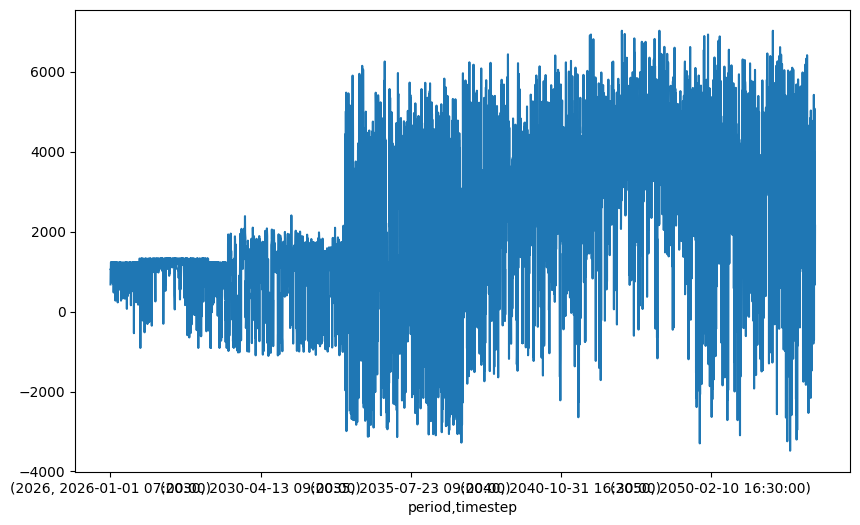

In [117]:
ax = n.links_t.p1['CNSW-NNSW'].plot(figsize=(10,6))
series = n.links_t.p1['CNSW-NNSW']
levels = series.index.get_level_values(0)
unique_levels = pd.Index(levels).unique()
positions = [np.where(levels == lvl)[0][0] for lvl in unique_levels]
ax.set_xticks(positions)
ax.set_xticklabels([str(l) for l in unique_levels], fontsize=10)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Power sent from CNSW (MW)",fontsize=12)
ax.set_title("CNSW-NNSW Transmission flow",fontsize=14,weight='bold')
plt.tight_layout()
plt.grid(axis='y',linestyle="dashed",zorder=5,alpha=0.6)
plt.show()
# plt.savefig("Transmission_Line_Expansion.png",dpi=300)

In [ ]:
n.generators['build_year']

In [ ]:
n.generators_t.p['Large_scale_Solar_PV_CQ_Banana_2050'].plot()
# n.generators_t.p['Large_scale_Solar_PV_NNSW_North_West_NSW_2030'].plot()

In [ ]:
n.generators[n.generators.index.str.contains("Banana")]


In [ ]:
mask = (
    n.generators.index.str.contains("2030") &
    ~n.generators.index.str.contains("augmentation|option|penalty", case=False)
)
filtered_gens_2030 = n.generators[mask]
filtered_gens_2030

<Axes: xlabel='component,carrier'>

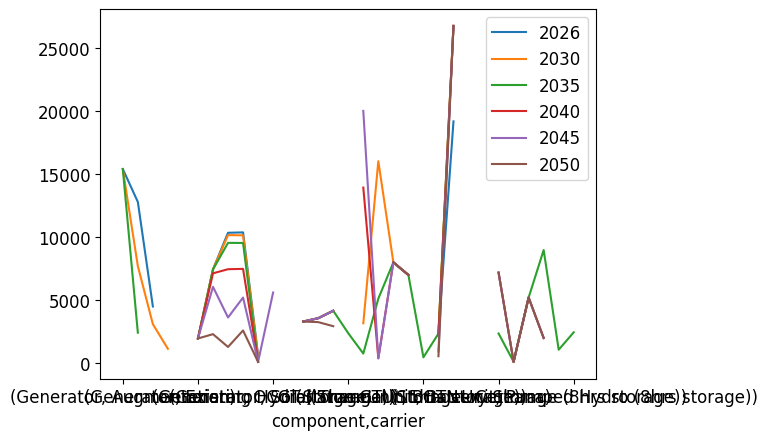

In [351]:
n.statistics.optimal_capacity().plot()


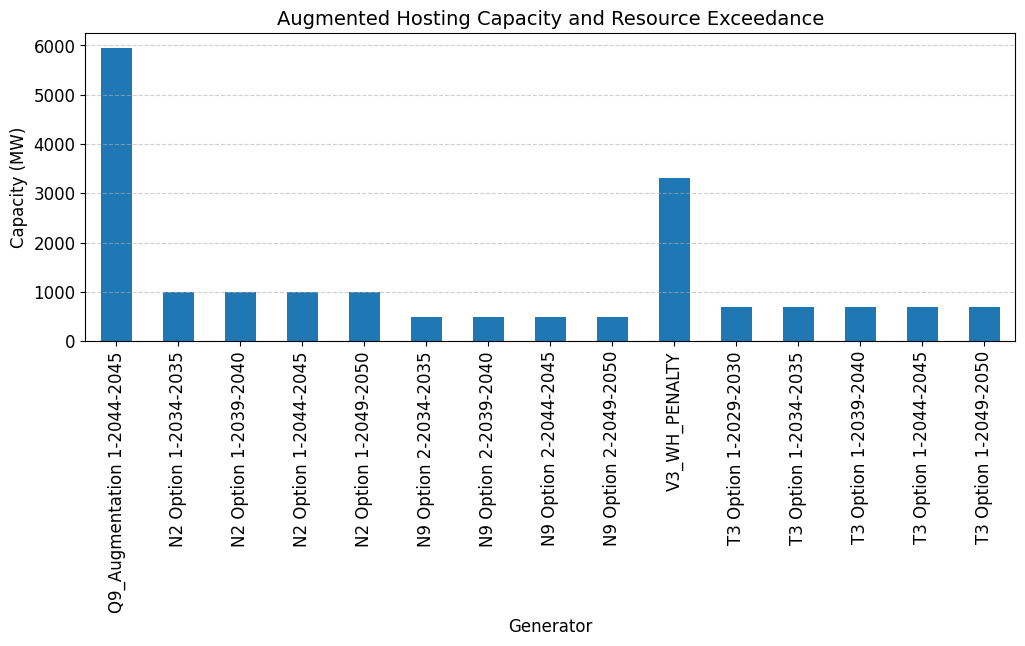

In [527]:
aug_gens = [gen for gen in n.generators.index if (n.generators.at[gen, "carrier"] == "Penalty") or (n.generators.at[gen, "carrier"] == "Augmentation") ]

filtered = n.generators.loc[aug_gens]
filtered = filtered[filtered.p_nom_opt > 0]
if not filtered.empty:
    filtered.p_nom_opt.plot(kind="bar", figsize=(12,4), title="Augmented Hosting Capacity and Resource Exceedance")
    import matplotlib.pyplot as plt
    plt.ylabel("Capacity (MW)")
    plt.grid(axis="y",linestyle="dashed",alpha=0.6)

    # plt.show()
    plt.savefig("../augmentaion_penalty.png",dpi=200)
else:
    print("No penalty generators with p_nom > 0 found.")

In [ ]:
n.loads_t.p['Load_CNSW'][:790].plot(figsize=(20,2))

In [ ]:
cmap

In [ ]:
cmap(i % cmap.N)

In [ ]:
n

In [ ]:
n.add("Generator",
      "Solar Test",
      bus="CNSW",
      # p_nom_extendable=True,
      p_nom=100,
      build_year = 2040,
      overwrite=True)

In [ ]:
n.generators.loc["Solar Test"]["build_year"]

In [ ]:
m = n.optimize.create_model()

In [ ]:
m.constraints["Generator-ext-p-upper"].loc[:,"Test"]

In [ ]:
m.constraints["Generator-fix-p-upper"].loc[:,"Solar Test"]

AssertionError: custom_labels length must match number of bars

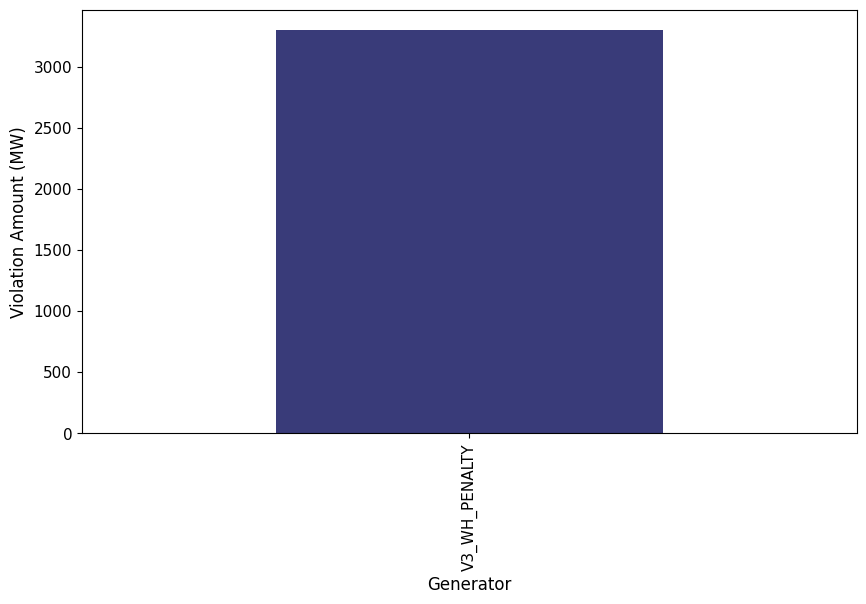

In [346]:
penalty_gens = [gen for gen in n.generators.index if gen.endswith("_PENALTY")]
filtered = n.generators.loc[penalty_gens]
filtered = filtered[filtered.p_nom_opt > 0]
if not filtered.empty:
    filtered.p_nom_opt.plot(kind="bar", figsize=(10,5.5), fontsize=11) #, weight='bold')
    import matplotlib.pyplot as plt
    cmap = plt.get_cmap('tab20b')
    bars = plt.gca().patches
    for i, bar in zip([0,1,2,3,10,11],bars):
        bar.set_facecolor(cmap(i % cmap.N))
    plt.ylabel("Violation Amount (MW)",fontsize=12)
    # plt.show()
    custom_labels = ["Darling Downs Solar", "Hunter-Central Coast Solar", "Ovens Murray Wind", "Western Victoria Wind", "Western Victoria Solar", "Northern SA Solar"]  # replace with your 6 labels
    assert len(custom_labels) == len(filtered), "custom_labels length must match number of bars"
    ax = plt.gca()
    ax.set_xticks(range(len(custom_labels)))
    ax.set_xlabel("Penalty Zone",fontsize=12)
    ax.set_xticklabels(custom_labels, rotation=30) #, ha='right')
    plt.title("REZ Penalty Amounts",fontsize=14,weight='bold')
    plt.tight_layout()
    plt.grid(axis='y',linestyle="dashed",zorder=5,alpha=0.6)
    # plt.savefig("penalty_zone.png",dpi=300)
else:
    print("No penalty generators with p_nom > 0 found.")

In [ ]:
n.storage_units_t.p_max_pu

In [ ]:
import matplotlib.pyplot as plt

# Group generators by year suffix
year_suffixes = ("_2026", "_2030", "_2035", "_2040", "_2045", "_2050")
filtered_gens_by_year = {}

for suffix in year_suffixes:
    mask = filtered_gens.index.str.endswith(suffix)
    gens = filtered_gens[mask]
    if not gens.empty:
        filtered_gens_by_year[suffix] = gens.p_nom_opt.sum()

# Convert to Series for plotting
grouped = pd.Series(filtered_gens_by_year)
grouped.plot(kind="bar", figsize=(10,4), title="Total p_nom_opt by Generator Year Suffix")
plt.ylabel("Total p_nom_opt [MW]")
plt.xlabel("Year Suffix")
plt.show()

In [ ]:
n.storage_units.carrier

In [ ]:
p8+p24

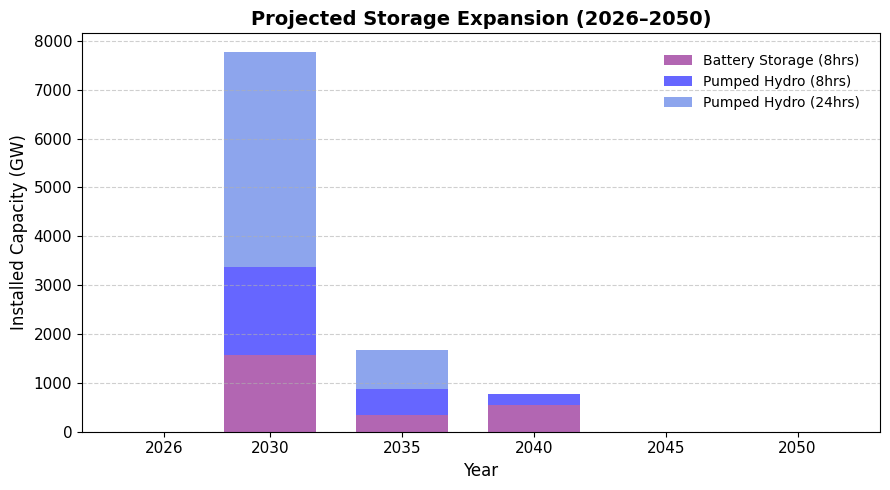

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Define years and capacity data (matching lengths)
years = [2026,2030,2035,2040,2045,2050]
b8 = [0, 1563, 334, 552,0,0]   # Example data
p8 = [0, 1802, 533, 224, 0, 0]  # Example data
p24 = [0, 4400.87282483085, 800, 0, 0, 0]  # Example data


# Compute stacking bottoms
bottom_p8 = np.array(b8)
bottom_p24 = np.array(b8) + np.array(p8)

# Create bar chart
bar_width = 3.5
fig, ax = plt.subplots(figsize=(9, 5))

# Plot stacked bars
ax.bar(years, b8, color="purple", label="Battery Storage (8hrs)", width=bar_width,alpha=0.6)
ax.bar(years, p8, bottom=b8, color="blue", label="Pumped Hydro (8hrs)", width=bar_width,alpha=0.6)
ax.bar(years, p24, bottom=bottom_p24, color="royalblue", label="Pumped Hydro (24hrs)", width=bar_width,alpha=0.6)


# Labels and style
ax.set_title("Projected Storage Expansion (2026–2050)", fontsize=14, weight='bold')
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Installed Capacity (GW)", fontsize=12)
ax.set_xticks(years)
ax.tick_params(axis='both', labelsize=11)
ax.legend(frameon=False,bbox_to_anchor=(0.99,0.98))

# Aesthetic improvements
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# plt.show()
# plt.savefig("projected_storage.png",dpi=300)

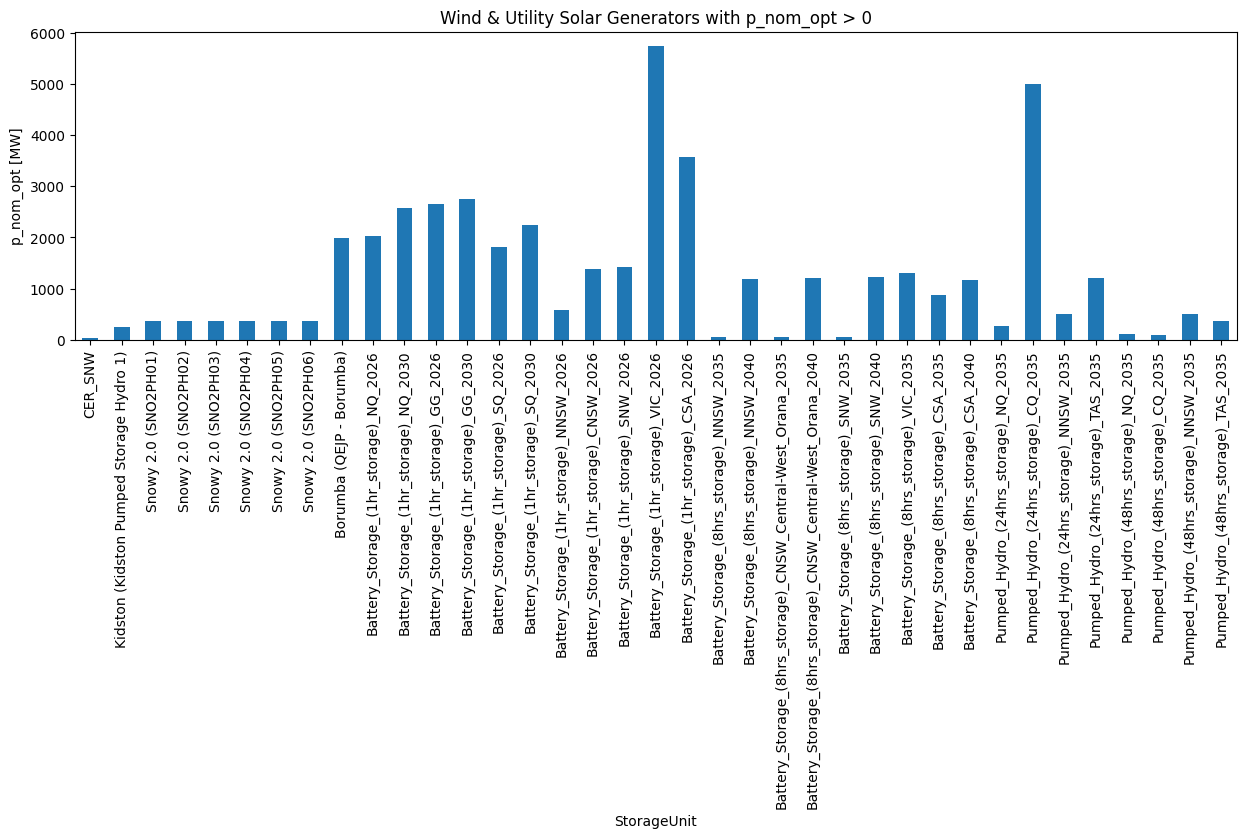

In [114]:
# Filter generators with carrier "Wind" or "Utility Solar"
wind_solar_gens = n.storage_units[(n.storage_units.carrier.str.startswith("Pumped Hydro (")) | (n.storage_units.carrier.str.startswith("Battery Storage (")) | (n.storage_units.index.str.startswith("CER")) ]

# Only those with p_nom_opt > 0
filtered_gens = wind_solar_gens[wind_solar_gens.p_nom_opt > 30]

# Plot
if not filtered_gens.empty:
    filtered_gens.p_nom_opt.plot(kind="bar", figsize=(15,4), title="Wind & Utility Solar Generators with p_nom_opt > 0")
    import matplotlib.pyplot as plt
    plt.ylabel("p_nom_opt [MW]")
    plt.show()
else:
    print("No Wind or Utility Solar generators with p_nom_opt > 0 found.")

In [ ]:
n.storage_units.loc["Pumped_Hydro_(24hrs_storage)_TAS_2040"]['build_year']

In [ ]:
n.storage_units_t.p["Pumped_Hydro_(24hrs_storage)_TAS_2040"].plot()

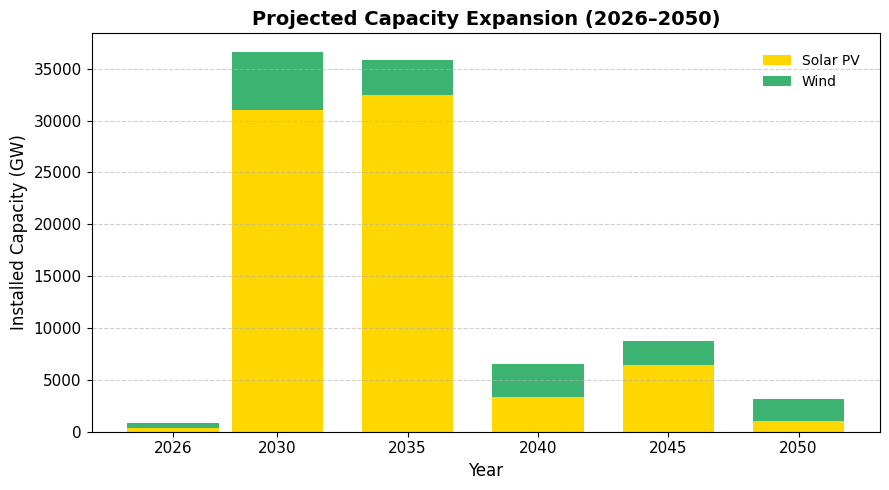

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define years and capacity data (matching lengths)
years = [2026,2030,2035,2040,2045,2050]
wind = [434, 5563, 3377, 3236, 2310, 2095]   # Example data
solar = [377, 31013.87282483085, 32461, 3331, 6399, 1021]  # Example data

# Create bar chart
bar_width = 3.5
fig, ax = plt.subplots(figsize=(9, 5))

# Plot stacked bars
ax.bar(years, solar, color="#FFD700", label="Solar PV", width=bar_width)
ax.bar(years, wind, bottom=solar, color="#3CB371", label="Wind", width=bar_width)

# Labels and style
ax.set_title("Projected Capacity Expansion (2026–2050)", fontsize=14, weight='bold')
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Installed Capacity (GW)", fontsize=12)
ax.set_xticks(years)
ax.tick_params(axis='both', labelsize=11)
ax.legend(frameon=False,bbox_to_anchor=(0.99,0.98))

# Aesthetic improvements
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# plt.show()
plt.savefig("projected_solar_wind.png",dpi=300)

In [ ]:
n.generators[n.generators.carrier=="Black Coal"].index

<Axes: xlabel='period,timestep'>

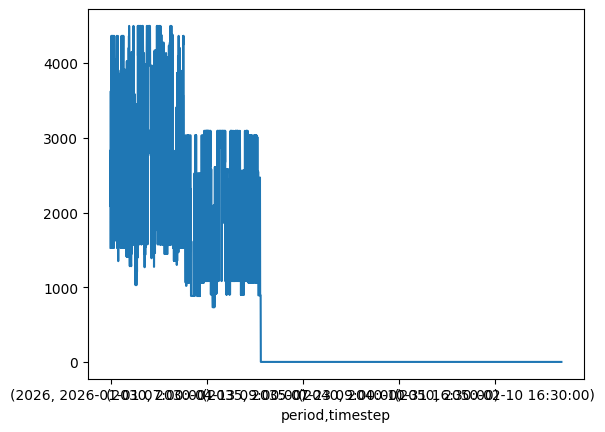

In [110]:
n.generators_t.p[n.generators[n.generators.carrier=="Brown Coal"].index].sum(axis=1).plot()


<Axes: xlabel='period,timestep'>

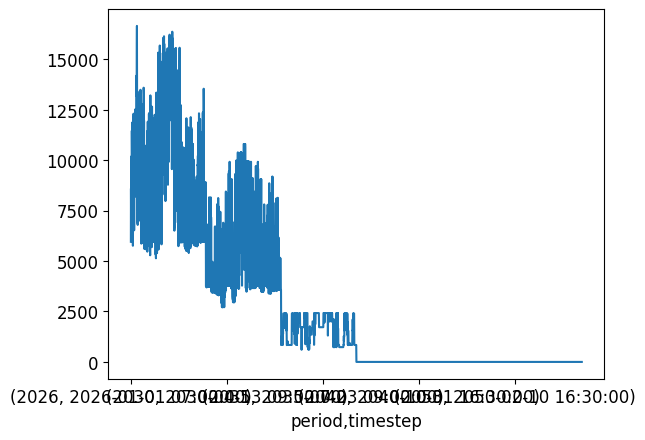

In [278]:
n.generators_t.p[n.generators[n.generators.carrier.isin(["Black Coal","Brown Coal"])].index].sum(axis=1).plot()

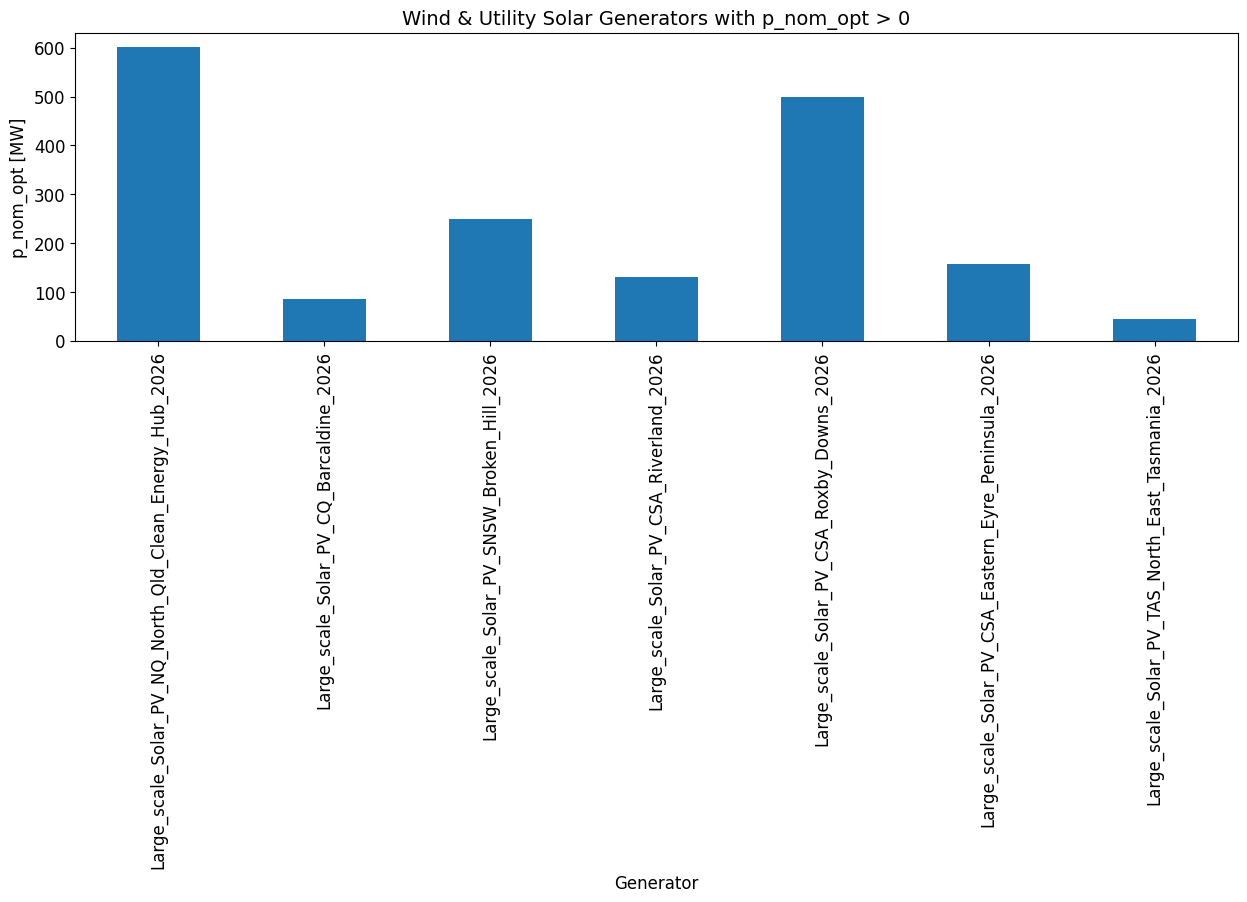

In [296]:
# Filter generators with carrier "Wind" or "Utility Solar"
wind_solar_gens = n.generators[(n.generators.carrier == "Utility Solar") | (n.generators.carrier == "Wind") ]

# Only those with p_nom_opt > 0
filtered_gens2 = wind_solar_gens[wind_solar_gens.p_nom_opt > 0]

filtered_gens = filtered_gens2[filtered_gens2.index.str.contains("2026")]

# Plot
if not filtered_gens.empty:
    filtered_gens.p_nom_opt.plot(kind="bar", figsize=(15,4), title="Wind & Utility Solar Generators with p_nom_opt > 0")
    import matplotlib.pyplot as plt
    plt.ylabel("p_nom_opt [MW]")
    plt.show()
else:
    print("No Wind or Utility Solar generators with p_nom_opt > 0 found.")

In [45]:
filtered_gens.sum()

bus                        NQNQNQNQNQCQCQCQCQCQCQCQCQSQCQNNSWNNSWNNSWNNSW...
control                    PQPQPQPQPQPQPQPQPQPQPQPQPQPQPQPQPQPQPQPQPQPQPQ...
type                                                                        
p_nom                                                                    0.0
p_nom_mod                                                                0.0
p_nom_extendable                                                          68
p_nom_min                                                                0.0
p_nom_max                                                                inf
p_min_pu                                                                 0.0
p_max_pu                                                                68.0
p_set                                                                    0.0
e_sum_min                                                               -inf
e_sum_max                                                                inf

In [586]:
# Filter generators with carrier "Wind" or "Utility Solar"
wind_solar_gens = n.generators[(n.generators.carrier == "Utility Solar")] # | (n.generators.carrier == "Wind") ] #

thing = []
for year in n.investment_periods:
    print(year)

    # Only those with p_nom_opt > 0
    filtered_gens2 = wind_solar_gens[wind_solar_gens.p_nom_opt > 1]

    filtered_gens = filtered_gens2[filtered_gens2.index.str.contains(str(year))]

    thing.append(filtered_gens.p_nom_opt.sum())

list(thing)


2026
2030
2035
2040
2045
2050


[np.float64(1767.80598492028),
 np.float64(3168.7843143013774),
 np.float64(764.9999015484755),
 np.float64(13930.694661299241),
 np.float64(20013.02397416519),
 np.float64(0.0)]

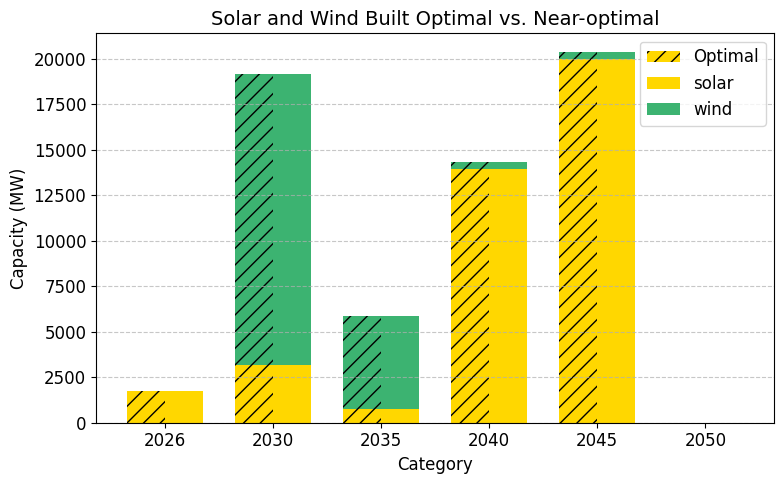

In [587]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the Data
categories = [str(y) for y in n.investment_periods]

# Instead of single values, split into solar and wind components
# Example values
set_a_solar = [np.float64(1767.807601501485),
 np.float64(3168.783197041867),
 np.float64(765.0),
 np.float64(13930.69941941297),
 np.float64(20013.02350763346),
 np.float64(0.0)]

set_a_wind  =  [np.float64(0.0),
 np.float64(16022.229765481878),
 np.float64(5124.516578083934),
 np.float64(401.51679189913335),
 np.float64(378.4832081008666),
 np.float64(0.0)]

# set_b_solar = [1024,5016,10687,4898,16711,10386]
# set_b_wind  = [1302,25006,17144,4462,2591,5071]

# set_b_solar = [1024,5016,10687,4898,16711,10386]
# set_b_wind  = [1302,25006,17144,4462,2591,5071]

set_b_solar = [np.float64(1767.80598492028),
 np.float64(3168.7843143013774),
 np.float64(764.9999015484755),
 np.float64(13930.694661299241),
 np.float64(20013.02397416519),
 np.float64(0.0)]

set_b_wind  = [np.float64(0.0),
 np.float64(16022.2279990152),
 np.float64(5124.516058971994),
 np.float64(401.5168095882906),
 np.float64(378.483069402647),
 np.float64(0.0)]


x = np.arange(len(categories))  # the label locations
width = 0.35  # width of the bars

# 2. Create Figure and Axes
fig, ax = plt.subplots(figsize=(8, 5))

# 3. Plot stacked bars
# Set A (left)

rects1_solar = ax.bar(x - width/2, set_a_solar, width, label="Optimal", color="#FFD700", hatch = "//")
rects1_wind  = ax.bar(x - width/2, set_a_wind, width, bottom=set_a_solar, color="#3CB371", hatch = "//")

# Set B (right)
rects2_solar = ax.bar(x + width/2, set_b_solar, width, label='solar', color="#FFD700")
rects2_wind  = ax.bar(x + width/2, set_b_wind, width, bottom=set_b_solar,label='wind', color="#3CB371")

# 4. Customize
ax.set_title('Solar and Wind Built Optimal vs. Near-optimal')
ax.set_ylabel('Capacity (MW)')
ax.set_xlabel('Category')
ax.set_xticks(x, categories)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
# plt.show()
plt.savefig("../vre_built_sc_relaxed.png",dpi=200)


In [323]:
n.storage_units.carrier.unique()

array(['CER', 'Existing Hydro', 'Pumped Hydro (8hrs storage)',
       'Pumped Hydro (24hrs storage)', 'Battery Storage',
       'Battery Storage (1hr storage)', 'Battery Storage (2hrs storage)',
       'Battery Storage (4hrs storage)', 'Battery Storage (8hrs storage)',
       'Pumped Hydro (48hrs storage)', 'BOTN - Cethana'], dtype=object)

In [589]:
# Filter generators with carrier "Wind" or "Utility Solar"
wind_solar_gens = n.storage_units[(n.storage_units.carrier.str.contains("Pumped Hydro"))] #"Utility Solar")] # | (n.generators.carrier == 

thing = []
for year in n.investment_periods:
    print(year)

    # Only those with p_nom_opt > 0
    filtered_gens2 = wind_solar_gens[wind_solar_gens.p_nom_opt > 1]

    filtered_gens = filtered_gens2[filtered_gens2.index.str.contains(str(year))]

    thing.append(filtered_gens.p_nom_opt.sum())

list(thing)


2026
2030
2035
2040
2045
2050


[np.float64(0.0),
 np.float64(0.0),
 np.float64(8048.999330155439),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0)]

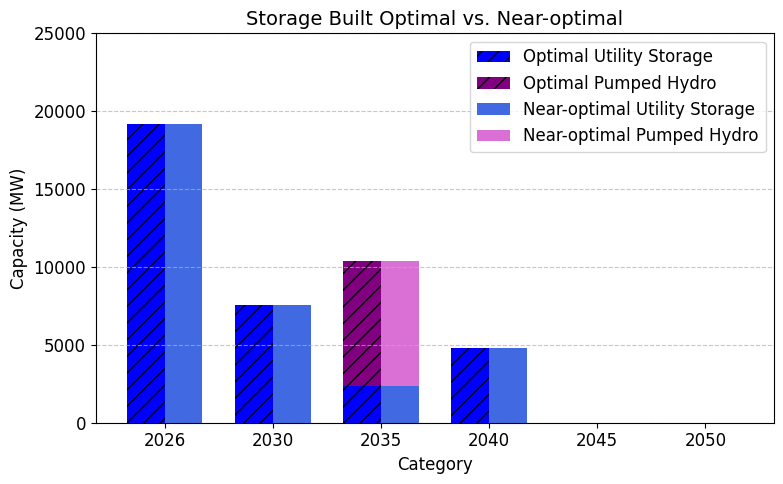

In [590]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the Data
categories = [str(y) for y in n.investment_periods]

# Instead of single values, split into solar and wind components
# Example values
set_a_solar = [np.float64(19181.297816732207),
 np.float64(7571.086000990797),
 np.float64(2358.9718114721645),
 np.float64(4828.039142253083),
 np.float64(0.0),
 np.float64(0.0)]
set_a_wind  = [np.float64(0.0),
 np.float64(0.0),
 np.float64(8049.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0)]

# set_a_solar = [np.float64(14247.322559541351),
#  np.float64(5869.622224682944),
#  np.float64(0.0),
#  np.float64(0.0),
#  np.float64(682.0843042638719),
#  np.float64(12647.119049348268)]
# set_a_wind  = [np.float64(0.0),
#  np.float64(0.0),
#  np.float64(2070.9999999991232),
#  np.float64(0.0),
#  np.float64(0.0),
#  np.float64(0.0)]

# set_b_solar = [4526,9889,3621,166,0,0]
set_b_solar =[np.float64(19181.29551772617),
 np.float64(7571.065556052136),
 np.float64(2358.9703345357675),
 np.float64(4828.036825138231),
 np.float64(0.0),
 np.float64(0.0)]

set_b_wind  = [np.float64(0.0),
 np.float64(0.0),
 np.float64(8048.999330155439),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0)]

x = np.arange(len(categories))  # the label locations
width = 0.35  # width of the bars

# 2. Create Figure and Axes
fig, ax = plt.subplots(figsize=(8, 5))

# 3. Plot stacked bars
# Set A (left)

rects1_solar = ax.bar(x - width/2, set_a_solar, width, label='Optimal Utility Storage', color="blue", hatch = "//")
rects1_wind  = ax.bar(x - width/2, set_a_wind, width, bottom=set_a_solar,label='Optimal Pumped Hydro', color="purple", hatch = "//")

# Set B (left)
rects2_solar = ax.bar(x + width/2, set_b_solar, width, label='Near-optimal Utility Storage', color="royalblue")
rects2_wind  = ax.bar(x + width/2, set_b_wind, width, bottom=set_b_solar,label='Near-optimal Pumped Hydro', color="orchid")

# 4. Customize
ax.set_title('Storage Built Optimal vs. Near-optimal')
ax.set_ylabel('Capacity (MW)')
ax.set_xlabel('Category')
ax.set_xticks(x, categories)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim([0,25000])

plt.tight_layout()
# plt.show()
plt.savefig("../storage_built_sc_relaxed.png",dpi=200)

In [536]:
# Filter generators with carrier "Wind" or "Utility Solar"
# wind_solar_gens = n.generators[(n.generators.carrier == "Gas")]
wind_solar_gens = n.generators[(n.generators.carrier == "CCGT")]


# Only those with p_nom_opt > 0
filtered_gens = wind_solar_gens[wind_solar_gens.p_nom_opt > 1]

# Plot
if not filtered_gens.empty:
    filtered_gens.p_nom_opt.plot(kind="bar", figsize=(15,4), title="Wind & Utility Solar Generators with p_nom_opt > 0")
    import matplotlib.pyplot as plt
    plt.ylabel("p_nom_opt [MW]")
    plt.show()
else:
    print("No Wind or Utility Solar generators with p_nom_opt > 0 found.")

No Wind or Utility Solar generators with p_nom_opt > 0 found.


In [580]:
# Filter generators with carrier "Wind" or "Utility Solar"
wind_solar_gens = n.generators[(n.generators.carrier.str.contains("CCGT"))] #"Utility Solar")] # | (n.generators.carrier == 

thing = []
for year in n.investment_periods:
    print(year)

    # Only those with p_nom_opt > 0
    filtered_gens2 = wind_solar_gens[wind_solar_gens.p_nom_opt > 1]

    filtered_gens = filtered_gens2[filtered_gens2.index.str.contains(str(year))]

    thing.append(filtered_gens.p_nom_opt.sum())

list(thing)


2026
2030
2035
2040
2045
2050


[np.float64(0.0),
 np.float64(4670.253113674215),
 np.float64(4305.379817721896),
 np.float64(4864.107491240887),
 np.float64(0.0),
 np.float64(0.0)]

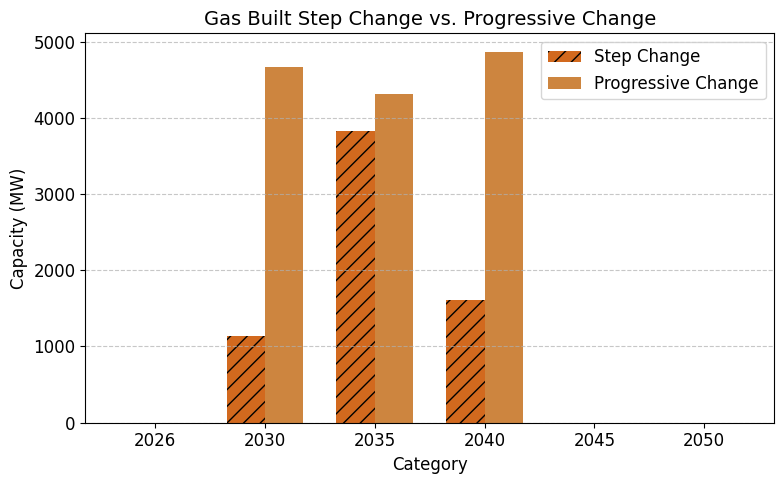

In [582]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the Data
categories = [str(y) for y in n.investment_periods]

# Instead of single values, split into solar and wind components
# Example values
set_a_solar = [np.float64(0.0),
 np.float64(1143.6839959053052),
 np.float64(3825.380111926563),
 np.float64(1606.2080312068456),
 np.float64(0.0),
 np.float64(0.0)]

# set_a_solar = [np.float64(0.0),
#  np.float64(1143.6839959053052),
#  np.float64(3825.380111926563),
#  np.float64(1606.2080312068456),
#  np.float64(0.0),
#  np.float64(0.0)]
# set_a_wind  = [np.float64(0.0),
#  np.float64(0.0),
#  np.float64(8049.0),
#  np.float64(0.0),
#  np.float64(0.0),
#  np.float64(0.0)]

# set_b_solar = [200,64,1892,3943,2262,0]

set_b_solar = [np.float64(0.0),
 np.float64(4670.253113674215),
 np.float64(4305.379817721896),
 np.float64(4864.107491240887),
 np.float64(0.0),
 np.float64(0.0)]
# set_b_wind  = [np.float64(0.0),
#  np.float64(0.0),
#  np.float64(0.0),
#  np.float64(0.0),
#  np.float64(0.0),
#  np.float64(0.0)]

x = np.arange(len(categories))  # the label locations
width = 0.35  # width of the bars

# 2. Create Figure and Axes
fig, ax = plt.subplots(figsize=(8, 5))

# 3. Plot stacked bars
# Set A (left)

# rects1_solar = ax.bar(x - width*1.5, set_a_solar, width, label="AUS-CEM", color="chocolate", hatch = "//")
# rects1_wind  = ax.bar(x - width/2, set_a_wind, width, bottom=set_a_solar,label='Pumped Hydro', color="purple", hatch = "//")

rects1_wind = ax.bar(x - width/2, set_a_solar, width, label='Step Change', color="chocolate", hatch="//")


# Set B (right)
# rects2_wind  = ax.bar(x + width/2, set_b_solar, width, bottom=set_b_solar, color="purple")
rects2_solar = ax.bar(x + width/2, set_b_solar, width, label='Progressive Change', color="peru")


# rects2_solar = ax.bar(x + width*1.5, set_b_solar, width, label='ISP', color="peru")

# rects2_solar = ax.bar(x + width, set_b_solar, width/2, label='ISP', color="peru")


# 4. Customize
ax.set_title('Gas Built Step Change vs. Progressive Change')
ax.set_ylabel('Capacity (MW)')
ax.set_xlabel('Category')
ax.set_xticks(x, categories)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
# ax.set_ylim([0,20000])

plt.tight_layout()
# plt.show()
plt.savefig("../gas_built_sc_pc.png",dpi=200)


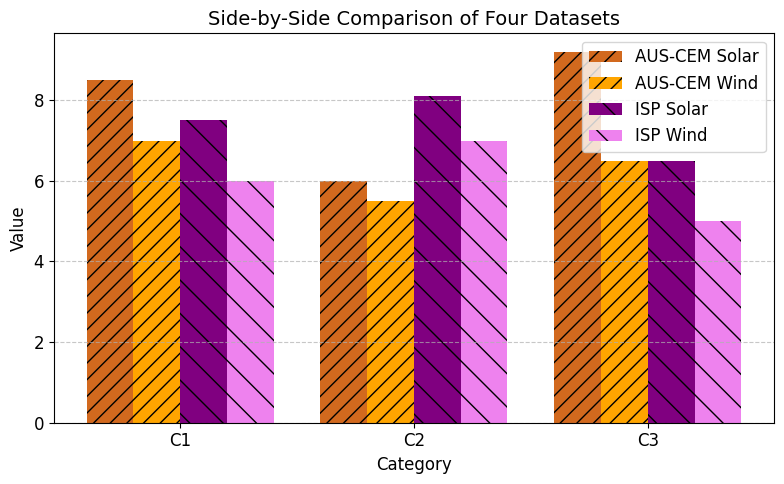

In [512]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
categories = ['C1', 'C2', 'C3']
set_a_solar = [8.5, 6.0, 9.2]
set_a_wind  = [7.0, 5.5, 6.5]
set_b_solar = [7.5, 8.1, 6.5]
set_b_wind  = [6.0, 7.0, 5.0]

x = np.arange(len(categories))  # category positions
width = 0.2  # width of each bar

fig, ax = plt.subplots(figsize=(8,5))

# Four bars per category
rects1_solar = ax.bar(x - 1.5*width, set_a_solar, width, label='AUS-CEM Solar', color='chocolate', hatch='//')
rects1_wind  = ax.bar(x - 0.5*width, set_a_wind,  width, label='AUS-CEM Wind',  color='orange',    hatch='//')
rects2_solar = ax.bar(x + 0.5*width, set_b_solar, width, label='ISP Solar',     color='purple',   hatch='\\')
rects2_wind  = ax.bar(x + 1.5*width, set_b_wind,  width, label='ISP Wind',      color='violet',   hatch='\\')

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Value')
ax.set_xlabel('Category')
ax.set_title('Side-by-Side Comparison of Four Datasets')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


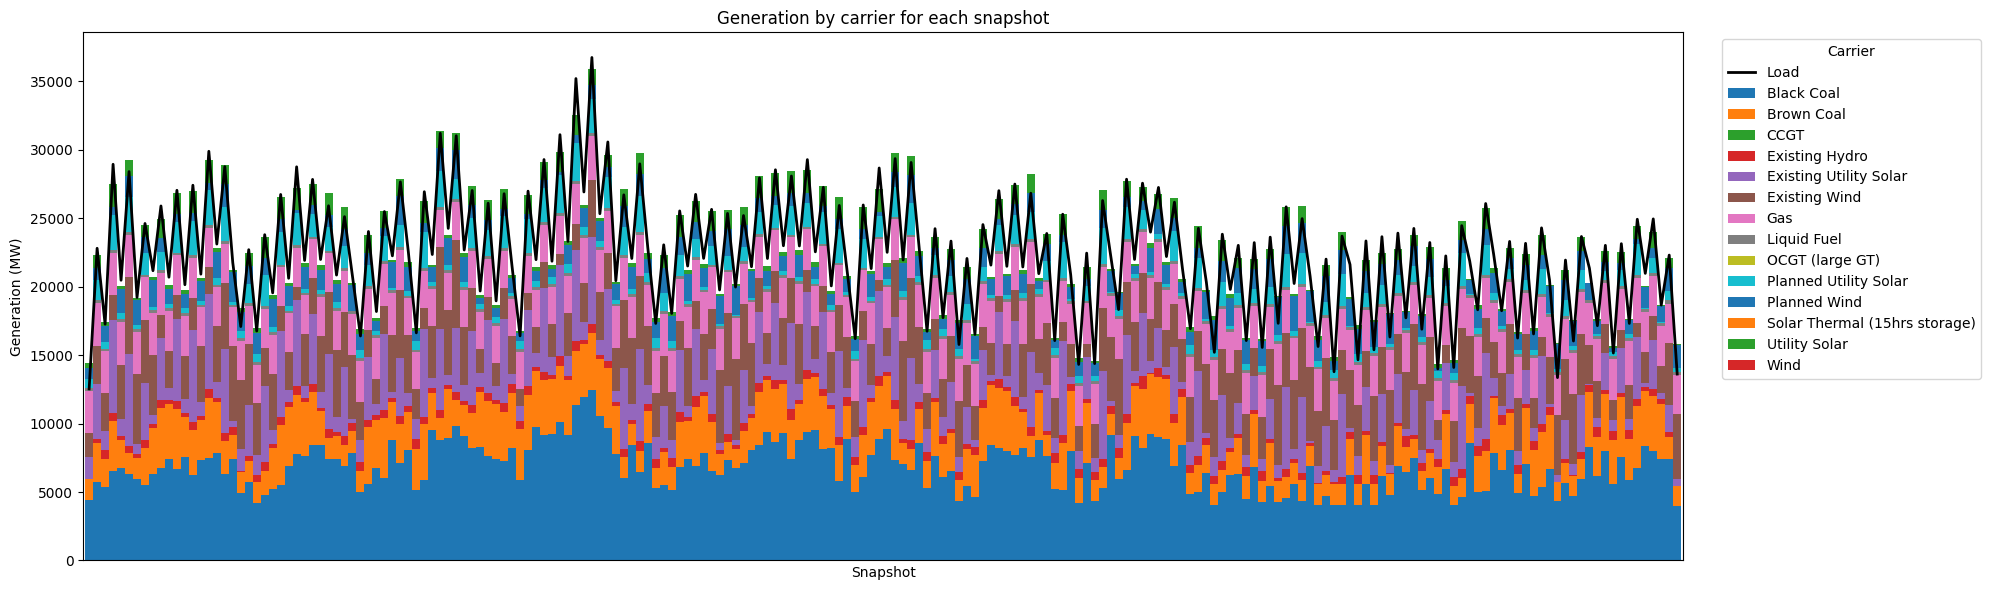

In [119]:
import pandas as pd
import matplotlib.pyplot as plt

# --- inputs you already have ---
# gen_carrier: Series mapping generator_name -> carrier (index must match gen_p.columns)
# gen_p: DataFrame, index is MultiIndex (period, snapshot), columns are generator names

gen_carrier = n.generators.carrier
gen_p = n.generators_t.p

# ensure gen_carrier lines up with gen_p columns
gen_carrier = gen_carrier.reindex(gen_p.columns)   # safe ordering; will insert NaN for mismatches
if gen_carrier.isna().any():
    raise ValueError("Some generators in gen_p.columns are not in gen_carrier index")

# 1) sum generators by carrier for each row (each row = a (period,snapshot) tuple)
gen_by_carrier =  gen_p.T.groupby(gen_carrier).sum().T.reset_index(level=1).set_index('timestep')  # columns -> carriers
gen_by_carrier = gen_by_carrier.loc[:, (gen_by_carrier != 0).any(axis=0)]
# 2) replace the MultiIndex rows with the snapshot level (level 1)
#    (you already created gen_snapshot earlier)
snapshots = gen_p.index.get_level_values(1)   # or: gen_snapshot
# convert to datetimes if appropriate (helps plotting)
snapshots = pd.to_datetime(snapshots)

# set the snapshot timestamps as the index
gen_by_carrier = gen_by_carrier.copy()
gen_by_carrier.index = snapshots

# 3) If the same timestamp appears multiple times (e.g. different 'period' levels), aggregate them
gen_by_carrier = gen_by_carrier.groupby(level=0).sum()

# 4) (Optional) restrict to a subset of snapshots for plotting readability
#    e.g. first 24 timesteps, or pick specific timestamps
plot_df = gen_by_carrier.iloc[:200]   # example: first 24 snapshots
# OR for specific timestamps:
# plot_df = gen_by_carrier.loc[['2025-01-01 00:00','2025-01-01 01:00']]

# 5) Plot stacked bar (snapshots on x-axis)
fig, ax = plt.subplots(figsize=(20,6))
plot_df.plot(kind='bar', stacked=True, ax=ax, width=1)
n.loads_t.p[:200].sum(axis=1).plot(ax=ax,label="Load",linewidth=2,color="black")

ax.set_xlabel("")                      # remove x-axis label
ax.set_xticklabels([])                 # remove tick labels
ax.set_xticks([])                      # remove ticks entirely
ax.set_xlabel("Snapshot")
ax.set_ylabel("Generation (MW)")
ax.set_title("Generation by carrier for each snapshot")
ax.legend(title="Carrier", bbox_to_anchor=(1.02, 1), loc="upper left")  # legend outside plot
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [380]:
n.storage_units.p_nom['CER_NNSW']

np.float64(2.472002098430754)

In [381]:
m = n.optimize.create_model()

In [385]:
m.constraints["StorageUnit-fix-p_dispatch-upper"].loc[:,"CER_NNSW"]

Constraint `StorageUnit-fix-p_dispatch-upper` [snapshot (period, timestep): 4695]:
----------------------------------------------------------------------------------
[(2026, 2026-01-01 07:00:00)]: +1 StorageUnit-p_dispatch[(2026, 2026-01-01 07:00:00), CER_NNSW] ≤ 310.8
[(2026, 2026-01-01 16:00:00)]: +1 StorageUnit-p_dispatch[(2026, 2026-01-01 16:00:00), CER_NNSW] ≤ 310.8
[(2026, 2026-01-02 07:30:00)]: +1 StorageUnit-p_dispatch[(2026, 2026-01-02 07:30:00), CER_NNSW] ≤ 310.8
[(2026, 2026-01-02 15:30:00)]: +1 StorageUnit-p_dispatch[(2026, 2026-01-02 15:30:00), CER_NNSW] ≤ 310.8
[(2026, 2026-01-03 00:00:00)]: +1 StorageUnit-p_dispatch[(2026, 2026-01-03 00:00:00), CER_NNSW] ≤ 310.8
[(2026, 2026-01-03 16:00:00)]: +1 StorageUnit-p_dispatch[(2026, 2026-01-03 16:00:00), CER_NNSW] ≤ 310.8
[(2026, 2026-01-04 00:00:00)]: +1 StorageUnit-p_dispatch[(2026, 2026-01-04 00:00:00), CER_NNSW] ≤ 310.8
		...
[(2050, 2050-12-28 16:30:00)]: +1 StorageUnit-p_dispatch[(2050, 2050-12-28 16:30:00), CER_NNSW] ≤ 97

In [379]:
n.storage_units_t.p_max_pu['CER_NNSW']

period  timestep           
2026    2026-01-01 07:00:00     125.728049
        2026-01-01 16:00:00     125.728049
        2026-01-02 07:30:00     125.728049
        2026-01-02 15:30:00     125.728049
        2026-01-03 00:00:00     125.728049
                                  ...     
2050    2050-12-29 16:30:00    3963.750681
        2050-12-30 07:00:00    3963.750681
        2050-12-30 17:00:00    3963.750681
        2050-12-31 06:30:00    3963.750681
        2050-12-31 17:00:00    3963.750681
Name: CER_NNSW, Length: 4695, dtype: float64

<Axes: xlabel='period,timestep'>

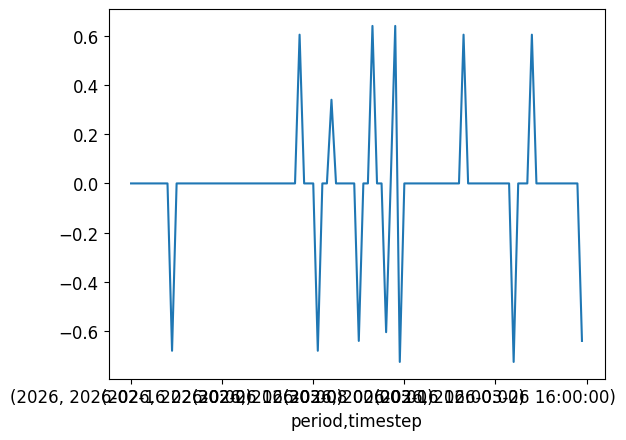

In [ ]:
n.storage_units_t.p['CER_NNSW']


<Axes: xlabel='period,timestep'>

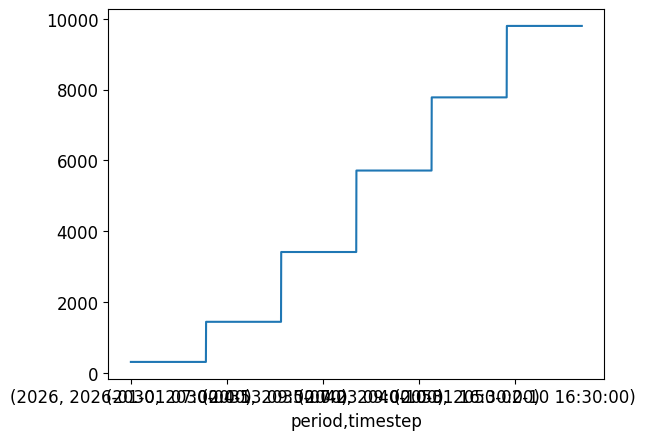

In [386]:
(n.storage_units_t.p_max_pu['CER_NNSW']*n.storage_units.p_nom['CER_NNSW']).plot()

<Axes: xlabel='component,carrier'>

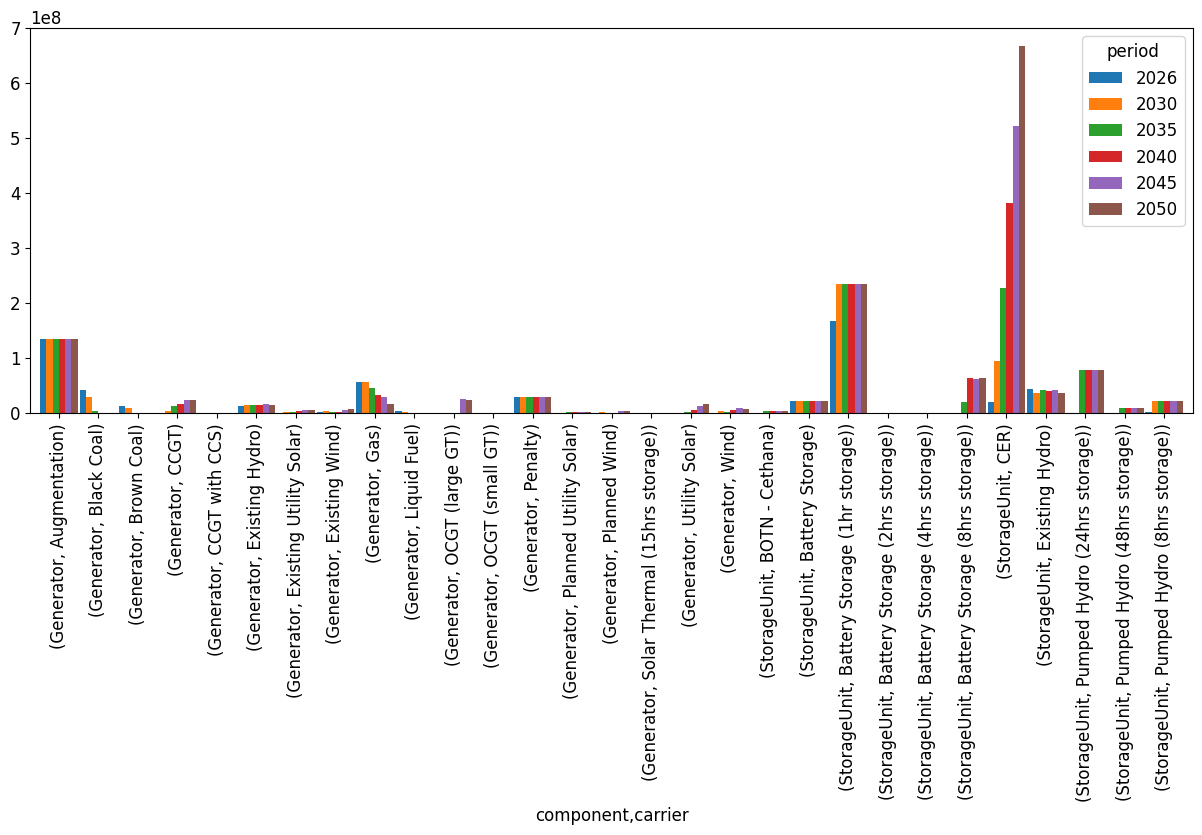

In [367]:
n.statistics.curtailment().plot(kind="bar",figsize=(15,5),rot=90,width=0.95)

In [ ]:
plot_df

In [ ]:
n.optimize(solver_name="highs",solver_options={"solver":"ipm"})

In [ ]:
n.generators_t.p.sum(axis=1).plot()

In [583]:
import pypsa
# n = pypsa.Network("../networks/isp24_month_2026_2050_SSLT_solved_SC_highs_final_v1.nc")  # Grab 2025-2030 network
# n = pypsa.Network("../networks/isp24_month_2026_2050_SSLT_solved_SC_gurobi_final_v2.nc")  # Grab 2025-2030 network
n = pypsa.Network("../networks/isp24_year_2026_2050_SSLT_solved_SC_gurobi_final_v2.nc")  # Grab 2025-2030 network
# n = pypsa.Network("../networks/isp24_year_2026_2050_SSLT_solved_SC_gurobi_final_crossover_v3.nc")  # Grab 2025-2030 network
# n = pypsa.Network("../networks/isp24_year_2026_2050_SSLT_solved_PC_gurobi_final_crossover_v3.nc")  # Grab 2025-2030 network
# n = pypsa.Network("../networks/isp24_year_2026_2050_SSLT_solved_PC_gurobi_final_v2.nc")  # Grab 2025-2030 network


INFO:pypsa.network.io:New version 1.0.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'isp24_SSLT_SC_y_g_V2' has buses, carriers, generators, global_constraints, links, loads, storage_units


In [259]:
n.generators[n.generators.index.str.startswith("Darling Downs")]

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt,lifeTime
Generator,,,,,,,,,,,,,,,,,,,,,
Darling Downs (DDPS1_ST),SQ,PQ,,268.2225,0.0,False,0.0,inf,0.0,1.0,...,0,1,0,NaN,NaN,1.0,1.0,1.0,268.2225,NaN
Darling Downs (DDPS1_GT1),SQ,PQ,,116.9175,0.0,False,0.0,inf,0.0,1.0,...,0,1,0,NaN,NaN,1.0,1.0,1.0,116.9175,NaN
Darling Downs (DDPS1_GT2),SQ,PQ,,116.9175,0.0,False,0.0,inf,0.0,1.0,...,0,1,0,NaN,NaN,1.0,1.0,1.0,116.9175,NaN
Darling Downs (DDPS1_GT3),SQ,PQ,,116.9175,0.0,False,0.0,inf,0.0,1.0,...,0,1,0,NaN,NaN,1.0,1.0,1.0,116.9175,NaN
Darling Downs Solar Farm (DDSF1),SQ,PQ,,109.9780,0.0,False,0.0,inf,0.0,1.0,...,0,1,0,NaN,NaN,1.0,1.0,1.0,109.9780,NaN


In [391]:
n.storage_units

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,state_of_charge_initial_per_period,state_of_charge_set,cyclic_state_of_charge,cyclic_state_of_charge_per_period,max_hours,efficiency_store,efficiency_dispatch,standing_loss,inflow,p_nom_opt
StorageUnit,,,,,,,,,,,,,,,,,,,,,
CER_CNSW,CNSW,PQ,,7.278824,0.0,False,0.0,inf,-1.0,1.0,...,False,NaN,True,True,2.2,1.0,1.0,0.0,0.0,7.278824
CER_NNSW,NNSW,PQ,,2.472002,0.0,False,0.0,inf,-1.0,1.0,...,False,NaN,True,True,2.2,1.0,1.0,0.0,0.0,2.472002
CER_SNSW,SNSW,PQ,,4.755184,0.0,False,0.0,inf,-1.0,1.0,...,False,NaN,True,True,2.2,1.0,1.0,0.0,0.0,4.755184
CER_SNW,SNW,PQ,,39.916431,0.0,False,0.0,inf,-1.0,1.0,...,False,NaN,True,True,2.2,1.0,1.0,0.0,0.0,39.916431
CER_NQ,NQ,PQ,,2.599072,0.0,False,0.0,inf,-1.0,1.0,...,False,NaN,True,True,2.2,1.0,1.0,0.0,0.0,2.599072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Pumped_Hydro_(48hrs_storage)_TAS_2050,TAS,PQ,,0.000000,0.0,True,0.0,inf,-1.0,1.0,...,False,NaN,True,True,48.0,1.0,1.0,0.0,0.0,0.000000
BOTN_-_Cethana_TAS_2035,TAS,PQ,,0.000000,0.0,True,0.0,inf,-1.0,1.0,...,False,NaN,True,True,20.0,1.0,1.0,0.0,0.0,468.486723
BOTN_-_Cethana_TAS_2040,TAS,PQ,,0.000000,0.0,True,0.0,inf,-1.0,1.0,...,False,NaN,True,True,20.0,1.0,1.0,0.0,0.0,0.000000


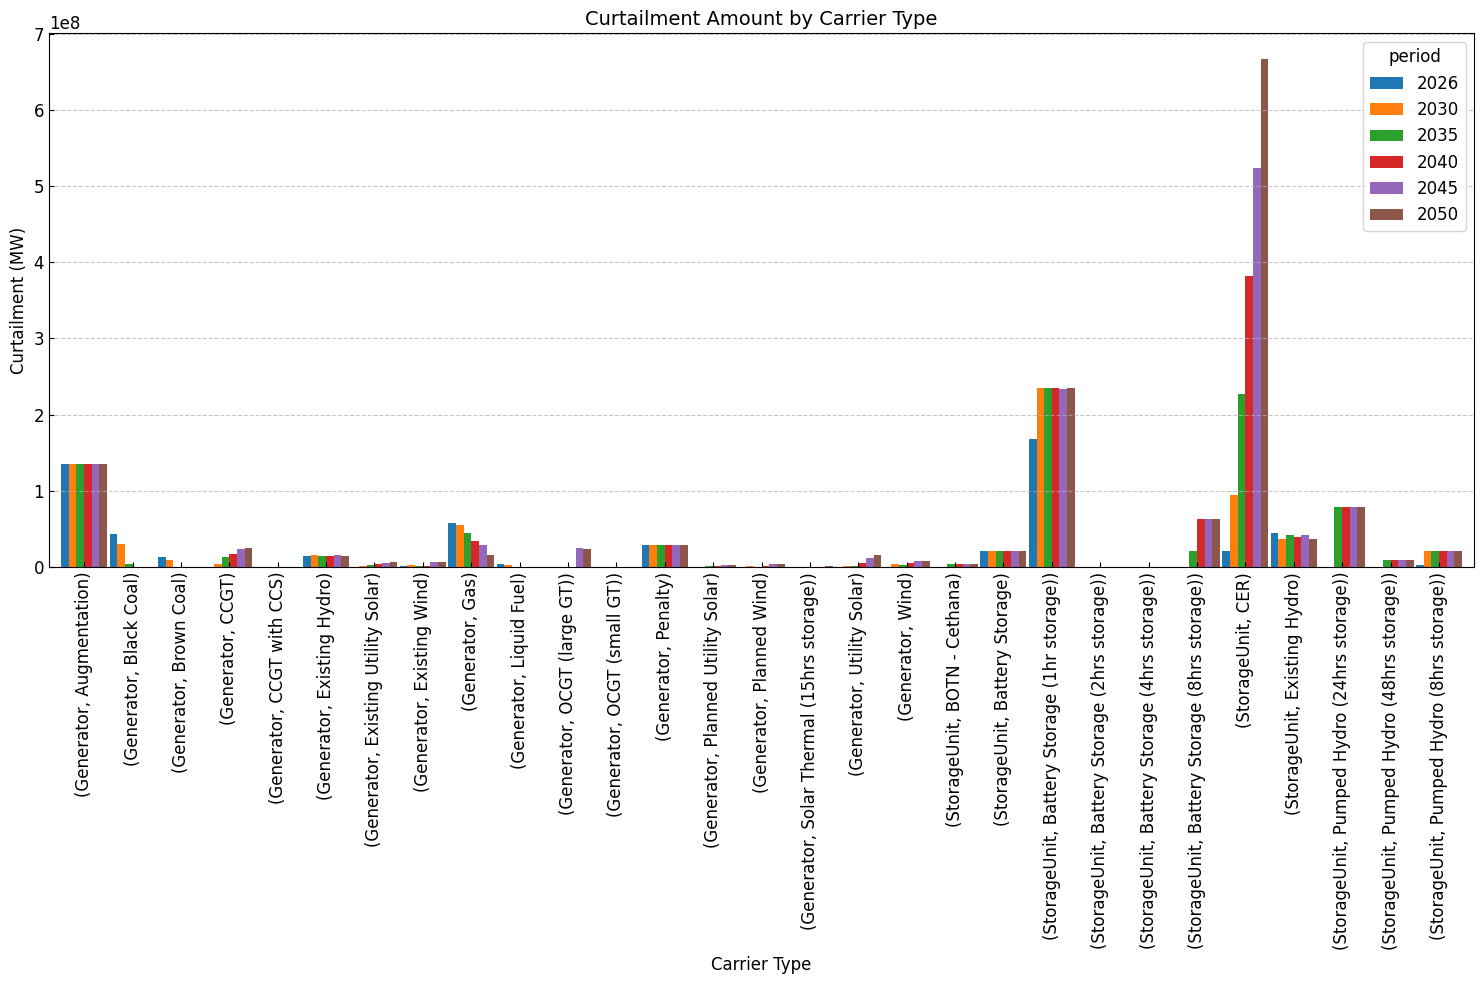

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Global style settings ---
plt.rcParams.update({
    'axes.titlesize': 14,   # title font size
    'font.size': 12,          # default text (labels, ticks, etc.)
    'image.cmap': 'viridis'
})

# --- Your plotting code ---
# data_to_plot = n.generators_t.p['West Kiewa']
# data_to_plot = n.generators_t.p_max_pu['Bayswater (BW01)']
# data_to_plot = n.generators_t.p_max_pu['Darling Downs (DDPS1_GT1)']
# data_to_plot = n.generators_t.p_max_pu['Kiata Wind Farm (KIATAWF1)']
# data_to_plot = n.generators_t.p_max_pu['Gannawarra Solar Farm (GANNSF1)']
# data_to_plot = n.storage_units_t.state_of_charge['Snowy']
# data_to_plot = n.storage_units_t.p['Derwent']

# data_to_plot = n.links_t.p0['NNSW-SQ QNI']
# data_to_plot = n.links_t.p0['CNSW-NNSW']

# data_to_plot = n.generators_t.p[n.generators[n.generators.carrier.isin(["Black Coal","Brown Coal"])].index].sum(axis=1)

# data_to_plot = n.storage_units_t.p['CER_NNSW']

# data_to_plot = n.storage_units_t.p_max_pu['CER_NNSW']*n.storage_units.p_nom['CER_NNSW']

data_to_plot = n.statistics.curtailment() #.plot(kind="bar",figsize=(15,5),rot=90,width=0.95)


fig, ax = plt.subplots(figsize=(15,10))
data_to_plot.plot(ax=ax,kind="bar",width=0.95)

target_years = [2026, 2030, 2035, 2040, 2045, 2050]
# tick_positions = np.linspace(0, len(data_to_plot)*5/6 - 1, len(target_years))
# ax.set_xticks(tick_positions)
# ax.set_xticklabels([str(y) for y in target_years])

ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')

ax.set_title('Curtailment Amount by Carrier Type')
ax.set_ylabel('Curtailment (MW)')
ax.set_xlabel('Carrier Type')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.show()
# plt.savefig("../curtailment.png",dpi=200)


In [217]:
data_to_plot

period  timestep           
2026    2026-02-16 22:30:00    0.0
        2026-02-17 15:30:00    0.0
        2026-02-17 22:30:00    0.0
        2026-02-18 16:30:00    0.0
        2026-02-18 22:30:00    0.0
                              ... 
        2026-05-18 16:00:00    0.0
        2026-05-19 00:00:00    0.0
        2026-05-19 16:00:00    0.0
        2026-05-19 22:30:00    0.0
        2026-05-20 16:30:00    0.0
Name: Derwent, Length: 200, dtype: float64

In [414]:
n.storage_units[n.storage_units.p_nom_opt>0][['bus','p_nom_opt']]

,bus,p_nom_opt
StorageUnit,,
CER_CNSW,CNSW,7.278824
CER_NNSW,NNSW,2.472002
CER_SNSW,SNSW,4.755184
CER_SNW,SNW,39.916431
CER_NQ,NQ,2.599072
...,...,...
Pumped_Hydro_(48hrs_storage)_NQ_2035,NQ,111.000000
Pumped_Hydro_(48hrs_storage)_CQ_2035,CQ,89.000000
Pumped_Hydro_(48hrs_storage)_NNSW_2035,NNSW,500.000000


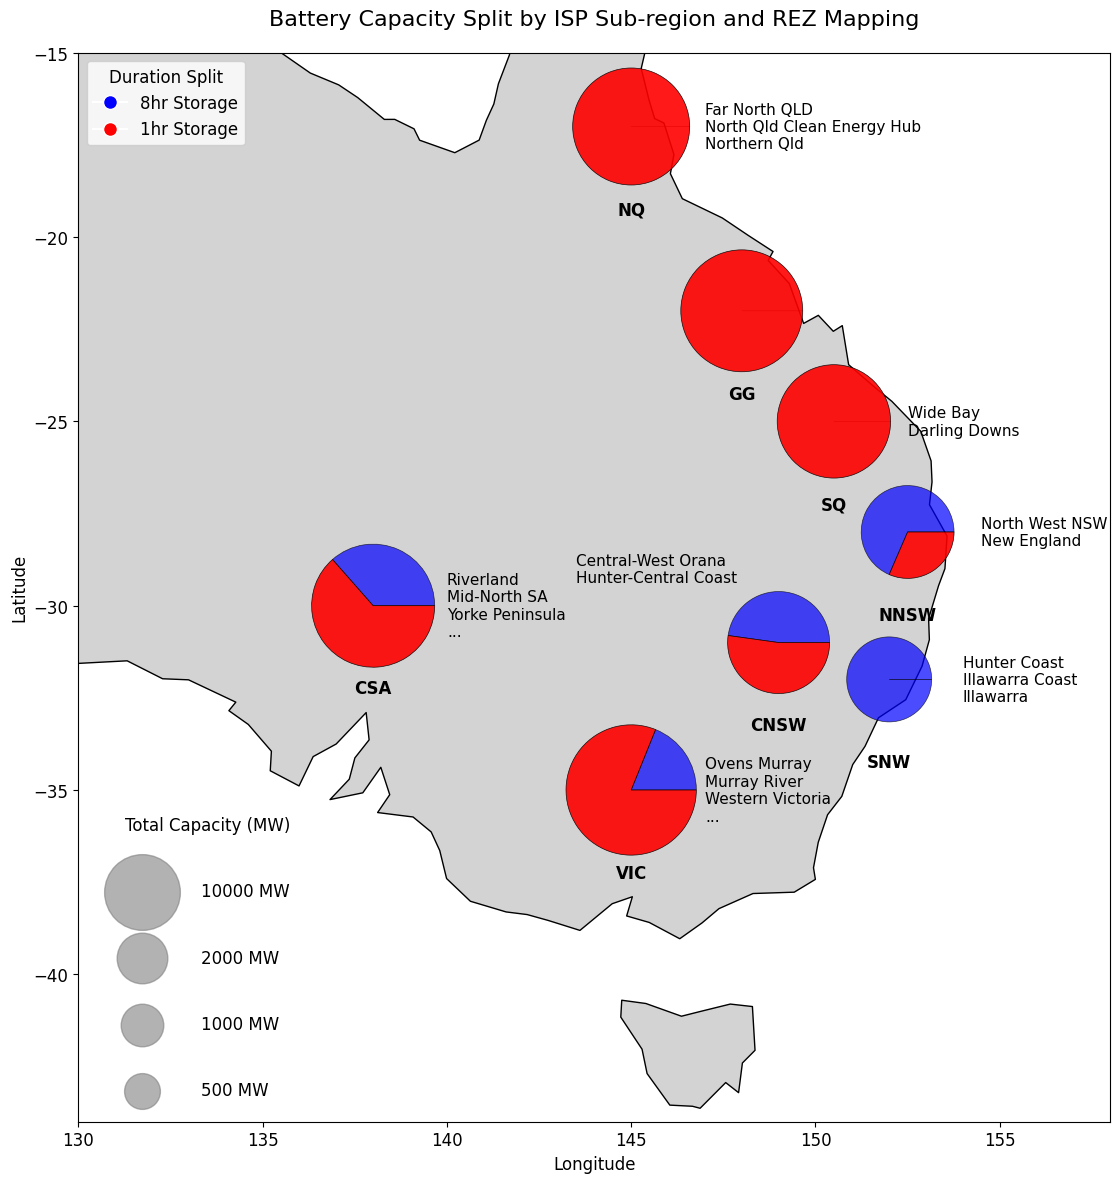

In [470]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Wedge
from matplotlib.lines import Line2D



# --- 1. Define the ISP Sub-region Data (From your provided table) ---
# We convert your table data into a pandas DataFrame for easy grouping

isp_df = pd.read_csv("../isp_sheets_23/REZ/rez_summary.csv")

# --- 2. Build the New REZ Mapping Dictionary ---
# Group the sub-regions by their official ISP Sub-region code
new_rez_mapping = isp_df.groupby('ISP Sub-region')['Name'].apply(list).to_dict()

# --- 3. Define Coordinates and Battery Data (Using the ISP Sub-region Codes) ---
# Coordinates must now be keyed by the ISP Sub-region code
isp_coords = {
    'NQ': (-17, 145.0), 'GG': (-22.0, 148.0), 'SQ': (-25.0, 150.5),
    'NNSW': (-28.0, 152.5), 'CNSW': (-31.0, 149.0), 
    'SNW': (-32.0, 152.0), 'VIC': (-35, 145), 
    'CSA': (-30, 138.0)
}

# Example split battery capacities per ISP Sub-region (Need to aggregate or estimate)
# We will use a simplified aggregation of the old values, mapped to new ISP codes.
capacity_split_isp = {
    'NQ': (2024+2572, 0), 'GG': (2663+2751, 0), 'SQ': (1806+2246, 0),
    'NNSW': (574, 53+1195), 'CNSW': (1385, 53+1215),
    'SNW': (0, 55+1225), 'VIC': (5736,1314+22), 
    'CSA': (3572, 882+1170)
}

# --- 4. Dataframe for Plotting ---
data = pd.DataFrame.from_dict(capacity_split_isp, orient='index', columns=['cap_1hr', 'cap_8hr'])
data.index.name = 'ISP_Sub_region'
data['lon'] = [isp_coords[idx][1] for idx in data.index]
data['lat'] = [isp_coords[idx][0] for idx in data.index]
data['total_cap'] = data['cap_1hr'] + data['cap_8hr']

# Normalize size for pie markers
size_factor = 2500 
data['size'] = np.sqrt(data['total_cap']) * size_factor / np.sqrt(data['total_cap'].max())

# --- 5. Pie Marker Helper Function (Same as before) ---
def plot_pie_marker(ax, lon, lat, cap_1hr, cap_8hr, total_size):
    total = cap_1hr + cap_8hr
    if total == 0: return 
    angle_1hr = (cap_1hr / total) * 360
    radius = np.sqrt(total_size) / 200 
    
    # 8hr Wedge (Blue)
    w8hr = Wedge((lon, lat), r=radius, theta1=0, theta2=360-angle_1hr, 
                 facecolor='blue', alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # 1hr Wedge (Red)
    w1hr = Wedge((lon, lat), r=radius, theta1=360-angle_1hr, theta2=360, 
                 facecolor='red', alpha=0.9, edgecolor='black', linewidth=0.5)
    
    ax.add_patch(w8hr)
    ax.add_patch(w1hr)


# --- 6. Plotting ---
fig, ax = plt.subplots(figsize=(14,12))

# Load Australia shapefile
try:
    world = gpd.read_file("../data/ne_110m_admin_0_countries.shp")
    aus = world[world['ADMIN'] == 'Australia']
    aus.plot(ax=ax, color='lightgrey', edgecolor='black', zorder=1) # Set zorder
except Exception:
    print("Could not load shapefile.")
    aus = gpd.GeoDataFrame({'name': ['Australia']}, geometry=[None])

# Plot Pie Markers and Annotations
for index, row in data.iterrows():
    # Plot the pie marker
    plot_pie_marker(ax, row['lon'], row['lat'], row['cap_1hr'], row['cap_8hr'], row['size']*50)
    
    # Annotate REZs: Get the full list of REZs for this ISP Sub-region
    rezs_list = new_rez_mapping.get(index, [])
    # Join and format the text (only show top 3 for clarity)
    rezs_text = "\n".join(rezs_list[:3]) + ("\n..." if len(rezs_list) > 3 else "")
    
    if index == "CNSW":
        # Place the annotation
        ax.text(row['lon'] - 5.5, row['lat']+2, 
                rezs_text, 
                fontsize=11, 
                ha='left', 
                va='center')

    else:

        # Place the annotation
        ax.text(row['lon'] + 2, row['lat'], 
                rezs_text, 
                fontsize=11, 
                ha='left', 
                va='center')
    
    # Place the ISP Sub-region code next to the pie marker
    ax.text(row['lon'], row['lat']-2, 
            index, 
            fontsize=12, 
            fontweight='bold', 
            ha='center', 
            va='top')


# --- 7. Custom Legend ---
from matplotlib.lines import Line2D 

# Capacity Duration Legend
split_handles = [
    Line2D([0], [0], marker='o', color='w', label='8hr Storage', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='1hr Storage', markerfacecolor='red', markersize=10)
]
legend1 = ax.legend(handles=split_handles, title='Duration Split', loc='upper left', frameon=True)
ax.add_artist(legend1)

# Total Capacity Size Legend 
sizes = [10000,2000, 1000, 500]
legend_handles = [
    plt.scatter([], [], s=np.sqrt(s)*size_factor/np.sqrt(data['total_cap'].max()), 
                color='gray', alpha=0.6, label=f'{s} MW') 
    for s in sizes
]
ax.legend(handles=legend_handles, title='Total Capacity (MW)', bbox_to_anchor=(0.22,0.3), frameon=False,
          labelspacing=2.9,   # Increase vertical space between entries (default is 0.5)
    handletextpad=2.5,  # Increase horizontal space between marker and label text
    markerscale=1)  # Increase the size of the markers in the legend)


# --- 8. Final Map Styling ---
ax.set_title('Battery Capacity Split by ISP Sub-region and REZ Mapping', fontsize=16, pad=20)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
ax.set_xlim(130, 158)  
ax.set_ylim(-44, -15)
plt.tight_layout()
# plt.show()
plt.savefig("../battery_split_step_change.png",dpi=200)

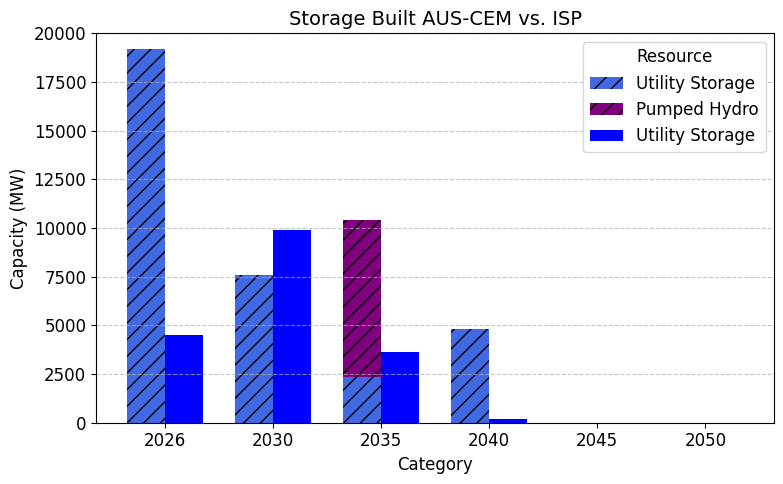

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the Data
categories = [str(y) for y in n.investment_periods]

# Instead of single values, split into solar and wind components
# Example values
set_a_solar = [np.float64(19181.297816732207),
 np.float64(7571.086000990797),
 np.float64(2358.9718114721645),
 np.float64(4828.039142253083),
 np.float64(0.0),
 np.float64(0.0)]
set_a_wind  = [np.float64(0.0),
 np.float64(0.0),
 np.float64(8049.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0)]

set_b_solar = [4526,9889,3621,166,0,0]
set_b_wind  = [np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0)]

x = np.arange(len(categories))  # the label locations
width = 0.35  # width of the bars

# 2. Create Figure and Axes
fig, ax = plt.subplots(figsize=(8, 5))

# 3. Plot stacked bars
# Set A (left)

rects1_solar = ax.bar(x - width/2, set_a_solar, width, label='Utility Storage', color="royalblue", hatch = "//")
rects1_wind  = ax.bar(x - width/2, set_a_wind, width, bottom=set_a_solar,label='Pumped Hydro', color="purple", hatch = "//")

# Set B (right)
rects2_solar = ax.bar(x + width/2, set_b_solar, width, label='Utility Storage', color="blue")
rects2_wind  = ax.bar(x + width/2, set_b_wind, width, bottom=set_b_solar, color="purple")

# 4. Customize
ax.set_title('Storage Built AUS-CEM vs. ISP')
ax.set_ylabel('Capacity (MW)')
ax.set_xlabel('Category')
ax.set_xticks(x, categories)
ax.legend(title='Resource')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim([0,20000])

plt.tight_layout()
plt.show()


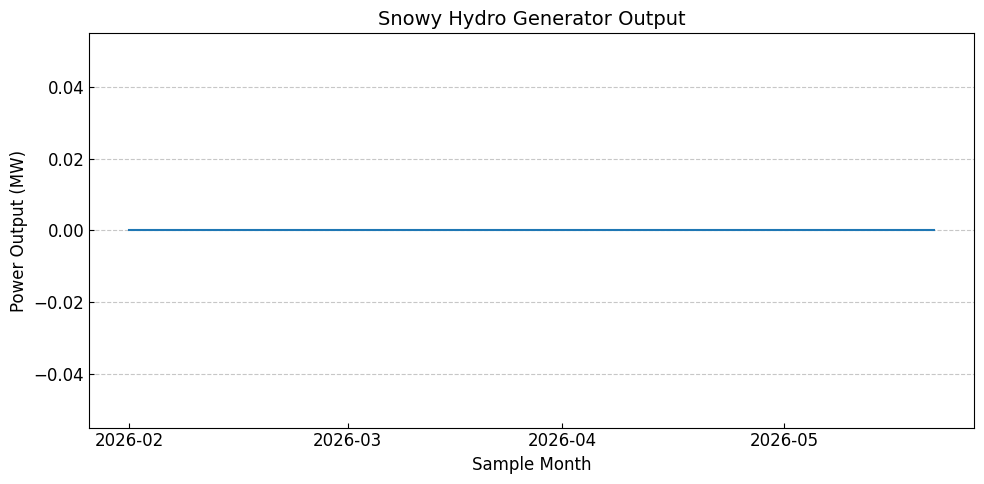

In [223]:
import matplotlib.pyplot as plt
import numpy as np

# --- Global style settings ---
plt.rcParams.update({
    'axes.titlesize': 14,   # title font size
    'font.size': 12          # default text (labels, ticks, etc.)
})

# --- Your plotting code ---
# data_to_plot = n.generators_t.p['West Kiewa'][100:150]
data_to_plot = n.storage_units_t.p['Snowy'][100:300]

fig, ax = plt.subplots(figsize=(10, 5))
data_to_plot.plot(ax=ax)

target_years = [2026, 2030, 2035, 2040, 2045, 2050]
tick_positions = [0,54,54*2-1,54*3]
ax.set_xticks(tick_positions)
ax.set_xticklabels(["2026-02","2026-03","2026-04","2026-05"])

ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')

ax.set_title('Snowy Hydro Generator Output')
ax.set_ylabel('Power Output (MW)')
ax.set_xlabel('Sample Month')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.show()
plt.savefig("../snowy_p_sample.png",dpi=100)


In [103]:
x.sum() / (600*1500)

np.float64(0.604004607227526)

<Axes: xlabel='period,timestep'>

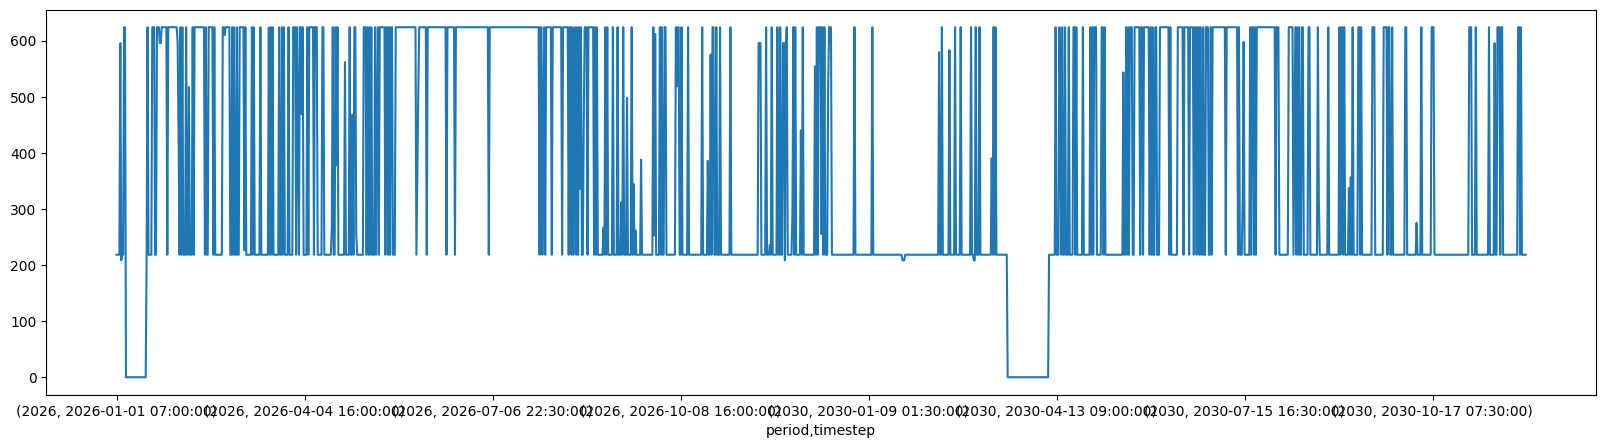

In [99]:
n.generators_t.p['Bayswater (BW01)'][:1500].plot(figsize=(20,5)) 

In [73]:
n.generators[n.generators.p_nom_opt > 30]

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt,lifeTime
Generator,,,,,,,,,,,,,,,,,,,,,
Bayswater (BW01),CNSW,PQ,,623.964,0.0,False,0.0,inf,0.0,1.0,...,0,1,0,NaN,NaN,1.0,1.0,1.0,623.964,NaN
Bayswater (BW02),CNSW,PQ,,647.599,0.0,False,0.0,inf,0.0,1.0,...,0,1,0,NaN,NaN,1.0,1.0,1.0,647.599,NaN
Bayswater (BW03),CNSW,PQ,,647.599,0.0,False,0.0,inf,0.0,1.0,...,0,1,0,NaN,NaN,1.0,1.0,1.0,647.599,NaN
Bayswater (BW04),CNSW,PQ,,647.599,0.0,False,0.0,inf,0.0,1.0,...,0,1,0,NaN,NaN,1.0,1.0,1.0,647.599,NaN
Callide B (CALL_B_1),CQ,PQ,,326.655,0.0,False,0.0,inf,0.0,1.0,...,0,1,0,NaN,NaN,1.0,1.0,1.0,326.655,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T3 Option 1-2029-2030,TAS,PQ,,0.000,0.0,True,690.0,690.0,0.0,1.0,...,0,1,0,NaN,NaN,1.0,1.0,1.0,690.000,1.0
T3 Option 1-2034-2035,TAS,PQ,,0.000,0.0,True,690.0,690.0,0.0,1.0,...,0,1,0,NaN,NaN,1.0,1.0,1.0,690.000,1.0
T3 Option 1-2039-2040,TAS,PQ,,0.000,0.0,True,690.0,690.0,0.0,1.0,...,0,1,0,NaN,NaN,1.0,1.0,1.0,690.000,1.0


In [137]:
n.generators_t.p.index.get_level_values(0).unique()

Index([2026, 2030, 2035, 2040, 2045, 2050], dtype='int32', name='period')

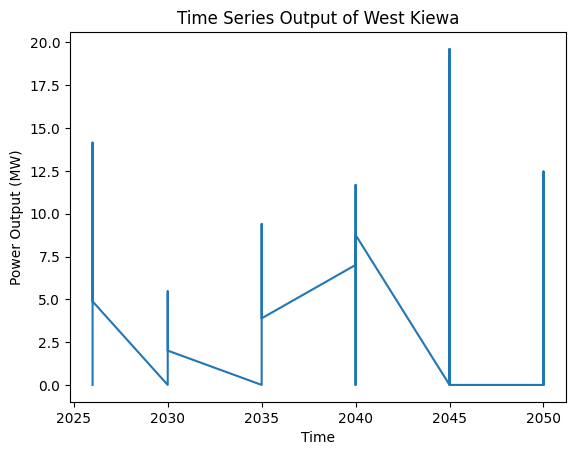

In [138]:
import matplotlib.pyplot as plt

# 1. Select the columns that start with 'West Kiewa' at the first level
west_kiewa_data = n.generators_t.p['West Kiewa']

# west_kiewa_data.index = n.generators_t.p.index.get_level_values(0)

# 2. Plot the resulting DataFrame (this automatically handles the time index)
west_kiewa_data.plot(
    title='Time Series Output of West Kiewa',
    ylabel='Power Output (MW)',
    xlabel='Time'
)



plt.show()

<Axes: xlabel='timestep'>

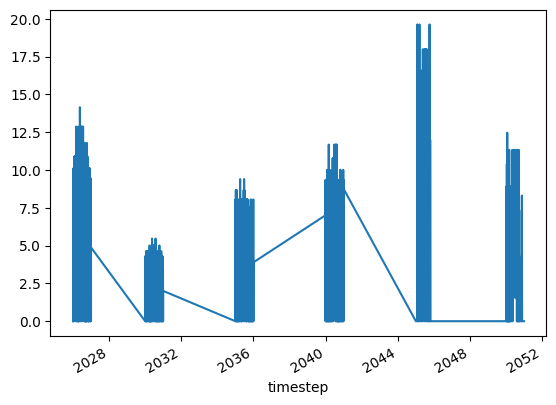

In [131]:
n.generators_t.p['West Kiewa'].plot()

<Axes: xlabel='period,timestep'>

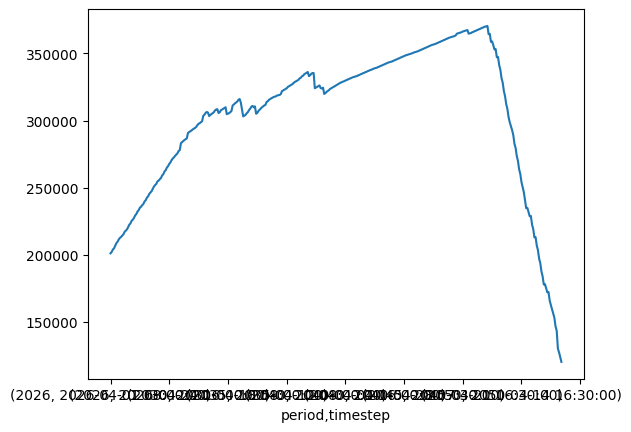

In [75]:
n.storage_units_t.state_of_charge['Derwent'].plot()

In [76]:
n.storage_units.loc["Snowy","state_of_charge_initial"]

np.float64(4000000.0)

<Axes: xlabel='period,timestep'>

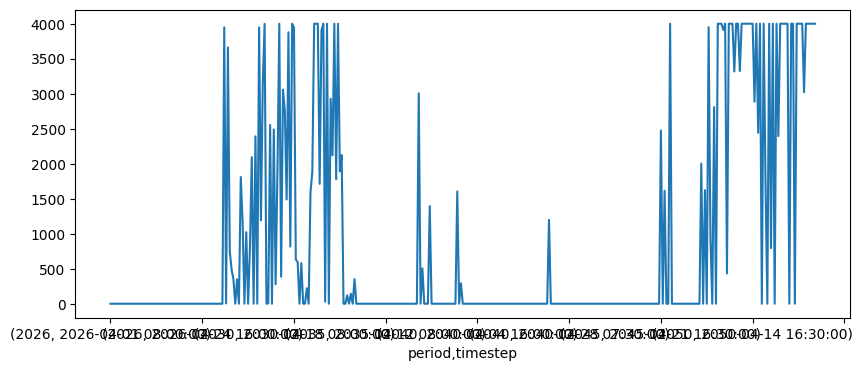

In [77]:
n.storage_units_t.p['Snowy'].plot(figsize=(10,4))

In [78]:
80*24*365/5/12

11680.0

In [79]:
5000*1e3/(24*365)

570.7762557077625

Text(0.5, 1.0, 'Snowy inflows')

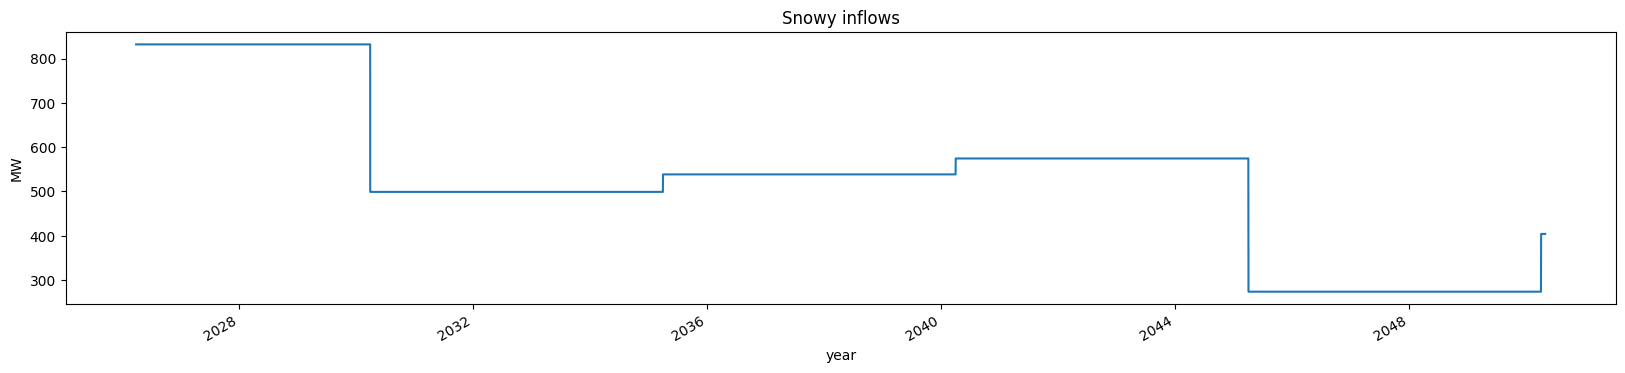

In [80]:
n.storage_units_t.inflow['Snowy'].reset_index().set_index('timestep')['Snowy'].plot(figsize=(20,4))
plt.ylabel("MW")
plt.xlabel("year")
plt.title("Snowy inflows")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

# Example: demand is a pandas Series or DataFrame column with hourly data for a year
# 1 year of hourly data = 365*24 = 8760 hours
# Convert to shape (n_days, 24)
def cluster_days(demand_series, n_clusters=7):
    # Reshape data into days
    n_days = len(demand_series) // 24
    demand_daily = demand_series.values[:n_days*24].reshape(n_days, 24)
    
    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    kmeans.fit(demand_daily)
    
    cluster_centers = kmeans.cluster_centers_
    labels = kmeans.labels_
    
    representative_days = []
    
    for i in range(n_clusters):
        # Indices of days in this cluster
        cluster_indices = np.where(labels == i)[0]
        # Daily profiles in the cluster
        cluster_profiles = demand_daily[cluster_indices]
        # Compute distances to cluster center
        distances = np.linalg.norm(cluster_profiles - cluster_centers[i], axis=1)
        # Find the index of the day closest to the cluster center
        closest_day_idx = cluster_indices[np.argmin(distances)]
        representative_days.append(closest_day_idx)
    
    return representative_days, cluster_centers, labels

# Example usage:
# demand_series = pd.Series(...)  # 8760 hourly values
# rep_days, centers, labels = cluster_days(demand_series, n_clusters=7)
# print("Representative day indices:", rep_days)

In [ ]:
import subprocess
print(subprocess.getoutput("nvidia-smi --query-gpu=name --format=csv,noheader"))


In [ ]:
import gurobipy
print(gurobipy.gurobi.version())


In [ ]:
m.variables['Generator-p']

In [ ]:
m.constraints['Generator-fix-p-upper'].loc[:,"Wind_-_offshore_(floating)_TAS_North_East_Tasmania_Coast_WFL"]

In [ ]:
m.constraints['Generator-fix-p-upper'].loc[:,"Q1_WH_PENALTY"]

In [ ]:
m.constraints["Generator-ext-p-upper"].loc[:,"Q1_WH_PENALTY"]

In [ ]:
m.variables['Generator-p_nom']

In [ ]:
m.variables['Generator-p_nom']

In [ ]:
len(['Wind_NQ_Far_North_QLD_2025_WH', 'Wind_NQ_Far_North_QLD_2026_WH'])

In [ ]:
m.add_constraints(m.variables['Generator-p'].loc[:,"Q1_WH_PENALTY"] <= 0)

In [ ]:
n.investment_periods

In [ ]:
n.generators.carrier

In [ ]:
import matplotlib.pyplot as plt

# Group generator and storage unit capacities by carrier
gen_caps = n.generators.groupby('carrier')['p_nom'].sum()
stor_caps = n.storage_units.groupby('carrier')['p_nom'].sum()

total_caps = gen_caps.add(stor_caps, fill_value=0).sort_values(ascending=False)

total_caps.plot(kind='bar', figsize=(15, 4))
plt.ylabel("Installed Capacity [MW]")
plt.title("Total Generator and Storage Unit Capacities by Carrier (p_nom)")
plt.show()

In [ ]:
storage_mask = n.storage_units.index.str.contains(
                f"Pumped_Hydro_(48hrs_Storage)_CQ"
            )

In [ ]:
n.storage_units[n.storage_units.index.str.startswith("Pumped_Hydro_(48hrs_storage)_CQ")]

In [ ]:
n.storage_units.index.str.startswith(f"Pumped_Hydro_(8hrs_Storage)_CQ").any()

In [ ]:
env = gp.Env()

# Optionally set parameters
env.setParam('Threads', 12)     
env.setParam('Presolve', 2) 
env.setParam('Crossover', 0) 
env.start()

In [ ]:
import xarray as xr

ds = xr.open_dataset("../solutions/isp24_SSLT_run_2026_to_2050_final_PC.nc")
# ds = xr.open_dataset("../solutions/isp24_model_basic_v4.nc")

In [ ]:
ds["StorageUnit-p_dispatch"].StorageUnit

In [ ]:
# Find generators whose names begin with 'K'
k_gens = [gen for gen in ds["StorageUnit-p_dispatch"].StorageUnit.values if gen.startswith("CER_")]

# Extract their generation data
k_gen_data = ds["StorageUnit-p_dispatch"].sel(StorageUnit=k_gens)

In [ ]:
k_gen_data.sel(StorageUnit = "CER_SNSW").plot()

In [ ]:
k_gen_data.plot(figsize=(15, 5))
import matplotlib.pyplot as plt
plt.ylabel("Annual Generation [MW]")
plt.title("Annual Generation from Generator-p")
plt.show()


In [ ]:
pumped_storage_units = [su for su in ds['StorageUnit'].values if 'pumped' in su.lower()]
print(pumped_storage_units)

In [ ]:
k_gen_data

In [ ]:
ds["StorageUnit-state_of_charge"].to_dataframe()[["timestep","StorageUnit-state_of_charge"]]
                                                  #.unstack("StorageUnit").plot(figsize=(15, 5))


In [ ]:
import matplotlib.pyplot as plt

# Extract subregion from generator names (customize pattern as needed)
def get_subregion(gen_name):
    # Example: extract substring before first space or use regex for more complex names
    # Adjust this function based on your naming convention
    for sub in ["NNSW", "CQ", "SQ", "SNSW", "VIC", "TAS", "SA"]:
        if sub in gen_name:
            return sub
    return "Other"

# Map generators to subregions
subregions = [get_subregion(gen) for gen in ds["Generator"].values]

# Sum generation by subregion for each snapshot
gen_df = ds["Generator-p"].to_dataframe().reset_index()
gen_df["Subregion"] = [get_subregion(gen) for gen in gen_df["Generator"]]
total_gen_by_subregion = gen_df.groupby(["snapshot", "Subregion"])["Generator-p"].sum().unstack()

# Plot
total_gen_by_subregion.plot(figsize=(15, 5))
plt.ylabel("Total Generation [MW]")
plt.title("Total Generation by Subregion")
plt.legend(title="Subregion")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# List of hydro units to plot
units_to_plot = ["Anthony", "Snowy", "Derwent","Mersey Forth"]

fig, ax = plt.subplots(figsize=(15, 5))
for su in units_to_plot:
    if su in ds['StorageUnit'].values:
        ds['StorageUnit-p_dispatch'].sel(StorageUnit=su).plot(ax=ax, label=su)

plt.title("StorageUnit p_dispatch for Selected Hydro Units")
plt.ylabel("p_dispatch [MW]")
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Find all existing hydro storage units
hydro_units = [su for su in ds['StorageUnit'].values if 'Existing Hydro' in su]

# Plot p_dispatch for each hydro unit
fig, ax = plt.subplots(figsize=(15, 5))
for su in hydro_units:
    ds['StorageUnit-p_dispatch'].sel(StorageUnit=su).plot(ax=ax, label=su)

plt.title("StorageUnit p_dispatch for Existing Hydro Units")
plt.ylabel("p_dispatch [MW]")
plt.legend()
plt.show()

In [ ]:
# ds
# Plot generation for all coal generators in ds
coal_gens = [gen for gen in ds["Generator"].values if gen in n.generators[n.generators.carrier=="Black Coal"].index]
# for gen in coal_gens:
#     ds["Generator-p"].sel(Generator=gen).plot(figsize=(15, 4), label=gen)
# plt.legend(title="Coal Generators")

# Aggregate daily generation from x (sum across hours for each day)
x["daily_total"] = x[[col for col in x.columns if col.isdigit()]].sum(axis=1)

# Plot aggregated daily generation
plt.figure(figsize=(15, 4))
plt.plot(x["Day"], x["daily_total"], marker="o")
plt.ylabel("Total Daily Generation [MW]")
plt.xlabel("Day")
plt.title("Aggregated Daily Generation (All Hours)")
plt.show()
# plt.ylabel("Generation [MW]")
# plt.title("Bayswater (BW01) Generator-p")
# plt.show()

In [ ]:
x = ds["Generator-p_nom"].where(ds["Generator-p_nom"] > 0, drop=True).to_dataframe()
x

In [ ]:
x = ds["Generator-p_nom"].where(ds["Generator-p_nom"] > 0, drop=True).to_dataframe().plot(kind="bar", figsize=(15, 4))
plt.ylabel("Generator p_nom")
# plt.xticks([i for i, name in enumerate(ds["Generator"].values) if name.startswith("Large_") or name.startswith("Wind_")],
#            [name for name in ds["Generator"].values if name.startswith("Large_") or name.startswith("Wind_")],
#            rotation=90)
plt.title("StorageUnits with p_nom > 0")
plt.show()

In [ ]:
ds["StorageUnit-p_nom"].where(ds["StorageUnit-p_nom"] > 0, drop=True).to_dataframe().plot(kind="bar", figsize=(15, 4))
import matplotlib.pyplot as plt
plt.ylabel("StorageUnit p_nom")
plt.title("StorageUnits with p_nom > 0")
plt.show()

In [ ]:
cq_gens = [gen for gen in ds["Generator"].values if "CQ" in gen]
for gen in cq_gens:
    ds["Generator-p"].sel(Generator=gen).plot(figsize=(15, 4), label=gen)
plt.ylabel("Generation [MW]")
plt.title("Annual Generation for Generators in CQ Region")
plt.legend()
plt.show()

In [ ]:
for line in ds["Link"].values:
    ds["Link-p"].sel(Link=line).plot(figsize=(15, 5), label=line)
    plt.legend(title="Line")
    plt.ylabel("Link Power [MW]")
    plt.title("Power Flow for All Links")
    plt.show()

In [ ]:
ds["Link-p"].sel(Link="VIC-SNSW").plot(figsize=(15, 3))

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 4))
ds["StorageUnit-p_dispatch"].sel(StorageUnit="Anthony").plot(ax=ax, label="p_dispatch")
ds["StorageUnit-p_store"].sel(StorageUnit="Anthony").plot(ax=ax, label="p_store")
ax.set_title("Anthony: p_dispatch and p_store")
ax.legend()
plt.show()

In [ ]:
n.investment_periods

In [ ]:
ds['Generator-p'].sel(Generator='Bayswater (BW01)').plot(figsize=(15, 4))
plt.ylabel("Generation [MW]")
plt.title("Generation for Bayswater (BW01)")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Combine generator and storage capacities
gen_caps = n.generators.groupby('carrier')['p_nom_opt'].sum()
stor_caps = n.storage_units.groupby('carrier')['p_nom_opt'].sum()

total_caps = pd.concat([gen_caps, stor_caps]).sort_values(ascending=False)

total_caps.plot(kind='bar')
plt.ylabel("Installed capacity [MW]")
plt.title("Total optimal capacity by technology")
plt.show()


In [ ]:
n.storage_units_t.p["Ballarat Energy Storage System (BALBG1)"].plot() #['Philip Island BESS (PIBESSG1)'][:200].plot()

In [ ]:
n.buses_t.p["NNSW"][:100].plot()


In [ ]:
n.buses_t.p["SQ"][:100].plot()

In [ ]:
n.statistics.curtailment().loc[[('Generator','Utility Solar'),('Generator','Wind')]].sum().plot(kind="bar")

In [ ]:
new_generation.plot()

In [ ]:
new_storage.plot()

In [ ]:
new_storage = n.storage_units.p_nom_opt - n.storage_units.p_nom

In [ ]:
new_generation = n.generators.p_nom_opt - n.generators.p_nom

In [ ]:
new_storage[new_storage > 0].plot(rot=90)


In [ ]:
new_generation[new_generation > 0].plot(rot=90)

In [ ]:
n.generators.p_nom_opt["Cattle Hill Wind Farm (CTHLWF1)"]

In [ ]:
n.generators_t.p["Cattle Hill Wind Farm (CTHLWF1)"].plot()

In [ ]:
n.links_t.p1['CQ-NQ'].plot()

In [ ]:
n.links_t.p1['CNSW-NNSW'].reset_index().set_index('timestep')['CNSW-NNSW'].plot(figsize=(20,5))
plt.xlabel("Year")
plt.ylabel("MW")
plt.title("CNSW-NNSW (Intra-regoinal)")


In [ ]:
n.links_t.p0['CNSW-NNSW'].plot()

In [ ]:
n.storage_units_t.p["Mersey Forth"].plot()

In [ ]:
m.objective

In [ ]:
24.8396*16.5

In [ ]:
n.generators_t.capital_cost[-2:]

In [ ]:
n.generators_t.capital_cost

In [ ]:
obj

In [ ]:
n.optimize()

In [ ]:
n.generators

In [ ]:
n.statistics.system_cost()

In [ ]:
n.links_t.p0

In [ ]:
n.links_t.p0['TAS-VIC Basslink'].plot()

In [ ]:
x = n.statistics.optimal_capacity()[2024]
x = x[~x.isna()]

In [ ]:
x

In [ ]:
x.plot(kind="bar",figsize=(15,3))

In [ ]:
n.statistics.expanded_capex()[2024]

In [ ]:
n.generators[n.generators.p_nom_extendable==True]['p_nom'].plot()

In [ ]:
n.storage_units

In [ ]:
n.storage_units_t.p.plot(legend=False)

In [ ]:
n.generators_t.p['Adelaide Desalination Plant Solar Farm (ADPPV1)'][:500].plot()

In [ ]:
# show key columns for storage units
cols = ['p_nom', 'p_nom_extendable',  'max_hours', 'capital_cost', 'marginal_cost']
print(n.storage_units[cols].to_string())

# any NaNs?
print("NaNs per column:\n", n.storage_units[cols].isna().sum())


In [ ]:
m.constraints

In [ ]:
n.generators_t.p_max_pu['Angaston (ANGAS1)'].plot()

In [ ]:
n.optimize.create_model()
m = n.model

In [ ]:
m.constraints["Generator-ext-p_nom-lower"]

In [ ]:
n.links_t.keys()

In [ ]:
n.storage_units_t.state_of_charge

In [ ]:
n.storage_units_t.state_of_charge['Anthony'].plot()


In [ ]:
n.storage_units_t.p_dispatch['Anthony'].plot()

In [ ]:
n.storage_units_t.spill['Battery_Storage_(1hr_storage)_NNSW'].plot()


In [ ]:
n.storage_units_t.state_of_charge['Battery_Storage_(1hr_storage)_NNSW'].plot()

In [ ]:
x = n.statistics.energy_balance()[2024]

x = x[~x.isna()]

In [ ]:
x.plot()

In [ ]:
n.storage_units_t.p_store['Battery_Storage_(1hr_storage)_NNSW'].plot()


In [ ]:
n.storage_units_t.p_dispatch['Battery_Storage_(1hr_storage)_NNSW'].plot()

In [ ]:
n.generators_t.keys()

In [ ]:
n.generators_t.p['Large_scale_Solar_PV_NNSW_North_West_NSW'][:].plot()

In [ ]:
n.generators_t.p

In [ ]:
n = pypsa.examples.ac_dc_meshed()

In [ ]:
n.lines

In [ ]:
df.reorder_levels(['period', 'timestep', 'Generator'])

In [ ]:
n.optimize.solve_model()

In [ ]:
n.objective_constant

In [ ]:
m.variables

In [ ]:
m.constraints["StorageUnit-fix-p_dispatch-upper"]


In [ ]:
m.constraints["StorageUnit-fix-state_of_charge-upper"]

In [ ]:
m.constraints["StorageUnit-energy_balance"]

In [ ]:
import pandas as pd

# Extract snapshots
snapshots = n.snapshots  # MultiIndex: (year, timestamp)

# Extract timestamps as a DatetimeIndex
timestamps = pd.to_datetime([ts for _, ts in snapshots])

# Build a mapping from timestamp → full snapshot tuple
snap_map = dict(zip(timestamps, snapshots))

# Group snapshots by day
grouped = pd.Series(list(snap_map.values()), index=timestamps).groupby(lambda x: x.normalize())

for day, day_snaps in grouped:
    day_snaps = day_snaps.values  # the original MultiIndex tuples
    print(day, day_snaps)


In [ ]:
for bat in n.storage_units.index:  # all batteries
    for week, week_snaps in weekly_groups:
        print(week_snaps)

In [ ]:
import pandas as pd

# --- Extract snapshots ---
snapshots = n.snapshots  # MultiIndex: (year, timestamp)
timestamps = pd.to_datetime([ts for _, ts in snapshots])

# Map timestamps to the original MultiIndex tuples
snap_map = dict(zip(timestamps, snapshots))

# Build a Series with DatetimeIndex
snap_series = pd.Series(list(snap_map.values()), index=timestamps)

# --- Group by WEEK ---
weekly_groups = snap_series.groupby(lambda x: x.to_period("W"))

# --- Group by MONTH (optional) ---
monthly_groups = snap_series.groupby(lambda x: x.to_period("M"))

# Access your StorageUnit-state_of_charge variable
soc = n.model["StorageUnit-state_of_charge"]

# --- Example: weekly cyclic constraint for all batteries ---
for bat in n.storage_units.index:  # all batteries
    for week, week_snaps in weekly_groups:
        week_snaps = week_snaps.values  # original MultiIndex tuples
        if len(week_snaps) > 1:
            first_snap = week_snaps[0]
            last_snap = week_snaps[-1]

            print(first_snap)
            print(last_snap)
            
            # n.model.add_constraints(
            #     soc.loc[first_snap, bat] == soc.loc[last_snap, bat],
            #     name=f"cyclic_soc_weekly_{bat}_{week.start_time.strftime('%Y%m%d')}"
            # )

# --- Optional: monthly cyclic constraints ---
# for bat in n.storage_units.index:
#     for month, month_snaps in monthly_groups:
#         month_snaps = month_snaps.values
#         if len(month_snaps) > 1:
#             first_snap = month_snaps[0]
#             last_snap = month_snaps[-1]
#             n.model.add_constraint(
#                 soc.loc[first_snap, bat] == soc.loc[last_snap, bat],
#                 name=f"cyclic_soc_monthly_{bat}_{month.start_time.strftime('%Y%m%d')}"
#             )


In [ ]:
import pandas as pd
# import pyomo.environ as pyo

# Access the PyPSA model and SoC variable
m = n.model
soc = m["StorageUnit-state_of_charge"]

# Split storage units automatically by their max_hours parameter
daily_batteries = n.storage_units.index[n.storage_units.max_hours <= 24]
weekly_batteries = n.storage_units.index[n.storage_units.max_hours > 24]

print("Daily batteries:", daily_batteries.tolist())
print("Weekly batteries:", weekly_batteries.tolist())

# Extract snapshots
snapshots = n.snapshots  # MultiIndex: (year, timestamp)

# Extract timestamps as a DatetimeIndex
timestamps = pd.to_datetime([ts for _, ts in snapshots])

# Build a mapping from timestamp → full snapshot tuple
snap_map = dict(zip(timestamps, snapshots))

# Group snapshots by day
grouped = pd.Series(list(snap_map.values()), index=timestamps).groupby(lambda x: x.normalize())

# --- DAILY BATTERIES ---
# SoC must be the same at the start and end of each day
for bat in daily_batteries:
    for day, day_snaps in grouped:
        day_snaps = day_snaps.index
        if len(day_snaps) > 1:
            first_snap = day_snaps[0]
            last_snap = day_snaps[-1]
            m.add_constraints(
                soc.loc[first_snap, bat] == soc.loc[last_snap, bat],
                name=f"cyclic_soc_daily_{bat}_{day.strftime('%Y%m%d')}"
            )

# --- WEEKLY BATTERIES ---
# SoC must be the same at the start and end of each week
for bat in weekly_batteries:
    for week, week_snaps in n.snapshots.to_series().groupby(n.snapshots.to_period("W")):
        week_snaps = week_snaps.index
        first_snap = week_snaps[0]
        last_snap = week_snaps[-1]
        m.add_constraints(
            soc.loc[first_snap, bat] == soc.loc[last_snap, bat],
            name=f"cyclic_soc_weekly_{bat}_{week.start_time.strftime('%Y%m%d')}"
        )


In [ ]:
n.optimize(solver_name="gurobi")

In [ ]:
m.variables['Generator-p_nom']

In [ ]:
print(n.objective)

In [ ]:
n.generators.p_nom_extendable == True

In [ ]:
n.statistics.optimal_capacity().div(1e3)

In [ ]:
n.statistics.energy_balance.plot.area(linewidth=0, bus_carrier="AC")

In [ ]:
n.generators_t['p_max_pu'].columns

In [ ]:
selected_gens

In [ ]:
rez_gen_map = {'Far North QLD': ['Large_scale_Solar_PV_NQ_Far_North_QLD', 'Solar_Thermal_(15hrs_storage)_NQ_Far_North_QLD', 'Wind_NQ_Far_North_QLD_WH', 'Wind_NQ_Far_North_QLD_WM'], 'North Qld Clean Energy Hub': ['Large_scale_Solar_PV_NQ_North_Qld_Clean_Energy_Hub', 'Solar_Thermal_(15hrs_storage)_NQ_North_Qld_Clean_Energy_Hub', 'Wind_NQ_North_Qld_Clean_Energy_Hub_WH', 'Wind_NQ_North_Qld_Clean_Energy_Hub_WM'], 'Northern Qld': ['Large_scale_Solar_PV_NQ_Northern_Qld', 'Solar_Thermal_(15hrs_storage)_NQ_Northern_Qld', 'Wind_NQ_Northern_Qld_WH', 'Wind_NQ_Northern_Qld_WM'], 'Isaac': ['Large_scale_Solar_PV_CQ_Isaac', 'Solar_Thermal_(15hrs_storage)_CQ_Isaac', 'Wind_CQ_Isaac_WH', 'Wind_CQ_Isaac_WM'], 'Barcaldine': ['Large_scale_Solar_PV_CQ_Barcaldine', 'Solar_Thermal_(15hrs_storage)_CQ_Barcaldine', 'Wind_CQ_Barcaldine_WH', 'Wind_CQ_Barcaldine_WM'], 'Fitzroy': ['Large_scale_Solar_PV_CQ_Fitzroy', 'Solar_Thermal_(15hrs_storage)_CQ_Fitzroy', 'Wind_CQ_Fitzroy_WH', 'Wind_CQ_Fitzroy_WM'], 'Wide Bay': ['Large_scale_Solar_PV_SQ_Wide_Bay', 'Solar_Thermal_(15hrs_storage)_SQ_Wide_Bay', 'Wind_SQ_Wide_Bay_WH', 'Wind_SQ_Wide_Bay_WM'], 'Darling Downs': ['Large_scale_Solar_PV_SQ_Darling_Downs', 'Solar_Thermal_(15hrs_storage)_SQ_Darling_Downs', 'Wind_SQ_Darling_Downs_WH', 'Wind_SQ_Darling_Downs_WM'], 'Banana': ['Large_scale_Solar_PV_CQ_Banana', 'Solar_Thermal_(15hrs_storage)_CQ_Banana', 'Wind_CQ_Banana_WH', 'Wind_CQ_Banana_WM'], 'North West NSW': ['Large_scale_Solar_PV_NNSW_North_West_NSW', 'Solar_Thermal_(15hrs_storage)_NNSW_North_West_NSW', 'Wind_NNSW_North_West_NSW_WH', 'Wind_NNSW_North_West_NSW_WM'], 'New England': ['Large_scale_Solar_PV_NNSW_New_England', 'Solar_Thermal_(15hrs_storage)_NNSW_New_England', 'Wind_NNSW_New_England_WH', 'Wind_NNSW_New_England_WM'], 'Central-West Orana': ['Large_scale_Solar_PV_CNSW_Central-West_Orana', 'Solar_Thermal_(15hrs_storage)_CNSW_Central-West_Orana', 'Wind_CNSW_Central-West_Orana_WH', 'Wind_CNSW_Central-West_Orana_WM'], 'Broken Hill': ['Large_scale_Solar_PV_SNSW_Broken_Hill', 'Solar_Thermal_(15hrs_storage)_SNSW_Broken_Hill', 'Wind_SNSW_Broken_Hill_WH', 'Wind_SNSW_Broken_Hill_WM'], 'South West NSW': ['Large_scale_Solar_PV_SNSW_South_West_NSW', 'Solar_Thermal_(15hrs_storage)_SNSW_South_West_NSW', 'Wind_SNSW_South_West_NSW_WH', 'Wind_SNSW_South_West_NSW_WM'], 'Wagga Wagga': ['Large_scale_Solar_PV_SNSW_Wagga_Wagga', 'Solar_Thermal_(15hrs_storage)_SNSW_Wagga_Wagga', 'Wind_SNSW_Wagga_Wagga_WH', 'Wind_SNSW_Wagga_Wagga_WM'], 'Tumut': ['Large_scale_Solar_PV_SNSW_Tumut', 'Solar_Thermal_(15hrs_storage)_SNSW_Tumut', 'Wind_SNSW_Tumut_WH', 'Wind_SNSW_Tumut_WM'], 'Cooma-Monaro': ['Large_scale_Solar_PV_SNSW_Cooma-Monaro', 'Solar_Thermal_(15hrs_storage)_SNSW_Cooma-Monaro', 'Wind_SNSW_Cooma-Monaro_WH', 'Wind_SNSW_Cooma-Monaro_WM'], 'Hunter-Central Coast': ['Large_scale_Solar_PV_CNSW_Hunter-Central_Coast', 'Solar_Thermal_(15hrs_storage)_CNSW_Hunter-Central_Coast', 'Wind_CNSW_Hunter-Central_Coast_WH', 'Wind_CNSW_Hunter-Central_Coast_WM'], 'Ovens Murray': ['Large_scale_Solar_PV_VIC_Ovens_Murray', 'Solar_Thermal_(15hrs_storage)_VIC_Ovens_Murray', 'Wind_VIC_Ovens_Murray_WH', 'Wind_VIC_Ovens_Murray_WM'], 'Murray River': ['Large_scale_Solar_PV_VIC_Murray_River', 'Solar_Thermal_(15hrs_storage)_VIC_Murray_River', 'Wind_VIC_Murray_River_WH', 'Wind_VIC_Murray_River_WM'], 'Western Victoria': ['Large_scale_Solar_PV_VIC_Western_Victoria', 'Solar_Thermal_(15hrs_storage)_VIC_Western_Victoria', 'Wind_VIC_Western_Victoria_WH', 'Wind_VIC_Western_Victoria_WM'], 'South West Victoria': ['Large_scale_Solar_PV_VIC_South_West_Victoria', 'Solar_Thermal_(15hrs_storage)_VIC_South_West_Victoria', 'Wind_VIC_South_West_Victoria_WH', 'Wind_VIC_South_West_Victoria_WM'], 'Gippsland': ['Large_scale_Solar_PV_VIC_Gippsland', 'Solar_Thermal_(15hrs_storage)_VIC_Gippsland', 'Wind_VIC_Gippsland_WH', 'Wind_VIC_Gippsland_WM'], 'Central North Vic': ['Large_scale_Solar_PV_VIC_Central_North_Vic', 'Solar_Thermal_(15hrs_storage)_VIC_Central_North_Vic', 'Wind_VIC_Central_North_Vic_WH', 'Wind_VIC_Central_North_Vic_WM'], 'South East SA': ['Large_scale_Solar_PV_SESA_South_East_SA', 'Solar_Thermal_(15hrs_storage)_SESA_South_East_SA', 'Wind_SESA_South_East_SA_WH', 'Wind_SESA_South_East_SA_WM'], 'Riverland': ['Large_scale_Solar_PV_CSA_Riverland', 'Solar_Thermal_(15hrs_storage)_CSA_Riverland', 'Wind_CSA_Riverland_WH', 'Wind_CSA_Riverland_WM'], 'Mid-North SA': ['Large_scale_Solar_PV_CSA_Mid-North_SA', 'Solar_Thermal_(15hrs_storage)_CSA_Mid-North_SA', 'Wind_CSA_Mid-North_SA_WH', 'Wind_CSA_Mid-North_SA_WM'], 'Yorke Peninsula': ['Large_scale_Solar_PV_CSA_Yorke_Peninsula', 'Solar_Thermal_(15hrs_storage)_CSA_Yorke_Peninsula', 'Wind_CSA_Yorke_Peninsula_WH', 'Wind_CSA_Yorke_Peninsula_WM'], 'Northern SA': ['Large_scale_Solar_PV_CSA_Northern_SA', 'Solar_Thermal_(15hrs_storage)_CSA_Northern_SA', 'Wind_CSA_Northern_SA_WH', 'Wind_CSA_Northern_SA_WM'], 'Leigh Creek': ['Large_scale_Solar_PV_CSA_Leigh_Creek', 'Solar_Thermal_(15hrs_storage)_CSA_Leigh_Creek', 'Wind_CSA_Leigh_Creek_WH', 'Wind_CSA_Leigh_Creek_WM'], 'Roxby Downs': ['Large_scale_Solar_PV_CSA_Roxby_Downs', 'Solar_Thermal_(15hrs_storage)_CSA_Roxby_Downs', 'Wind_CSA_Roxby_Downs_WH', 'Wind_CSA_Roxby_Downs_WM'], 'Eastern Eyre Peninsula': ['Large_scale_Solar_PV_CSA_Eastern_Eyre_Peninsula', 'Solar_Thermal_(15hrs_storage)_CSA_Eastern_Eyre_Peninsula', 'Wind_CSA_Eastern_Eyre_Peninsula_WH', 'Wind_CSA_Eastern_Eyre_Peninsula_WM'], 'Western Eyre Peninsula': ['Large_scale_Solar_PV_CSA_Western_Eyre_Peninsula', 'Solar_Thermal_(15hrs_storage)_CSA_Western_Eyre_Peninsula', 'Wind_CSA_Western_Eyre_Peninsula_WH', 'Wind_CSA_Western_Eyre_Peninsula_WM'], 'North East Tasmania': ['Large_scale_Solar_PV_TAS_North_East_Tasmania', 'Solar_Thermal_(15hrs_storage)_TAS_North_East_Tasmania', 'Wind_TAS_North_East_Tasmania_WFL'], 'North West Tasmania': ['Large_scale_Solar_PV_TAS_North_West_Tasmania', 'Solar_Thermal_(15hrs_storage)_TAS_North_West_Tasmania', 'Wind_TAS_North_West_Tasmania_WFL'], 'Central Highlands': ['Large_scale_Solar_PV_TAS_Central_Highlands', 'Solar_Thermal_(15hrs_storage)_TAS_Central_Highlands', 'Battery_Storage_(2hrs_storage)_TAS_Central_Highlands', 'Battery_Storage_(8hrs_storage)_TAS_Central_Highlands', 'Wind_TAS_Central_Highlands_WH', 'Wind_TAS_Central_Highlands_WM'], 'Illawarra': ['Wind_SNW_Illawarra_WFL'], 'Hunter Coast': ['Wind_-_offshore_(fixed)_SNW_Hunter_Coast_WFL', 'Wind_-_offshore_(floating)_SNW_Hunter_Coast_WFL'], 'Illawarra Coast': ['Wind_-_offshore_(fixed)_SNW_Illawarra_Coast_WFL', 'Wind_-_offshore_(floating)_SNW_Illawarra_Coast_WFL'], 'Gippsland Coast': ['Wind_-_offshore_(fixed)_VIC_Gippsland_Coast_WFL', 'Wind_-_offshore_(floating)_VIC_Gippsland_Coast_WFL'], 'Portland Coast': ['Wind_-_offshore_(fixed)_VIC_Portland_Coast_WFL', 'Wind_-_offshore_(floating)_VIC_Portland_Coast_WFL'], 'South East SA Coast': ['Wind_-_offshore_(fixed)_SESA_South_East_SA_Coast_WFL', 'Wind_-_offshore_(floating)_SESA_South_East_SA_Coast_WFL'], 'North West Tasmania Coast': ['Wind_-_offshore_(fixed)_TAS_North_West_Tasmania_Coast_WFL', 'Wind_-_offshore_(floating)_TAS_North_West_Tasmania_Coast_WFL'], 'North East Tasmania Coast': ['Wind_-_offshore_(fixed)_TAS_North_East_Tasmania_Coast_WFL', 'Wind_-_offshore_(floating)_TAS_North_East_Tasmania_Coast_WFL']}
# 'New South Wales Non-REZ': ['Large_scale_Solar_PV_CNSW_New_South_Wales_Non-REZ', 'Solar_Thermal_(15hrs_storage)_CNSW_New_South_Wales_Non-REZ', 'Wind_CNSW_New_South_Wales_Non-REZ_WH', 'Wind_CNSW_New_South_Wales_Non-REZ_WM'], 
#     'Victoria Non-REZ': ['Large_scale_Solar_PV_VIC_Victoria_Non-REZ', 'Solar_Thermal_(15hrs_storage)_VIC_Victoria_Non-REZ', 'Wind_VIC_Victoria_Non-REZ_WH', 'Wind_VIC_Victoria_Non-REZ_WM']}

In [ ]:
non_rez_gen_maps = {'New South Wales Non-REZ': ['Large_scale_Solar_PV_CNSW_New_South_Wales_Non-REZ', 'Solar_Thermal_(15hrs_storage)_CNSW_New_South_Wales_Non-REZ', 'Wind_CNSW_New_South_Wales_Non-REZ_WH', 'Wind_CNSW_New_South_Wales_Non-REZ_WM'], 
                    'Victoria Non-REZ': ['Large_scale_Solar_PV_VIC_Victoria_Non-REZ', 'Solar_Thermal_(15hrs_storage)_VIC_Victoria_Non-REZ', 'Wind_VIC_Victoria_Non-REZ_WH', 'Wind_VIC_Victoria_Non-REZ_WM']}

In [ ]:
import pandas as pd

fns=["REZ_augmentation/rez_initial.csv",
        "REZ_augmentation/rez_single_aug_max.csv",
        "REZ_augmentation/rez_single_aug_min.csv",
        "REZ_augmentation/rez_single_aug_costs.csv",
        "REZ_augmentation/soft_and_hard_limits.csv",
        "maximum_capacity/all.csv",
        "summary_mapping/all.csv",
        "summary_mapping/rez_batteries.csv"]
    
m = n.model
    
path = "../isp_sheets_23/"
# read limit files

initial_limit = pd.read_csv(path + fns[0],index_col=1)
aug_max = pd.read_csv(path + fns[1],index_col=0)
aug_min = pd.read_csv(path + fns[2],index_col=0)
aug_cost = pd.read_csv(path + fns[3],index_col=0)

soft_hard_limit = pd.read_csv(path + fns[4])

rezIDmap = soft_hard_limit.set_index("REZ Name")['REZ ID'].to_dict()

# read gen and storage files

maxs = pd.read_csv(path + fns[5],index_col=0)
gens = pd.read_csv(path + fns[6],index_col=0)
rez_storage = pd.read_csv(path + fns[7],index_col=0)

# rez map

# rez_to_gens = gens[~gens['REZ location'].isna()].groupby('REZ location')['Generator'].apply(list).to_dict()
# rez_to_storage = rez_storage[~rez_storage['REZ location'].isna()].groupby('REZ location')['Batteries'].apply(list).to_dict()

In [ ]:
from collections import defaultdict as dd

rezGenMap = gens[~gens['REZ location'].isna()]['REZ location'].to_dict()

rezCapSolar = dd(float)
rezCapWind = dd(float)

for key in rezGenMap.keys():

    # print(rezGenMapDF.at[key,"Fuel type"])

    if gens.at[key,"Fuel type"] == "Solar":

        rezCapSolar[rezGenMap[key]] += maxs.at[key,"Installed capacity (MW)"] 

    if gens.at[key,"Fuel type"] == "Wind":

        rezCapSolar[rezGenMap[key]] += maxs.at[key,"Installed capacity (MW)"] 

In [ ]:
n.optimize.create_model()
m= n.model

for key in non_rez_gen_maps.keys():

    wind = [w for w in non_rez_gen_maps[key] if "Wind" in w]

    solar = [s for s in non_rez_gen_maps[key] if "Solar" in s]

    PENALTY = 1 # already put as build cost
    
    wind_var = m.variables['Generator-p_nom'].loc[wind]

    solar_var = m.variables['Generator-p_nom'].loc[solar]

    if "Victoria" in key:

        m.add_constraints(
            wind_var.sum() <= 291, name = "Victoria Non-REZ Wind Hard Limit"
        )

        m.add_constraints(
            solar_var.sum() <= 699, name = "Victoria Non-REZ Solar Hard Limit"
        )

    if "New South Wales" in key:

        m.add_constraints(
            wind_var.sum() <= 699, name = "New South Wales Non-REZ Wind Hard Limit"
        )

        m.add_constraints(
            solar_var.sum() <= 1679, name = "New South Wales Non-REZ Solar Hard Limit"
        )

In [ ]:
import re

snaps = n.snapshots

# m.remove_constraints("Generator-ext-p-lower")
# m.remove_constraints("Generator-ext-p-upper")
# m.remove_constraints("Generator-ext-p_nom-lower")
# m.remove_constraints("Generator-ext-p_nom-upper")

# SPLIT BY SOLAR AND WIND
# gens_solar = gens[...]
# gens_wind = gens[...]

# rez_to_gens_solar = gens[~gens['REZ location'].isna()].groupby('REZ location')['Generator'].apply(list).to_dict()
# rez_to_storage = rez_storage[~rez_storage['REZ location'].isna()].groupby('REZ location')['Batteries'].apply(list).to_dict()

for _,row in soft_hard_limit.iterrows():

    name = row['REZ Name']

    rezID = rezIDmap[name]

    # print(name)

    print(rezID)

    # pattern1 = ""
    # pattern2 = ""
    pattern3 = ""

    # if name in rez_to_gens.keys():
    #     pattern1 = "|".join([re.escape(p) for p in rez_to_gens[name]])
    
    # if name in rez_to_storage.keys():
    #     pattern2 = "|".join([re.escape(p) for p in rez_to_storage[name]])

    if name in rez_gen_map.keys():
        pattern3 = "|".join([re.escape(p) for p in rez_gen_map[name]])

    # Suppose you have a list of patterns, e.g.:
    # patterns = [pattern1, pattern2, pattern3]
    patterns = [pattern3]

    # To join them with "|" but avoid leading/trailing "|":
    pattern_str = "|".join([p for p in patterns if p])

    # print(pattern_str)

    rez_gens = n.generators[n.generators.index.str.contains(pattern_str,regex=True)].index.to_list()

    # REZ_VAR = m.variables['Generator-p_nom'].loc[rez_gens]

    WH = m.variables['Generator-p_nom'].loc[[rez_gen for rez_gen in rez_gens if '_WH' in rez_gen]]
    WM = m.variables['Generator-p_nom'].loc[[rez_gen for rez_gen in rez_gens if '_WM' in rez_gen]]
    WFX = m.variables['Generator-p_nom'].loc[[rez_gen for rez_gen in rez_gens if '_WFX' in rez_gen]]
    WFL = m.variables['Generator-p_nom'].loc[[rez_gen for rez_gen in rez_gens if '_WFL' in rez_gen]]

    SAT = m.variables['Generator-p_nom'].loc[[rez_gen for rez_gen in rez_gens if 'Large_scale_Solar_PV' in rez_gen]]
    CST = m.variables['Generator-p_nom'].loc[[rez_gen for rez_gen in rez_gens if 'Solar_Thermal' in rez_gen]]

    wind_group = []
    solar_group = []

    if WH.size > 0:
        WH_PENALTY = m.add_variables(lower=0,name=f"{rezID}-WH-penalty")

        m.add_constraints(
            WH.sum() <= row['WH'] + WH_PENALTY, name = f"{rezID}-WH-soft_limit"
        )

        m.objective += 1000 * (row['Resource penalty'] + row['Transmission expansion penalty']) * WH_PENALTY

        wind_group.append(WH.sum())

    if WM.size > 0:
        WM_PENALTY = m.add_variables(lower=0,name=f"{rezID}-WM-penalty")

        m.add_constraints(
            WM.sum() <= row['WM'] + WM_PENALTY, name = f"{rezID}-WM-soft_limit"
        )

        m.objective += 1000 * (row['Resource penalty'] + row['Transmission expansion penalty']) * WM_PENALTY

        wind_group.append(WM.sum())

    if WFX.size > 0:
        WFX_PENALTY = m.add_variables(lower=0,name=f"{rezID}-WFX-penalty")

        m.add_constraints(
            WFX.sum() <= row['WFX'] + WFX_PENALTY, name = f"{rezID}-WFX-soft_limit"
        )

        m.objective += 1000 * (row['Resource penalty'] + row['Transmission expansion penalty']) * WFX_PENALTY

        wind_group.append(WFX.sum())

    if WFL.size > 0:
        WFL_PENALTY = m.add_variables(lower=0,name=f"{rezID}-WFL-penalty")

        m.add_constraints(
            WFL.sum() <= row['WFL'] + WFL_PENALTY, name = f"{rezID}-WFL-soft_limit"
        )

        m.objective += 1000 * (row['Resource penalty'] + row['Transmission expansion penalty']) * WFL_PENALTY

        wind_group.append(WFL.sum())

    if SAT.size > 0:
        SAT_PENALTY = m.add_variables(lower=0,name=f"{rezID}-SAT-penalty")

        m.add_constraints(
            SAT.sum() <= row['WFL'] + SAT_PENALTY, name = f"{rezID}-SAT-soft_limit"
        )

        m.objective += 1000 * (row['Resource penalty'] + row['Transmission expansion penalty']) * SAT_PENALTY

        solar_group.append(SAT.sum())

        if CST.size > 0:

            solar_group.append(CST.sum())

    
    if wind_group:

        m.add_constraints(
            sum(wind_group) + rezCapWind[name] <= row["Wind Hard Limit"], name = f"{rezID}-Wind-hard_limit"
        )

    if solar_group:

        m.add_constraints(
            sum(solar_group) + rezCapSolar[name] <= row["Solar Hard Limit"], name = f"{rezID}-Solar-hard_limit"
        )

    # # "T2","T3","V2","V6"

    # # REDO Constraints so that it is for each year

    # m.remove_variables('Generator-p_nom') # replace with own extension variable 

    # re write the constraint as Gen

    # Generator-p_nom is linked with the build cost of the generator itself

    # the REZ augmentation provides the transmission cost

    # 2024

    # m.variables['Generator-p'].loc[year,rez_gens] <= m.variables['Generator-p_nom'].loc[year,rez_gens] 


    # if rezID in initial_limit.index:

    #     # region_day_type = self._get_region_mapping()

    #     # dates = region_day_type[initial_limit.loc[rezID,"Day Type"]]

    #     # from_date = pd.to_datetime(row["Date From"],dayfirst=True,errors="coerce")
    #     # to_date = pd.to_datetime(row["Date To"],dayfirst=True,errors="coerce")

    #     # mask = (dates >= (from_date.year,from_date)) & (dates < (to_date.year,to_date))

    #     # cap_dates = dates[mask]

    #     # if pd.notna(initial_limit.loc[rezID,"Day Type"]):
    #     #     INI_HOT = 
    #     # else:
    #     #     
    #     INITIAL = initial_limit.loc[rezID,"Limit"]

    #     # implement day type slicing
    #     val = initial_limit.loc[rezID, "Day Type"]

    #     if (pd.notna(val).any() if hasattr(val, "__iter__") and not isinstance(val, str)
    #         else pd.notna(val)):
    #         print("True")
    #         print(INITIAL)

    #         INITIAL = initial_limit.loc[rezID,"Limit"].iloc[0]

    #     aug_cost_t = aug_cost[aug_cost["ID"]==rezID]

    #     # print(aug_cost)


    #     # loop through each year

    #     for aname,arow in aug_cost_t.iterrows():

    #         # aname = arow["Name"] 

    #         # row["ID"]

    #         # row["Build Cost"]

    #         date_from = pd.to_datetime(arow["Date From"])

    #         if date_from.year > 2030:
    #             continue

    #         date_to = pd.to_datetime(arow["Date To"])

    #         date_range = snaps[(snaps>(date_from.year,date_from)) & (snaps<(date_to.year,date_to))]

    #         REZ_p_VAR = m.variables['Generator-p'].loc[date_range,rez_gens]
    #         REZ_p_nom_VAR = m.variables['Generator-p_nom'].loc[rez_gens]

    #         # print(REZ_VAR)

    #         if aname in aug_min.index:

    #             amin = aug_min.loc[aname,"Min"]

    #         else:

    #             amin = INITIAL

    #         amax = aug_max.loc[aname,"Max"]

    #         AUG_VAR = m.add_variables(lower = amin, upper = amax, name = f"{aname}-{date_from.year}-{date_to.year}")

    #         m.add_constraints(
    #             REZ_p_VAR <= REZ_p_nom_VAR + AUG_VAR, name = f"Single-REZ-Limit-{aname}-{date_from.year}-{date_to.year}"
    #         )

    #         m.objective += AUG_VAR * arow["Build Cost"] * 1000

In [ ]:
mask = m["Generator-p"].indexes.get_all_coords("Generator")['Generator'].to_index().str.contains("_WH|_WM|_WFL|_WFX|_SAT|_CST")

In [ ]:
mask2 = m["Generator-p"].loc[(2030,("2030-12-30")):,mask]

In [ ]:
m.remove_variables("Generator-p")

In [ ]:
m.solution

In [ ]:
ds

In [ ]:
import matplotlib.pyplot as plt

# Find all data variables with 'penalty' in the name and no coordinates
penalty_vars = [v for v in ds.data_vars if 'penalty' in v and ds[v].dims == ()]

# Extract their values
penalty_values = {v: float(ds[v].values) for v in penalty_vars}

# Plot as bar plot
plt.bar(penalty_values.keys(), penalty_values.values())
plt.ylabel("Penalty Value")
plt.xticks(rotation=90)
plt.title("Penalty Variables (No Coordinates)")
plt.show()

In [ ]:
import xarray as xr

ds = xr.open_dataset("../solutions/isp24_model_basic_v2.nc")

In [ ]:
test = m.solution.reset_index(dims_or_levels="period") #.to_netcdf("./test.nc")

In [ ]:
test

In [ ]:
test["StorageUnit-state_of_charge"].sel(StorageUnit="Anthony").plot(figsize=(15, 3))


In [ ]:
test["StorageUnit-p_dispatch"].sel(StorageUnit="Anthony").plot(figsize=(15, 3))

In [ ]:
test["Link-p"].sel(Link="VIC-SNSW").plot.line(x="period", figsize=(15, 3))

In [ ]:
test["Generator-p_nom"][test["Generator-p_nom"] > 0].sel({"Generator-ext":['Large_scale_Solar_PV_CQ_Isaac_2030',
       'Large_scale_Solar_PV_CQ_Barcaldine_2030',
       'Large_scale_Solar_PV_SQ_Wide_Bay_2030',
       'Large_scale_Solar_PV_SQ_Darling_Downs_2030',
       'Large_scale_Solar_PV_NNSW_New_England_2030',
       'Large_scale_Solar_PV_CNSW_Hunter-Central_Coast_2030',
       'Large_scale_Solar_PV_VIC_Murray_River_2030',
       'Large_scale_Solar_PV_CSA_Northern_SA_2030',
       'Large_scale_Solar_PV_CSA_Leigh_Creek_2030',
       'Wind_NQ_Far_North_QLD_2030_WM', 'Wind_CQ_Isaac_2030_WM',
       'Wind_CQ_Barcaldine_2030_WH', 'Wind_CQ_Fitzroy_2030_WH',
       'Wind_SQ_Darling_Downs_2030_WH', 'Wind_NNSW_New_England_2030_WM',
       'Wind_CNSW_Central-West_Orana_2030_WH',
       'Wind_SNSW_Cooma-Monaro_2030_WH',
       'Wind_CNSW_Hunter-Central_Coast_2030_WH', 'Wind_SNW_Illawarra_2030_WFL',
       'Wind_CSA_Leigh_Creek_2030_WH', 'Wind_TAS_Central_Highlands_2030_WH',
       'Wind_-_offshore_(fixed)_SNW_Hunter_Coast_2030_WFL']}).to_dataframe().plot(kind="bar")

In [ ]:
m

In [ ]:
m.solve()

In [ ]:
aug_max.at[aname,"Max"]

In [ ]:
REZ_p_VAR

In [ ]:
REZ_p_VAR[:,0].coords

In [ ]:
WFL.sum()

In [ ]:
REZ_p_VAR[:,0].coords

In [ ]:
test = m.add_variables(lower=0,upper=10,name=f"{rezID}-test15",coords=REZ_p_VAR[:,0].coords)
test

In [ ]:
m.add_constraints(REZ_p_nom_VAR.sum() <= test,name="test11")#coords=REZ_p_VAR[:1,1].coords)

In [ ]:
m.constraints["New South Wales Non-REZ Wind Hard Limit"]

In [ ]:
AUG_VAR

In [ ]:
m.variables['T3-SAT-penalty']

In [ ]:
m.solve(solver_name="gurobi")

In [ ]:
n.statistics.expanded_capacity()

In [ ]:
n.statistics.expanded_capex()

In [ ]:
m.constraints

In [ ]:
m.constraints #["Generator-ext-p_nom-upper"] #['Generator-p_nom'] #["Generator-fix-p-lower"]

In [ ]:
m.variables

In [ ]:
aug_min.loc['V2',"Name"]

In [ ]:
aug_max.loc['V2'][aug_max.loc['V2']["Date From"]=="1/07/2032"]

In [ ]:
if "V2" in initial_limit.index:
    print(initial_limit.loc["V2","Limit"])

In [ ]:
aug_max

In [ ]:
initial_limit.loc["V2"]

In [ ]:
m.constraints

In [ ]:
m.constraints['S5-Solar-hard_limit']

In [ ]:
m.constraints['S5-SAT-soft_limit']

In [ ]:
import re
pattern_str = "|".join([re.escape(p) for p in patterns])
pattern_str = pattern_str[2:]

In [ ]:
n.generators[n.generators.index.str.contains(pattern_str,regex=True)].index.to_list()

In [ ]:
import re

patterns = [
    "Wind_-_offshore_(fixed)_TAS_North_East_Tasmania_Coast",
    "Wind_-_offshore_(floating)_TAS_North_East_Tasmania_Coast"
]
# Escape each pattern, then join with unescaped '|'
pattern_str = "|".join([re.escape(p) for p in patterns])

# Use regex=True
matches = n.generators[n.generators.index.str.contains(pattern_str, regex=True)].index.to_list()

In [ ]:
matches

In [ ]:
rez_to_storage['Murray River']

In [ ]:
rez_to_gens['Central-West Orana']

In [ ]:
rez_gen_map['Central-West Orana']

In [ ]:
rezIDmap

In [ ]:
rez_to_storage

In [ ]:
n.model.variables['Generator-p_nom']

In [ ]:
n.carriers

In [ ]:
n.snapshots.get_level_values(1)

In [ ]:
import pandas as pd

# Load timeslice file
df = pd.read_csv("../Traces/timeslice_RefYear4006.csv", parse_dates=["DATETIME"], dayfirst=True)

# Sort by NAME then DATETIME
df = df.sort_values(["NAME", "DATETIME"]).reset_index(drop=True)

# Build periods per NAME
ranges = {}
for name, group in df.groupby("NAME"):
    group = group.sort_values("DATETIME").reset_index(drop=True)
    # starts = []
    start=pd.to_datetime('2020-01-01')

    periods = []
    for _, row in group.iterrows():
        if row["TIMESLICE"] == -1:
            start = row["DATETIME"]
        elif row["TIMESLICE"] == 0:
            end = row["DATETIME"]
            periods.append((start, end))
    ranges[name] = periods

# Now map to snapshots in the PyPSA model
snapshots = n.snapshots.get_level_values(1)  # all model datetimes
region_mapping = {}

for name, periods in ranges.items():
    all_snaps = []
    for start, end in periods:
        mask = (snapshots >= start) & (snapshots <= end)
        all_snaps.extend(n.snapshots[mask])
    region_mapping[name] = pd.Index(all_snaps)

# region_mapping has entries for all states & day types


In [ ]:
n.carriers

In [ ]:
n.generators[n.generators.carrier.str.contains("Wind|Solar",regex=True)].index.to_list()

In [ ]:
df = pd.read_csv("../isp_sheets_23/summary_mapping/batteries.csv",index_col=0)

In [ ]:
df = pd.read_csv("../isp_sheets_23/summary_mapping/new_entrants.csv",index_col=0)

In [ ]:
df = pd.read_csv("../isp_sheets_23/summary_mapping/all.csv")

In [ ]:
df[~df['REZ location'].isna()]

In [ ]:
n.generators.iloc[-5:]

In [ ]:
# Make sure you use the correct column names and don't accidentally pass a string instead of a column!
# Example: if your columns are 'Generator name' and 'REZ location':

rez_to_gens = df[~df['REZ location'].isna()].groupby('REZ location')['Existing generator'].apply(list).to_dict()

In [ ]:
rez_to_gens

In [ ]:
df[~df['REZ location'].isna()].set_index(['REZ location'])['Existing generator'].apply(list).to_dict()

In [ ]:
df[~df['REZ location'].isna()][['REZ location','Region']].groupby('REZ location').first()

In [ ]:
df = pd.read_csv("../isp_sheets_23/summary_mapping/batteries.csv",index_col=0)

In [ ]:
for gen,row in df[~df['REZ location'].isna()].iterrows():

    print(n.storage_units[n.storage_units.index.str.contains(gen)].index.to_list())

In [ ]:
for gen,row in df[~df['REZ location'].isna()].iterrows():

    print(n.generators[n.generators.index.str.contains(gen)].index.to_list())

In [ ]:
region_mapping['SA Typical Summer']

In [ ]:
len(region_mapping.keys())

In [ ]:
region_mapping['SA Hot Day'] >= (2025,pd.to_datetime("2025-01-01 00:00"))

In [ ]:
m.variables['Generator-p'].loc[region_mapping['SA Hot Day']]

In [ ]:
m.variables['Generator-p'].loc[(region_mapping['SA Hot Day'].year,region_mapping['SA Hot Day']),:]

In [ ]:
grouped.keys()

In [ ]:
df = pd.read_csv(summary mapping)

In [ ]:
n.timeslice_regions

In [ ]:
m.constraints

In [ ]:
for gen in n.generators.index:
    print(gen)

    for idx,row in df.iterrows():

        if gen in row



In [ ]:
n.generators[n.generators['carrier']=="Utility Solar"]['p_nom_opt']

In [ ]:
n.optimize.create_model()
m = n.model

In [ ]:
n.links.index

In [ ]:
m.variables

In [ ]:
n.carriers

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define years and capacity data (matching lengths)
years = np.arange(2026, 2051, 5)
wind = [5, 12, 20, 32, 45]   # Example data
solar = [8, 18, 28, 40, 52]  # Example data

# Create bar chart
bar_width = 3.5
fig, ax = plt.subplots(figsize=(9, 5))

# Plot stacked bars
ax.bar(years, wind, bottom=solar, color="#3CB371", label="Wind", width=bar_width)

ax.bar(years, solar, color="#FFD700", label="Solar PV", width=bar_width)

# Labels and style
ax.set_title("Projected Capacity Expansion (2026–2050)", fontsize=14, weight='bold')
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Installed Capacity (GW)", fontsize=12)
ax.set_xticks(years)
ax.tick_params(axis='both', labelsize=10)
ax.legend(frameon=False)

# Aesthetic improvements
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


In [ ]:
day_batteries = n.generators[n.generators['carrier']=="Battery Storage (1hrs Storage)"].index

In [ ]:
day_batteries = n.storage_units[n.storage_units['carrier']=="Battery Storage (1hr storage)"].index

In [ ]:
day_batteries = n.storage_units[n.storage_units['carrier']=="Battery Storage (1hr storage)"].index

In [ ]:
day_batteries

In [ ]:
m['StorageUnit-state_of_charge'].loc[(2024,"2024-07-05"),day_batteries] 

In [ ]:
m['StorageUnit-state_of_charge'].loc[(2024,"2024-07-02"),day_batteries]

In [ ]:
ws = n.snapshot_weightings.loc[:,"generators"]

In [ ]:
hydro = n.generators[n.generators['carrier']=="Existing Hydro"].index

In [ ]:
m.variables['Generator-p'].loc[2024,hydro]

In [ ]:
import pandas as pd
hydro_max_energy = pd.read_csv("../Traces/SC/hydro/MaxEnergyYear_LT_RefYear4006_StepChange.csv",index_col=0)
hydro_max_energy.columns = hydro_max_energy.columns.str.replace(" Constraint","").str.replace("HT ","").str.replace(" Storage","").str.replace("-","/")


In [ ]:
for h in hydro:
    for yr in n.investment_periods:
        h_p_group = m.variables['Generator-p'].loc[yr,h]
        # weighted generation to give MWh
        lhs = ws.loc[yr] * h_p_group
        rhs = hydro_max_energy.loc[yr,h]

        m.add_constraints(lhs<=rhs,name = f"Hydro-Max-Energy-{h.replace(" ","-")}-{yr}")

In [ ]:
df = pd.read_csv("../isp_sheets_23/summary_mapping/existing.csv",index_col=0)

In [ ]:
# do region and tech type first for land limits and then run!

In [ ]:
df[~df['REZ location'].isna()]

In [ ]:
hydro = n.generators[n.generators['carrier']=="Existing Hydro"].index

In [ ]:
net.model.remove_constraints("Bus-nodal_balance")

In [ ]:
pypsa.optimization.constraints.define_nodal_balance_constraints(net,net.snapshots)

In [ ]:
net.model.variables["Link-p"]

In [ ]:
from collections import defaultdict as dd
import pandas as pd
import os

In [ ]:
def _produce_inflows(fpath):
        # Read and clean the data
        df = pd.read_csv(fpath)

        if "Day" in df.columns:
            df = df.drop(columns=["Day"]).drop_duplicates()
            print(len(df))

            print(df.head())
            print(df.tail())
        # Prepare a list to collect results
        records = []

        # IMPORTANT
        # Inflows are always in hours, because the parameter is in MW
        # The amount of storage added due to inflows is then adjusted by the weight parameter (how many hours)
        for _, row in df.iterrows():
            year = int(row["Year"])
            month = int(row["Month"])
            inflow = row["Inflows"]

            # Get number of days in this month
            days_in_month = pd.Period(f"{year}-{month:02d}").days_in_month
            n_hours = days_in_month * 24

            # Calculate inflow per half hour
            inflow_per_half_hour = inflow / n_hours

            # Generate all half-hourly timestamps for this month
            start = pd.Timestamp(year=year, month=month, day=1)
            end = start + pd.offsets.MonthEnd(0)
            half_hourly_times = pd.date_range(start, end + pd.Timedelta(hours=23, minutes=30), freq="30min")

            # Only keep times within the month (in case the range overshoots)
            half_hourly_times = half_hourly_times[half_hourly_times.month == month]

            # Add records
            for t in half_hourly_times:
                records.append({"datetime": t, "inflow": inflow_per_half_hour})

        # Create the expanded DataFrame
        expanded_df = pd.DataFrame(records)

        # Optional: set datetime as index
        expanded_df = expanded_df.set_index("datetime")

        return expanded_df

hydro_map = dd(list)
for f in os.listdir("../Traces/SC/hydro/"):
    if f == "Snowy.csv" or f == "MaxEnergyYear_LT_RefYear4006_StepChange.csv":
        print(f)
    else:
        print(f)
        hydro_map['Snowy'].append(_produce_inflows("../Traces/SC/hydro/" + f).inflow.values)

In [ ]:
import numpy as np

# Example: list of arrays
arrays = [np.array([1, 2, 3]), np.array([4, 5, 6]), np.array([7, 8, 9])]

# Sum elementwise
total = np.sum(arrays, axis=0)
print(total)  # Output: [12 15 18]

In [ ]:
508416-455856

In [ ]:
26*12

In [ ]:
52560/48

In [ ]:
hydro_map['Snowy']

In [ ]:
np.sum(hydro_map['Snowy'][:-1],axis=0)

In [ ]:
import pandas as pd

# Example line data
data = {
    "s_nom": [100, 150, 200],          # line rating in MW
    "lossincr": [0.01, 0.02, 0.015],   # forward linear loss coeff
    "lossincr2": [0.002, 0.003, 0.001],# forward quadratic coeff
    "lossincrback": [0.02, 0.015, 0.025], # reverse linear loss coeff
    "lossincr2back": [0.003, 0.002, 0.0025], # reverse quadratic coeff
}

lines = pd.DataFrame(data, index=["Line1", "Line2", "Line3"])
print(lines)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# choose one line
linename = "Line1"
line = lines.loc[linename]

lossincr = line['lossincr']
lossincr2 = line['lossincr2']
lossincrback = line['lossincrback']
lossincr2back = line['lossincr2back']
s_nom_max = line['s_nom']
tangents = 4   # number of tangents

# flow range
P = np.linspace(-s_nom_max, s_nom_max, 400)

# real asymmetric loss curve
loss = np.where(P >= 0,
                lossincr*P + lossincr2*P**2,
                lossincrback*(-P) + lossincr2back*P**2)

plt.figure(figsize=(8,6))
plt.plot(P, loss, 'k', lw=2, label='True Loss')

# add tangent lines
for k in range(1, tangents+1):

    
    p_k = k/tangents * s_nom_max

    # fwd tangent
    lossk = (lossincr*p_k + lossincr2*p_k**2)
    slope = lossincr + 2*lossincr2*p_k
    offset = lossk - slope*p_k
    if k == 1:
        plt.plot(P, slope*P + offset, 'r--', alpha=0.7,label="Forward Loss")
    else:
        plt.plot(P, slope*P + offset, 'r--', alpha=0.7)


    # rev tangent
    lossk = (lossincrback*p_k + lossincr2back*p_k**2)
    p_k_neg = -p_k
    slope = -lossincrback + 2*lossincr2back*p_k_neg
    offset = lossk - slope*p_k_neg
    if k==1:
        plt.plot(P, slope*P + offset, 'b--', alpha=0.7,label="Reverse Loss")
    else:
        plt.plot(P, slope*P + offset, 'b--', alpha=0.7)

plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.xlabel("Power Flow (MW)")
plt.ylabel("Loss (MW)")
plt.ylim([-20,30])
plt.title(f"Asymmetric Loss with Tangents Example")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
for linename, line in n.lines.iterrows():
    s_nom_max = line['s_nom']
    active = n.lines_t.status[linename]  # or mask if you have one

    # line-specific coefficients
    lossincr = line['lossincr']
    lossincr2 = line['lossincr2']
    lossincrback = line['lossincrback']
    lossincr2back = line['lossincr2back']

    # loop over tangent breakpoints
    for k in range(1, tangents+1):
        p_k = k / tangents * s_nom_max

        # --- forward tangent ---
        loss_k = lossincr * p_k + lossincr2 * p_k**2
        slope_k = lossincr + 2 * lossincr2 * p_k
        offset_k = loss_k - slope_k * p_k

        lhs = n.model.linexpr((1, n.model['Line-Losses'][linename]),
                              (slope_k, n.model['Line-p'][linename]))
        n.model.add_constraints(lhs >= offset_k,
            name=f"{linename}-loss-fwd-{k}", mask=active)

        # --- backward tangent ---
        loss_k = lossincrback * p_k + lossincr2back * p_k**2
        p_k_neg = -p_k
        slope_k = -lossincrback + 2 * lossincr2back * p_k_neg
        offset_k = loss_k - slope_k * p_k_neg

        lhs = n.model.linexpr((1, n.model['line_losses'][linename]),
                              (slope_k, n.model['line_flows'][linename]))
        n.model.add_constraints(lhs >= offset_k,
            name=f"{linename}-loss-rev-{k}", mask=active)
        
        'Link-p'

In [ ]:
from linopy import Model

import pandas as pd

m = Model()

x = m.add_variables(pd.Series([0, 0]), 1, name="x")

y = m.add_variables(4, pd.Series([8, 10]), name="y")

expr = m.linexpr((10, "x"), (1, "y"))

In [ ]:

def define_loss_constraints(
    n: Network, sns: pd.Index, component: str, transmission_losses: int
) -> None:
    """Define power loss constraints for passive branches.

    This function approximates quadratic power losses using piecewise linear
    constraints. It creates tangent segments to the quadratic loss curve
    to model the relationship between power flow and losses.

    See equations (39)-(46) in [1]_ for further details on the formulation.

    Applies to Components
    ---------------------
    Line, Transformer (passive branch components when transmission_losses > 0)

    Parameters
    ----------
    n : pypsa.Network
        Network instance containing the model and branch data
    sns : pd.Index
        Set of snapshots for which to define the constraints
    component : str
        Name of the passive branch component (e.g. "Line", "Transformer")
    transmission_losses : int
        Number of tangent segments to use in the piecewise linearization
        of the quadratic loss function; higher values increase accuracy
        but also computational complexity

    Returns
    -------
    None

    Notes
    -----
    3 segments offer a good trade-off between accuracy and solver performance.

    References
    ----------
    .. [1] F. Neumann, T. Brown, "Transmission losses in power system
       optimization models: A comparison of heuristic and exact solution methods,"
       Applied Energy, 2022, https://doi.org/10.1016/j.apenergy.2022.118859

    """
    c = as_components(n, component)

    if c.static.empty or component not in n.passive_branch_components:
        return

    tangents = transmission_losses
    active = c.da.active.sel(snapshot=sns, name=c.active_assets)

    s_max_pu = c.da.s_max_pu.sel(snapshot=sns)

    # Define nominal capacity (depends on extendability of lines)
    is_extendable = c.da.s_nom_extendable
    s_nom_max = c.da.s_nom_max.where(is_extendable, c.da.s_nom)

    if not isfinite(s_nom_max).all():
        msg = (
            f"Loss approximation requires finite 's_nom_max' for extendable "
            f"branches:\n {s_nom_max.sel(name=~isfinite(s_nom_max))}"
        )
        raise ValueError(msg)

    r_pu_eff = c.da.r_pu_eff

    # Calculate upper bound on losses
    upper_limit = r_pu_eff * (s_max_pu * s_nom_max) ** 2

    # Get variables
    loss = n.model[f"{c.name}-loss"]
    flow = n.model[f"{c.name}-s"]

    # Add upper limit constraint
    n.model.add_constraints(
        loss <= upper_limit, name=f"{c.name}-loss_upper", mask=active
    )

    # FINISH IMPLEMENTING

    import pandas as pd
    loss_coeffs = pd.read_csv("line_loss_coeffs.csv", index_col="line_id")
    a = loss_coeffs["a"]  # Series indexed by line_id
    b = loss_coeffs["b"]

    # Assume a and b are arrays or Series indexed by line name
    for k in range(1, tangents + 1):
        p_k = k / tangents * s_max_pu * s_nom_max  # shape: (lines, snapshots)
        # You may need to broadcast a and b to match p_k's shape
        slope_k = a + 2 * b * p_k
        offset_k = -b * p_k**2
        for sign in [-1, 1]:
            lhs = n.model.linexpr((1, loss), (sign * slope_k, flow))
            n.model.add_constraints(
                lhs >= offset_k, name=f"{c.name}-loss_tangents-{k}-{sign}", mask=active
            )

    loss.loc[line name]

    # Add linearization constraints for each tangent segment
    for k in range(1, tangents + 1):
        # Calculate linearization parameters for segment k
        p_k = k / tangents * s_max_pu * s_nom_max
        loss_k = r_pu_eff * p_k**2 # point where the line is
        slope_k = 2 * r_pu_eff * p_k
        offset_k = loss_k - slope_k * p_k

        # Add constraints for both positive and negative flow
        for sign in [-1, 1]:
            lhs = n.model.linexpr((1, loss), (sign * slope_k, flow))
            n.model.add_constraints(
                lhs >= offset_k, name=f"{c.name}-loss_tangents-{k}-{sign}", mask=active
            )


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example coefficients
lossincr = 0.7
lossincr2 = 0.005
lossincrback = 0.03
lossincr2back = 0.008

P = np.linspace(-100, 100, 500)  # power flow from -100 to +100 MW

loss = np.zeros_like(P)
for i, p in enumerate(P):
    if p >= 0:
        loss[i] = lossincr * p + lossincr2 * p**2
    else:
        loss[i] = lossincrback * p + lossincr2back * p**2  # note: p^2 already positive

plt.figure(figsize=(8,6))
plt.plot(P, loss, label='Loss (MW)')
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.title('Asymmetric Loss Function')
plt.xlabel('Power Flow (MW)')
plt.ylabel('Loss (MW)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def define_nodal_balance_constraints(
    n: Network,
    sns: pd.Index,
    transmission_losses: int = 0,
    buses: Sequence | None = None,
    suffix: str = "",
) -> None:
    """Define energy balance constraints at each node.

    Creates constraints ensuring that the sum of power injections at each node
    equals the demand at that node for each snapshot. This is the core constraint
    implementing Kirchhoff's Current Law (KCL) in the power system model. However,
    the logic is not limited to power networks and spans to other energy carriers.

    Using an example of power system, the general form of the constraint is:

    sum(power_injections) = sum(power_withdrawals)

    where power injections include generation, storage discharge, and incoming branch flows,
    while power withdrawals include loads, storage charging, and outgoing branch flows.

    Applies to Components
    ---------------------
    Generator (p), Line (s), Transformer (s), Link (p), Store (p), Load (p), StorageUnit (p_dispatch, p_store)*

    Notes
    -----
    * StorageUnit net power (p_dispatch - p_store) is calculated after optimization
    * StorageUnit (spill) var is not in the nodal balance - it's handled internally within the storage unit energy balance

    Parameters
    ----------
    n : pypsa.Network
        Network instance containing the model and component data
    sns : pd.Index
        Set of snapshots for which to define the constraints
    transmission_losses : int, default 0
        Number of segments for transmission loss linearization; if non-zero,
        losses are included in the power balance
    buses : Sequence | None, default None
        Subset of buses for which to define constraints; if None, all buses are used
    suffix : str, default ""
        Optional suffix to append to constraint names and dimensions

    Returns
    -------
    None

    Notes
    -----
    Link components with multiple buses are handled with their respective
    efficiency factors for conversion between energy carriers.

    The function raises an error if there's a bus with non-zero load but no
    connected components to provide power.

    """
    m = n.model
    if buses is None:
        buses = n.c.buses.static.index.unique("name")

    links = as_components(n, "Link")

    args: list[Any] = [
        ["Generator", "p", "bus", 1],
        ["Store", "p", "bus", 1],
        ["StorageUnit", "p_dispatch", "bus", 1],
        ["StorageUnit", "p_store", "bus", -1],
        ["Line", "s", "bus0", -1],
        ["Line", "s", "bus1", 1],
        ["Transformer", "s", "bus0", -1],
        ["Transformer", "s", "bus1", 1],
        ["Link", "p", "bus0", -1],
        ["Link", "p", "bus1", links.da.efficiency.sel(snapshot=sns)],
    ]

    if not links.empty:
        for i in n.c.links.additional_ports:
            eff_attr = f"efficiency{i}" if i != "1" else "efficiency"
            eff = links.da[eff_attr].sel(snapshot=sns)
            args.append(["Link", "p", f"bus{i}", eff])

    if transmission_losses:
        args.extend(
            [
                ["Line", "loss", "bus0", -0.5],
                ["Line", "loss", "bus1", -0.5],
                ["Transformer", "loss", "bus0", -0.5],
                ["Transformer", "loss", "bus1", -0.5],
            ]
        )

    exprs = []

    # IMPLEMENT LOSS ALLOC

    for component, attr, column, sign in args:
        c = as_components(n, component)

        if c.static.empty:
            continue

        for line in loss_alloc

        if "sign" in c.static:
            sign = sign * c.da.sign

        expr = sign * m[f"{c.name}-{attr}"]

        cbuses = c._as_xarray(column)
        cbuses = cbuses.sel(name=c.active_assets)
        # Only keep the first scenario if there are multiple
        if n.has_scenarios:
            cbuses = cbuses.isel(scenario=0, drop=True)
        cbuses = cbuses[cbuses.isin(buses)].rename("Bus")

        if not cbuses.size:
            continue

        #  drop non-existent multiport buses which are ''
        if column in ["bus" + i for i in n.c.links.additional_ports]:
            cbuses = cbuses[cbuses != ""]

        expr = expr.sel(name=cbuses.coords["name"].values)
        if expr.size:
            exprs.append(expr.groupby(cbuses).sum().rename(Bus="name"))

    lhs = merge(exprs, join="outer").reindex(name=buses)

    # Prepare the RHS
    loads = as_components(n, "Load")

    if loads.static.empty:
        rhs = DataArray(
            0.0,
            coords={"snapshot": sns, "name": buses},
            dims=["snapshot", "name"],
        )
    else:
        loads_values = loads.da.p_set.where(
            loads.da.active.sel(name=loads.active_assets, snapshot=sns)
        )
        loads_values = loads_values.reindex(name=loads.static.index.unique("name"))
        load_buses = loads._as_xarray("bus").rename("Bus")
        if n.has_scenarios:
            load_buses = load_buses.isel(scenario=0, drop=True)

        # group by bus, then reindex over *all* buses (fill zeros where no loads)
        rhs = (
            loads_values.groupby(load_buses)
            .sum()
            .rename(Bus="name")
            .reindex(name=buses, fill_value=0)
        )

    empty_nodal_balance = (lhs.vars == -1).all("_term")

    if empty_nodal_balance.any():
        if (empty_nodal_balance & (rhs != 0)).any().item():
            msg = "Empty LHS with non-zero RHS in nodal balance constraint."
            raise ValueError(msg)

        mask = ~empty_nodal_balance
    else:
        mask = None

    n.model.add_constraints(lhs, "=", rhs, name=f"Bus{suffix}-nodal_balance", mask=mask)

In [ ]:
import numpy as np

r = 1.0          # replace with your quadratic coefficient for the line
pmax = 400.0     # your box limit
# choose tangent points: symmetric around zero
# example for 6 tangents: [-pmax, -pmax/2, 0, pmax/2, pmax] (5) ; add +/- for even counts
p0_pos = np.array([0.0, 0.25*pmax, 0.5*pmax, 1.0*pmax])   # positive side
p0 = np.concatenate((-p0_pos[::-1], p0_pos))              # symmetric including zero

slopes = 2.0 * r * p0
intercepts = - r * p0**2

# print tangents
for i, (m, b, p0i) in enumerate(zip(slopes, intercepts, p0)):
    print(f"tangent {i}: at p0={p0i:7.1f}  -> slope m={m:8.4f}, intercept b={b:8.4f}")


In [ ]:
# Add hydro
import pypsa
# net = pypsa.examples.ac_dc_meshed()
net = pypsa.Network("../networks/isp24_v5_12h.nc")

In [ ]:
net.generators

In [ ]:
net.loads

In [ ]:
net.lines

In [ ]:
net.links

In [ ]:
import pandas as pd

def get_capital_costs_for_snapshots(row, snapshots):
    """
    row: pandas Series (from the DataFrame)
    snapshots: pd.DatetimeIndex or list of date strings
    Returns: pd.Series of capital costs for each snapshot
    """
    # Ensure snapshots are Timestamps
    snapshots = pd.to_datetime(snapshots)
    # Build financial year label for each snapshot
    years = snapshots.year
    fy_start = years.where(snapshots.month < 7, years)
    fy_end = years.where(snapshots.month < 7, years + 1)
    fy_labels = [f"{start}-{str(end)[-2:]}" for start, end in zip(fy_start, fy_end)]
    # Find all year columns in the row
    year_cols = [c for c in row.index if '-' in c and c[:4].isdigit()]
    last_col = year_cols[-1]
    # For each snapshot, get the matching column or use last_col
    cost_cols = []
    for label in fy_labels:
        found = [c for c in year_cols if label in c]
        cost_cols.append(found[0] if found else last_col)
    # Build the cost series
    costs = pd.Series([row[c] for c in cost_cols], index=snapshots)
    return costs
 
# Example usage:
df = pd.read_csv("../isp_sheets_23/build_costs/SC_regional_build_costs_tech.csv")
row = df.iloc[0]
snapshots = pd.date_range("2024-07-01", "2025-06-30", freq="6h")  # Financial years
costs = get_capital_costs_for_snapshots(row, snapshots)
print(costs)

In [ ]:
network = pypsa.Network()

In [ ]:
0.5*52*30/60

In [ ]:
import pandas as pd
df = pd.read_csv("../Traces/SC/demand/CNSW_RefYear_4006_STEP_CHANGE_POE10_OPSO_MODELLING.csv")
dates = pd.date_range("2024-07-01 00:00","2053-06-30 23:30",freq="30min")
x = df.set_index(["Year","Month","Day"]).values.flatten()
tload = pd.DataFrame(data=x,index=dates)
tload.columns = ["load"]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Precompute SSE for segments
# -------------------------------
def precompute_sse(y):
    n = len(y)
    cumsum = np.insert(np.cumsum(y), 0, 0.0)
    cumsum2 = np.insert(np.cumsum(y**2), 0, 0.0)

    def sse(i, j):
        # Segment y[i:j] (0-based, j exclusive)
        length = j - i
        if length == 0:
            return 0
        sum_y = cumsum[j] - cumsum[i]
        sum_y2 = cumsum2[j] - cumsum2[i]
        mean = sum_y / length
        return sum_y2 - 2*mean*sum_y + length*mean**2

    SSE = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n+1):
            SSE[i, j-1] = sse(i, j)
    return SSE

# -------------------------------
# 2. Optimal block fitting (DP)
# -------------------------------
def optimal_blocks(y, K):
    n = len(y)
    SSE = precompute_sse(y)

    dp = np.full((K+1, n), np.inf)
    prev = np.zeros((K+1, n), dtype=int)

    # Base case: 1 block
    for t in range(n):
        dp[1, t] = SSE[0, t]

    # DP recursion
    for k in range(2, K+1):
        for t in range(k-1, n):
            best_val = np.inf
            best_s = 0
            for s in range(k-2, t):
                val = dp[k-1, s] + SSE[s+1, t]
                if val < best_val:
                    best_val = val
                    best_s = s
            dp[k, t] = best_val
            prev[k, t] = best_s

    # Traceback
    boundaries = []
    t = n-1
    for k in range(K, 0, -1):
        s = prev[k, t]
        boundaries.append((s+1, t))
        t = s
    boundaries = boundaries[::-1]
    
    boundaries[0] = (0,boundaries[0][1])
    
    # Build compressed series
    block_means = []
    compressed = np.zeros_like(y, dtype=float)
    for (s, e) in boundaries:
        val = y[s:e+1].mean()
        compressed[s:e+1] = val
        block_means.append(val)

    return compressed, boundaries, block_means

# -------------------------------
# 3. Example with synthetic data
# -------------------------------
if __name__ == "__main__":
    np.random.seed(0)
    hours = np.arange(336) / 2  # half-hourly timestamps
    # daily_pattern = (
    #     600 + 200*np.sin(2*np.pi*hours/24) + 50*np.random.randn(len(hours))
    # )
    # load = np.clip(daily_pattern, 300, None)
    i=902
    load = tload.load.values[48*7*i:48*7*(i+1)]

    K = 15
    compressed, boundaries, block_means = optimal_blocks(load, K)

    # Compute snapshot weightings
    block_weights = [(e-s+1)/2 for (s, e) in boundaries]  # hours

    # Error metrics
    mse = np.mean((load - compressed)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(load - compressed))

    print("=== Error Metrics ===")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}\n")

    print("=== Block Summary ===")
    for i, ((s, e), val, w) in enumerate(zip(boundaries, block_means, block_weights), 1):
        print(f"Block {i:2d}: {s:3d}-{e:3d}, mean={val:7.1f} MW, weight={w:4.1f} h")

    # print("Blocks Mean",sum(np.array(block_means)*np.array(block_weights))/sum(np.array(block_weights)))
    # print("Compressed Mean",np.mean(compressed))

    # Plot
    plt.figure(figsize=(11,5))
    plt.plot(hours, load, label="Original load", alpha=1,lw=2,color="royalblue")
    plt.step(hours, compressed, where="post", label=f"Fitted blocks", linewidth=3,zorder=3,color="darkorange")
    # plt.step(hours, y_hat_max, where="post", label=f"Pinned", linewidth=2)

    for (s, e) in boundaries:
        plt.axvline(s/2, color="grey", linestyle="--", alpha=0.3)
    plt.xlim([0,336/2])
    # plt.ylim([300,1100])
    plt.xlabel("Hour of week",fontsize=14)
    plt.ylabel("Load (MW)",fontsize=14)
    plt.title(f"Optimal {K}-block Least Squares Fit (Sample week)",fontsize=15)
    plt.legend(bbox_to_anchor=(0.34,0.2),fontsize=12)
    # # plt.show()
    # plt.tight_layout()
    # plt.savefig("../optimal_least_squares_SSLT.png",dpi=200)
    # Increase tick label font size and render
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.tight_layout()
    # plt.show()
    plt.savefig("load_block.png",dpi=300)


In [ ]:
import pandas as pd

# Load Snowy.csv
snowy = pd.read_csv(r'../Traces/SC/hydro/Snowy.csv')

# Clean column names and drop 'Annual Total'
snowy = snowy.rename(columns=lambda x: x.strip())
snowy = snowy.drop(columns=['Annual Total'])

# Melt to long format: Year, Month, Inflows
snowy_long = snowy.melt(id_vars=['Reference Year (FYE)'], var_name='Month', value_name='Inflows')
snowy_long = snowy_long.rename(columns={'Reference Year (FYE)': 'Year'})
snowy_long['Inflows'] = snowy_long['Inflows'].astype(str).str.replace(' ', '').astype(float)

# Month name to number
month_map = {'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12,
             'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6}
snowy_long['Month'] = snowy_long['Month'].map(month_map)

# Remove 'Dry' row if present
# snowy_long = snowy_long[snowy_long['Year'].apply(lambda x: str(x).isdigit())]
# snowy_long['Year'] = snowy_long['Year'].astype(int)

# Reference years for each planning year (from table, for 2024-07 to 2053-06)
ref_years = [
    2018, 2019, 2020, 2021, 2022, 2022, 2007, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
    # Repeat as needed to reach 29 years (2024-2053)
]
# Fill out to 29 years (2024-2052), then repeat as needed
while len(ref_years) < 29:
    ref_years += ref_years[-8:]  # repeat last 8 years if needed
ref_years = ref_years[:29]

# Build output rows
rows = []
start_year = 2024
for i, ref in enumerate(ref_years):
    # Each planning year starts in July
    py = start_year + i
    for m in range(7, 13):  # Jul-Dec of py
        inflow = snowy_long.query('Year == @ref and Month == @m')['Inflows']
        if not inflow.empty:
            rows.append({'Year': py, 'Month': m, 'Inflows': inflow.values[0]})
    for m in range(1, 7):   # Jan-Jun of py+1
        inflow = snowy_long.query('Year == @ref and Month == @m')['Inflows']
        if not inflow.empty:
            rows.append({'Year': py+1, 'Month': m, 'Inflows': inflow.values[0]})

# Only keep up to 2053-06
rows = [r for r in rows if (r['Year'] < 2053 or r['Month'] <= 6)]

# Create DataFrame and save
outdf = pd.DataFrame(rows)
outdf = outdf.sort_values(['Year', 'Month'])
outdf.to_csv('../Traces/SC/hydro/Snowy_natural_inflows.csv', index=False)
print(outdf)

In [ ]:
import pandas as pd

def load_climate_factors(path, region, years):
    # Read CSV
    df = pd.read_csv(path)
    # Melt to long format
    df_long = df.melt(id_vars="Region", var_name="Year", value_name="Factor")
    # Filter for region
    df_long = df_long[df_long["Region"] == region].copy()
    # Convert '2023-24' to 2024, etc.
    df_long["Year"] = df_long["Year"].str.extract(r"(\d{4})").astype(int)
    # Convert '-3.0%' to -0.03
    df_long["Factor"] = df_long["Factor"].str.replace("%", "").astype(float) / 100
    # Map to year
    factor_map = dict(zip(df_long["Year"], df_long["Factor"]))
    # Build factor list for all years (default 0 if missing)
    factors = [factor_map.get(y, 0.0) for y in years]
    return pd.Series(factors, index=years)

# Example usage:
years = list(range(2024, 2054))
factors = load_climate_factors(
    "../isp_sheets_23/hydro_inflow/SC_climate_factor.csv",
    region="South QLD / NSW / VIC",
    years=years
)
print(factors)

In [ ]:
import pandas as pd
import numpy as np

# Read and clean the data
df = pd.read_csv("../Traces/SC/hydro/MonthlyNaturalInflow_Anthony_Pieman_RefYear4006_StepChange.csv")
df = df.drop(columns=["Day"]).drop_duplicates()

factor_map = factors.to_dict()

# Prepare a list to collect results
records = []

# IMPORTANT
# Inflows are always in hours, because the parameter is in MW
# The amount of storage added due to inflows is then adjusted by the weight parameter (how many hours)
for idx, row in df.iterrows():
    year = int(row["Year"])
    month = int(row["Month"])
    inflow = row["Inflows"]

    # apply climate factor
    factor = factor_map.get(year, 0.0)
    inflow = inflow * (1 + factor)

    # Get number of days in this month
    days_in_month = pd.Period(f"{year}-{month:02d}").days_in_month
    n_hours = days_in_month * 24

    # Calculate hourly inflow MW per half hour
    inflow_per_half_hour = inflow / (n_hours * 1e3)

    # Generate all half-hourly timestamps for this month
    start = pd.Timestamp(year=year, month=month, day=1)
    end = start + pd.offsets.MonthEnd(0)
    half_hourly_times = pd.date_range(start, end + pd.Timedelta(hours=23, minutes=30), freq="30min")

    # Only keep times within the month (in case the range overshoots)
    half_hourly_times = half_hourly_times[half_hourly_times.month == month]

    # Add records
    for t in half_hourly_times:
        records.append({"datetime": t, "inflow": inflow_per_half_hour})

# Create the expanded DataFrame
expanded_df = pd.DataFrame(records)

# Optional: set datetime as index
expanded_df = expanded_df.set_index("datetime")

print(expanded_df)
# expanded_df now has a row for every hour, with inflow spread evenly

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the block data
df = pd.read_csv(
    "../Traces/SC/demand_blocks/8pDay_WLS/8_block_CNSW_RefYear_4006_STEP_CHANGE_POE10_OPSO_MODELLING.csv",
    parse_dates=["date"]
)

blocks = 8*7000-8
bw = 8*7+1

plt.figure(figsize=(12, 5))
plt.step(df.date[blocks:blocks+bw], df.load[blocks:blocks+bw], where="post", label="Block load")
plt.plot(tload.index[48*day:48*(day+days)], tload.load[48*day:48*(day+days)], label="Original load", alpha=0.6)
# print(df.date[blocks:blocks+bw])
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.title("Block Load Time Series")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import os

df = pd.read_csv("../Traces/SC/demand/CNSW_RefYear_4006_STEP_CHANGE_POE10_OPSO_MODELLING.csv")
dates = pd.date_range("2024-07-01 00:00","2053-06-30 23:30",freq="30min")
x = df.set_index(["Year","Month","Day"]).values.flatten()
tload = pd.DataFrame(data=x,index=dates)
tload.columns = ["load"]

day=blocks//8
days = 7

 # Plot
plt.figure(figsize=(12,5))
plt.plot(tload.index[48*day:48*(day+days)], tload.load[48*day:48*(day+days)], label="Original load", alpha=0.6)

# print(tload.index[48*day:48*(day+1)])

plt.xlabel("Hour of week")
plt.ylabel("Load (MW)")
plt.title(f"Optimal {K}-block Least Squares Fit (1 day, 48 half-hours)")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def precompute_weighted_sse(y, weights):
    n = len(y)
    cumsum_w = np.insert(np.cumsum(weights), 0, 0.0)
    cumsum_yw = np.insert(np.cumsum(y * weights), 0, 0.0)
    cumsum_y2w = np.insert(np.cumsum((y**2) * weights), 0, 0.0)

    def sse(i, j):
        # Segment y[i:j] (0-based, j exclusive)
        w_sum = cumsum_w[j] - cumsum_w[i]
        if w_sum == 0:
            return 0
        yw_sum = cumsum_yw[j] - cumsum_yw[i]
        y2w_sum = cumsum_y2w[j] - cumsum_y2w[i]
        mean = yw_sum / w_sum
        return y2w_sum - 2 * mean * yw_sum + mean**2 * w_sum

    SSE = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n+1):
            SSE[i, j-1] = sse(i, j)
    return SSE

def optimal_blocks_weighted(y, K, weights=None):
    n = len(y)
    if weights is None:
        weights = np.ones_like(y)
    SSE = precompute_weighted_sse(y, weights)

    dp = np.full((K+1, n), np.inf)
    prev = np.zeros((K+1, n), dtype=int)

    # Base case: 1 block
    for t in range(n):
        dp[1, t] = SSE[0, t]

    # DP recursion
    for k in range(2, K+1):
        for t in range(k-1, n):
            best_val = np.inf
            best_s = 0
            for s in range(k-2, t):
                val = dp[k-1, s] + SSE[s+1, t]
                if val < best_val:
                    best_val = val
                    best_s = s
            dp[k, t] = best_val
            prev[k, t] = best_s

    # Traceback
    boundaries = []
    t = n-1
    for k in range(K, 0, -1):
        s = prev[k, t]
        boundaries.append((s+1, t))
        t = s
    boundaries = boundaries[::-1]

     # Ensure first block starts at 0
    if boundaries and boundaries[0][0] != 0:
        boundaries[0] = (0, boundaries[0][1])

    # Remove any zero-width or negative-width blocks
    boundaries = [b for b in boundaries if b[1] >= b[0]]

    # Build compressed series
    block_means = []
    compressed = np.zeros_like(y, dtype=float)
    # print(boundaries)

    for (s, e) in boundaries:
        # if s==1
        w = weights[s:e+1]
        # print(w)
        val = np.average(y[s:e+1], weights=w)
        compressed[s:e+1] = val
        block_means.append(val)

    compressed[0] = compressed[1] # Handle first element

    return compressed, boundaries, block_means

# # 48-period block, indices 32-42 (inclusive) have weight 5, others weight 1
# weights = [2 if (32 <= i <= 42) or (5 <= i <= 16) else 1 for i in range(48)]
weights = [1 for i in range(48)]
# print(weights)


# -------------------------------
# 3. Example with synthetic data
# -------------------------------
if __name__ == "__main__":
    np.random.seed(0)
    hours = np.arange(48) # half-hourly timestamps
    # daily_pattern = (
    # 600 + 200*np.sin(2*np.pi*hours/24) + 50*np.random.randn(len(hours))
    # )
    # load = np.clip(daily_pattern, 300, None)
    i=6300
    load = tload.load.values[48*i:48*(i+1)]

    K = 8
    compressed, boundaries, block_means = optimal_blocks_weighted(load, K,weights=weights)
    # compressed, boundaries, block_means = optimal_blocks(load, K)


    # Compute snapshot weightings
    block_weights = [(e-s+1)/2 for (s, e) in boundaries] # hours

    # Error metrics
    mse = np.mean((load - compressed)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(load - compressed))

    print("=== Error Metrics ===")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}\n")

    print("=== Block Summary ===")
    for i, ((s, e), val, w) in enumerate(zip(boundaries, block_means, block_weights), 1):
        print(f"Block {i:2d}: {s:3d}-{e:3d}, mean={val:7.1f} MW, weight={w:4.1f} h")

    # Plot
    plt.figure(figsize=(12,5))
    plt.plot(hours, load, label="Original load", alpha=0.6)
    plt.step(hours, compressed, where="post", label=f"{K}-block fit", linewidth=2)
    for (s, e) in boundaries:
        plt.axvline(s, color="grey", linestyle="--", alpha=0.3)
    plt.xlabel("Hour of week")
    plt.ylabel("Load (MW)")
    plt.title(f"Optimal {K}-block Least Squares Fit (1 week, 336 half-hours)")
    plt.legend()
    plt.show()

In [ ]:
print(boundaries)

In [ ]:
import pandas as pd

# Load the CSV
df = pd.read_csv("c:/Users/Jen/AUS-CEM/isp_sheets_23/demand_alloc/step_change.csv")

# Only keep the year columns
# year_cols = [col for col in df.columns if '-' in col]

# # Aggregate all regions (sum across all rows for each year)
# nem_profile = df[year_cols].sum(axis=0)

# # Save aggregated NEM profile
# nem_profile.to_csv("c:/Users/Jen/AUS-CEM/isp_sheets_23/demand_alloc/nem_aggregated_profile.csv")

# def split_nem_blocks(nem_blocks, region_shares):
#     """
#     nem_blocks: pd.Series or np.array of block values (NEM total)
#     region_shares: dict {region: share} where share is fraction of NEM load for each region
#     Returns: dict {region: block values}
#     """
#     region_blocks = {}
#     for region, share in region_shares.items():
#         region_blocks[region] = nem_blocks * share
#     return region_blocks

# # Example: region_shares = {'NSW': 0.32, 'QLD': 0.25, ...}

# region_shares = df[year_cols].sum(axis=1) / nem_profile.sum()
# region_shares = dict(zip(df['Region'], region_shares))


In [ ]:
split

In [ ]:
import os
import pandas as pd
import numpy as np
nem = []
split = {}
# 11088426636.927374 PC total
tot = 0
for subr in os.listdir("../Traces/SC/demand/"):

    # if "CNSW" in subr:
    #     continue
    
    # print(subr)

    if "NEM" in subr:
        continue

    df = pd.read_csv("../Traces/SC/demand/" + subr)
    x = df.set_index(["Year","Month","Day"]).values.flatten()

    tot += np.sum(x)

    print(np.sum(x)/13001030759.513184) #13001030759.513275)

    split[subr.split("_")[0]] = np.sum(x)/13001030759.513184 #13001030759.513275

    nem.append(x)

dates = pd.date_range("2024-07-01 00:00","2053-06-30 23:30",freq="30min")
x = np.sum(nem,axis=0)
# print(sum(x))
tload = pd.DataFrame(data=x,index=dates)
tload.columns = ["load"]

In [ ]:
tot

In [ ]:
split

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Precompute SSE for segments
# -------------------------------
def precompute_sse(y):
    n = len(y)
    cumsum = np.insert(np.cumsum(y), 0, 0.0)
    cumsum2 = np.insert(np.cumsum(y**2), 0, 0.0)

    def sse(i, j):
        # Segment y[i:j] (0-based, j exclusive)
        length = j - i
        if length == 0:
            return 0
        sum_y = cumsum[j] - cumsum[i]
        sum_y2 = cumsum2[j] - cumsum2[i]
        mean = sum_y / length
        return sum_y2 - 2*mean*sum_y + length*mean**2

    SSE = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n+1):
            SSE[i, j-1] = sse(i, j)
    return SSE

# -------------------------------
# 2. Optimal block fitting (DP)
# -------------------------------
def optimal_blocks(y, K):
    n = len(y)
    SSE = precompute_sse(y)

    dp = np.full((K+1, n), np.inf)
    prev = np.zeros((K+1, n), dtype=int)

    # Base case: 1 block
    for t in range(n):
        dp[1, t] = SSE[0, t]

    # DP recursion
    for k in range(2, K+1):
        for t in range(k-1, n):
            best_val = np.inf
            best_s = 0
            for s in range(k-2, t):
                val = dp[k-1, s] + SSE[s+1, t]
                if val < best_val:
                    best_val = val
                    best_s = s
            dp[k, t] = best_val
            prev[k, t] = best_s

    # Traceback
    boundaries = []
    t = n-1
    for k in range(K, 0, -1):
        s = prev[k, t]
        boundaries.append((s+1, t))
        t = s
    boundaries = boundaries[::-1]
    
    boundaries[0] = (0,boundaries[0][1])
    
    # Build compressed series
    block_means = []
    compressed = np.zeros_like(y, dtype=float)
    for (s, e) in boundaries:
        val = y[s:e+1].mean()
        compressed[s:e+1] = val
        block_means.append(val)

    return compressed, boundaries, block_means

# -------------------------------
# 3. Example with synthetic data
# -------------------------------
if __name__ == "__main__":
    np.random.seed(0)
    hours = np.arange(336) / 2  # half-hourly timestamps
    # daily_pattern = (
    #     600 + 200*np.sin(2*np.pi*hours/24) + 50*np.random.randn(len(hours))
    # )
    # load = np.clip(daily_pattern, 300, None)
    i=902
    load = tload.load.values[48*7*i:48*7*(i+1)]

    K = 15
    compressed, boundaries, block_means = optimal_blocks(load, K)

    # Compute snapshot weightings
    block_weights = [(e-s+1)/2 for (s, e) in boundaries]  # hours

    # Error metrics
    mse = np.mean((load - compressed)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(load - compressed))

    print("=== Error Metrics ===")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}\n")

    print("=== Block Summary ===")
    for i, ((s, e), val, w) in enumerate(zip(boundaries, block_means, block_weights), 1):
        print(f"Block {i:2d}: {s:3d}-{e:3d}, mean={val:7.1f} MW, weight={w:4.1f} h")

    # print("Blocks Mean",sum(np.array(block_means)*np.array(block_weights))/sum(np.array(block_weights)))
    # print("Compressed Mean",np.mean(compressed))

    # Plot
    plt.figure(figsize=(11,5))
    plt.plot(hours, load, label="Original load", alpha=0.6,lw=2)
    plt.step(hours, compressed, where="post", label=f"{K}-block fit", linewidth=2,zorder=3)
    # plt.step(hours, y_hat_max, where="post", label=f"Pinned", linewidth=2)

    for (s, e) in boundaries:
        plt.axvline(s/2, color="grey", linestyle="--", alpha=0.3)
    plt.xlim([0,336/2])
    # plt.ylim([300,1100])
    plt.xlabel("Hour of week",fontsize=11)
    plt.ylabel("Load (MW)",fontsize=11)
    plt.title(f"Optimal {K}-block Least Squares Fit (Sample week)")
    plt.legend(bbox_to_anchor=(0.44,0.2))
    # # plt.show()
    # plt.tight_layout()
    # plt.savefig("../optimal_least_squares_SSLT.png",dpi=200)


In [ ]:
nem = pd.read_csv("../Traces/SC/demand_blocks/15pWk/15_block_NEM.csv")

In [ ]:
nem

In [ ]:
nem = pd.read_csv("../Traces/SC/demand_blocks/8pDay/8_block_NEM.csv",index_col=0)

for region in split:
    least_squares = nem.copy()

    least_squares['load'] *= split[region]

    least_squares.to_csv(f"../Traces/SC/demand_blocks/8pDay/8_block_{region}.csv")

In [ ]:
# df = pd.read_csv("../Traces/SC/demand/" + subr)

# no_of_days = len(x) // (48)
# # no_of_weeks = 2

# K = 15
# weights = [2 if (32 <= i <= 42) or (5 <= i <= 16) else 1 for i in range(48)]

# fitted = []
# boundariesAll = []
# blockMeans = []

# for day in range(no_of_days):

#     print(day)
    
#     # extra 48 at the last one
    
#     load = x[day*48*7:48*7*(day+1)]

#     # _, boundaries, block_means = optimal_blocks_weighted(load, K, weights)
#     _, boundaries, block_means = optimal_blocks(load, K)

#     # fitted.append(compressed)
#     boundariesAll.append(boundaries)
#     blockMeans.append(block_means)

# day=1513

# load = x[day*48*7:]

# #     # _, boundaries, block_means = optimal_blocks_weighted(load, K, weights)
# _, boundaries, block_means = optimal_blocks(load, 2)

# # fitted.append(compressed)
# boundariesAll.append(boundaries)
# blockMeans.append(block_means)

# boundaries = np.concatenate([np.atleast_2d(b) for b in boundariesAll])

# block_means = np.concatenate([m for m in blockMeans])

# Compute snapshot weightings
# block_weights = [(e - s + 1) / 2 for (s, e) in boundaries]  # hours

n = len(boundaries)
start_idxs = [
    int(s) + 48 * 7 * ((i // 15)) if i<n else int(s) + 48 * 7 * ((i-15 // 15))
    for i, (s, _) in enumerate(boundaries)
]

start_times = dates[start_idxs[:21915]]

least_squares = pd.DataFrame(index=start_times, data={
    'weight' : block_weights[:21915],
    'load'   : block_means[:21915]
})

least_squares.index.name = "date"

least_squares.to_csv(f"../Traces/SC/demand_blocks/15pWk/15_block_NEM.csv")


In [ ]:
block_weights[22698-10:22710]

In [ ]:
start_idxs[22698-10:22710]

In [ ]:
413+48*7

In [ ]:
dates

In [ ]:
len(start_idxs)

In [ ]:
boundaries

In [ ]:
len(block_weights)

In [ ]:
len(block_means)

In [ ]:
least_squares

In [ ]:
for subr in os.listdir("../Traces/PC/demand/"):

    # if "CNSW" in subr:
    #     continue
    
    print(subr)

    df = pd.read_csv("../Traces/PC/demand/" + subr)
    dates = pd.date_range("2024-07-01 00:00","2053-06-30 23:30",freq="30min")
    x = df.set_index(["Year","Month","Day"]).values.flatten()
    tload = pd.DataFrame(data=x,index=dates)
    tload.columns = ["load"]

    no_of_days = len(x) // (48)
    # no_of_weeks = 2

    K = 8
    weights = [2 if (32 <= i <= 42) or (5 <= i <= 16) else 1 for i in range(48)]

    # fitted = []
    boundariesAll = []
    blockMeans = []

    for day in range(no_of_days):

        print(day)
        
        # extra 48 at the last one
        
        load = x[day*48:48*(day+1)]

        # _, boundaries, block_means = optimal_blocks_weighted(load, K, weights)
        _, boundaries, block_means = optimal_blocks(load, K)

        # fitted.append(compressed)
        boundariesAll.append(boundaries)
        blockMeans.append(block_means)

    boundaries = np.concatenate([np.atleast_2d(b) for b in boundariesAll])

    block_means = np.concatenate([m for m in blockMeans])

    # Compute snapshot weightings
    block_weights = [(e - s + 1) / 2 for (s, e) in boundaries]  # hours

    n = len(boundaries)
    start_idxs = [
        int(s) + 48 * ((i // 8)) if i>0 else 0
        for i, (s, _) in enumerate(boundaries)
    ]

    start_times = dates[start_idxs]

    least_squares = pd.DataFrame(index=start_times, data={
        'weight' : block_weights,
        'load':block_means
    })

    least_squares.index.name = "date"

    least_squares.to_csv(f"../Traces/PC/demand_blocks/8pDay_LS/8_block_{subr}")



In [ ]:
compressed

In [ ]:
import numpy as np
from scipy.signal import find_peaks


def apply_peak_pinning(y, boundaries, mode="none"):
    """
    Post-process optimal blocks by pinning block values to peak max/min.

    Parameters
    ----------
    y : array
        Original time series.
    boundaries : list[int]
        List of block end indices from the optimal blocks function.
    mode : str
        "none"  -> keep block means (least squares default)
        "max"   -> pin each block to its maximum value
        "min"   -> pin each block to its minimum value

    Returns
    -------
    y_hat : array
        Compressed series with peak pinning applied.
    block_values : array
        Value assigned to each block.
    snapshot_weights : array
        Number of hours spanned by each block.
    """
    y_hat = np.zeros_like(y)
    block_values = []
    snapshot_weights = []

    start = 0
    for end in boundaries + [len(y)]:
        segment = y[start+1:end+1]

        if start == 0:
            block_value = np.mean(segment)
            y_hat[start:end] = block_value
            block_values.append(block_value)
            snapshot_weights.append((end - start) / 2)  # 2 pts = 1 hr

            start = end
            continue

        # Local maxima
        peaks, _ = find_peaks(segment,width=2)

        mins, _ = find_peaks(-segment,width=2)

        print(f"Maxima: {len(peaks)}, Minima: {len(mins)}")

        # fix both mode!!!

        if mode=="both":
            if   len(peaks)>=1 and len(mins)==0:
                block_value = np.max(segment)
            elif len(peaks)==0 and len(mins)>=1:
                block_value = np.min(segment)
            else:
                block_value = np.mean(segment)
        else:
            if mode == "max":
                if len(peaks)>=1 and len(mins)==0:
                    block_value = np.max(segment)
                else:
                    block_value = np.mean(segment)
            elif mode == "min":
                if len(peaks)==0 and len(mins)>=1:
                    block_value = np.min(segment)
                else:
                    block_value = np.mean(segment)
            else:
                block_value = np.mean(segment)

        y_hat[start:end] = block_value
        block_values.append(block_value)
        snapshot_weights.append((end - start) / 2)  # 2 pts = 1 hr

        start = end

    return y_hat, np.array(block_values), np.array(snapshot_weights)


# Run your optimal blocks function first:
_,boundaries,_ = optimal_blocks(load, K=15)  # for example

boundaries_end = [end for _,end in boundaries]

# Then apply pinning
y_hat_max, vals_max, weights_max = apply_peak_pinning(load, boundaries_end, mode="both")
# y_hat_min, vals_min, weights_min = apply_peak_pinning(load, boundaries, mode="min")
y_hat_none, vals_none, weights_none = apply_peak_pinning(load, boundaries_end, mode="none")

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(load, label="Original", alpha=0.5)
plt.plot(y_hat_max, label="Pinned to Max and Min", lw=2)
# plt.plot(y_hat_min, label="Pinned to Min", lw=2)
plt.plot(y_hat_none, label="Least Squares Blocks", lw=2,zorder=3)
for (s, e) in boundaries:
    plt.axvline(s, color="grey", linestyle="--", alpha=0.3)
plt.legend()
plt.show()


In [ ]:
vals_max

In [ ]:
# ...existing code...
network = pypsa.Network("../networks/isp24_v2.nc")
# ...existing code...

In [ ]:
network

In [ ]:
network.carriers.isin(['Black Coal','Brown Coal','Gas','Liquid Fuel'])

In [ ]:
network.generators

In [ ]:
network.generators[network.generators.carrier.isin(['Black Coal','Brown Coal','Gas','Liquid Fuel'])].shape[0]

In [ ]:
network.links

In [ ]:
model = network.optimize.create_model()
network.optimize.solve_model(
    solver_name="gurobi",
    solver_options={"LogFile": "../gurobi.log"}
)

In [ ]:
model.variables['Link-p']

In [ ]:
import pypsa 
import pandas as pd

n = pypsa.Network()

years = list(range(2024,2056))
freq = "3"
snapshots = pd.DatetimeIndex([])
period = pd.date_range(
    start="2024-07-01 00:00",
    end="2055-06-30 00:00",
    freq=f"{freq}h"
    # periods=8760 / float(freq),
)
snapshots = snapshots.append(period)

# convert to multiindex and assign to network
n.snapshots = pd.MultiIndex.from_arrays([snapshots.year, snapshots])
n.investment_periods = years

In [ ]:
# apply timeslice mask to capacity and cost
import pandas as pd 

def _get_timeslices(tpath="../Traces/timeslice_RefYear4006.csv",
                    start=(2024,7,1),
                    end  =(2055,6,30)):
    "return type of day for all days in the traces provided"

    # get timeslice df
    df = pd.read_csv(tpath)
    timeslice = {}
    regions = ("NSW","QLD","VIC","TAS","SA")

    day_type_map = {
        "Hot Day" : "SP",
        "Typical Summer" : "ST",
        "Winter" : "W"
    }

    # group timeslices by regions
    for region in regions:
        timeslice[region] = df[df.NAME.str.startswith(region)].copy()

    # create timeslice mask
    for region in regions:

        df = timeslice[region]

        df = df[df["TIMESLICE"]==-1].loc[:]

        # Ensure proper datetime
        df["DATETIME"] = pd.to_datetime(df["DATETIME"], dayfirst=True)

        # Sort by date
        df = df.sort_values("DATETIME").reset_index(drop=True)

        # Add "NEXT" column = next start date
        df["NEXT"] = df["DATETIME"].shift(-1)

        # Type of day compatible with data (ST, SP, or W)
        df["DAY_TYPE"] = df["NAME"].str.split(" ").str[1:].str.join(" ")
        df["DAY_TYPE_SHORT"] = df["DAY_TYPE"].map(day_type_map)

        # Expand each range into daily rows
        blocks = []
        for _, row in df.iterrows():
            start = row["DATETIME"]
            next_date = row["NEXT"]

            # If no next date, just keep the start
            end = start if pd.isna(next_date) else next_date - pd.Timedelta(days=1)

            # Generate daily range
            rng = pd.date_range(start, end, freq="D")
            block = pd.DataFrame({"DATETIME": rng, "DAY_TYPE": row["DAY_TYPE"], "DAY_TYPE_SHORT": row["DAY_TYPE_SHORT"]})
            blocks.append(block)

        out = pd.concat(blocks, ignore_index=True)

        timeslice[region] = out.set_index("DATETIME").sort_index().copy()
    
    return regions,timeslice

def _region_timeslice(region,timeslice):
    "From timeslice for a region get day_type and day_type_short"

    # NAME and DAY_TYPE
    return timeslice[region].copy()

regions,tdf = _get_timeslices()



nsw_ts = _region_timeslice('QLD',tdf)

print(nsw_ts)

# combine days to seasonal ratings and outages

cap = pd.read_csv("../isp_sheets_23/seasonal_ratings/existing_gen_seasonal_ratings.csv")

print(cap)

# snapshots

years = list(range(2024,2056))
freq = "3"
snapshots = pd.DatetimeIndex([])
period = pd.date_range(
    start="2031-07-01 00:00",
    end="2033-07-30 23:30",
    freq=f"{freq}h"
    # periods=8760 / float(freq),
)
snapshots = snapshots.append(period)

In [ ]:
import pandas as pd

nsw_map = nsw_ts.DAY_TYPE_SHORT.to_dict()

snapshots_day = snapshots.strftime("%Y-%m-%d")

snapshots_day_dt = pd.to_datetime(snapshots_day)
day_types = snapshots_day_dt.map(lambda d: nsw_map.get(d, None))
years = snapshots_day_dt.year
fin_years = years.where(snapshots_day_dt.month < 7, years + 1)

cap_cols = []

for (dt, fy), y in zip(zip(day_types, fin_years),years):
    if dt == 'W':
        if y <= 2032:
            cap_cols.append(f"{dt}{y}")
        else:
            cap_cols.append(f"{dt}2032")
    else:
        if fy <= 2033:
            cap_cols.append(f"{dt}{fy-1}-{str(fy)[-2:]}")
        else:
            cap_cols.append(f"{dt}2032-33")

# # Find the last available column in cap (e.g., 'W2032-33')
# last_col = sorted([col for col in cap.columns if col[-5:] == '32-33'])[-1] if any(col[-5:] == '32-33' for col in cap.columns) else cap.columns[-1]

# Select the row for the desired DUID
cap_row = cap[cap["DUID"] == "KPP_1"].iloc[0]

# Build the capacity list, using last_col if the column is missing
capacity_list = [
    cap_row[col] # if col in cap_row.index else cap_row[last_col]
    for col in cap_cols
]

In [ ]:
capacity_series = pd.Series(capacity_list, index=snapshots_day_dt)
capacity_series.plot()

In [ ]:
import gurobipy as gp
from gurobipy import GRB

# Parameters
costs = {"small": 13.99, "regular": 15.99, "large": 17.99}
budget = 200

# Model
m = gp.Model("bowl_selection")

# Decision variables: number of bowls (must be non-negative integers)
x = {b: m.addVar(vtype=GRB.INTEGER, name=b) for b in costs}

# Variable for leftover money
# leftover = m.addVar(vtype=GRB.CONTINUOUS, lb=0, name="leftover")

# Constraint: total spend + leftover = budget
# m.addConstr(gp.quicksum(costs[b] * x[b] for b in costs) + leftover == budget)

m.addConstr(budget - gp.quicksum(costs[b] * x[b] for b in costs) <= 0.5)

m.addConstr(budget - gp.quicksum(costs[b] * x[b] for b in costs) >= 0)

# Objective: minimize leftover
# m.setObjective(leftover, GRB.MINIMIZE)
m.setObjective(gp.quicksum(x[b] for b in costs), GRB.MAXIMIZE)
# Solve
m.optimize()

# Print solution
if m.status == GRB.OPTIMAL:
    # print(f"Optimal leftover: ${leftover.X:.2f}")
    for b in costs:
        print(f"{b}: {x[b].X:.0f}")

